This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity for various spectrums, and other features of the observation.

## The Approach

I plan to split the various phases of model development into separate notebooks to streamline later work (EDA can be *time consuming*), and allow conducting multiple studies at one time.  We will follow a structured machine learning workflow across several notebooks:

1.  **Exploratory Data Analysis (EDA):** We will begin by conducting a deep dive into the dataset using `sweetviz` and custom visualizations. This will help us understand the data's structure, identify patterns, analyze feature distributions, check for correlations, and assess overall data quality.  **(This notebook)**
    
2.  **Data Preprocessing & Feature Engineering:** Based on insights from the EDA, we will prepare the data for modeling. This will involve strategies like encoding categorical variables and splitting combined features to extract maximum predictive value.  A `FeatureEngineering` utility class will be created so that strategies can be shared among the various model notebooks.
    
3.  **Model Development & Tuning:** Once we have evaluated the data and performed feature engineering, we will build and train a robust predictive model. In past competitions, we've started with a **LightGBM** (Light Gradient Boosting Machine) model, renowned for its high performance and efficiency. We will also leverage **Optuna** for automated hyperparameter tuning to find the best-performing model configuration.  In the last competition, I also added notebooks to train **XGBoost** and **CatBoost** models.  I will also develop a model-blending notebook to blend the predictions, which provided the best scores.
    
4.  **Submission:** Finally, we will use our tuned model to generate predictions on the test set and format them into a `submission.csv` file for the competition.
    
Let's begin by loading the necessary libraries and exploring the data.

## Install Needed Packages

In [1]:
%pip -q install --upgrade sweetviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import sweetviz as sv
from IPython.display import display
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e06_experiment_setup import ExperimentSetup
from ps_s06e06_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'class'

# Show GPU be utilized in training
USE_GPU = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  
0             M      Red_Sequence  GALAXY  
1             M      Red_Sequence  GALAXY  
2           O/B        Blue_Cloud     QSO  
3             M      Red_Sequence  GALAXY  
4             M      Red_Sequence  GALAXY  


## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id   alpha  delta      u      g      r      i      z  redshift  \
0  577347 120.720 23.924 23.668 21.952 21.086 20.180 19.202     0.429   
1  577348 219.414 42.172 24.903 22.339 20.732 19.860 19.688     0.867   
2  577349 173.569 -1.756 19.428 18.475 17.551 16.571 16.177     0.224   
3  577350 184.904 -1.411 23.121 21.527 20.670 20.418 20.699     0.067   
4  577351 222.488 15.381 25.094 22.644 21.123 19.440 19.094     0.977   

  spectral_type galaxy_population  
0           G/K      Red_Sequence  
1             M      Red_Sequence  
2           G/K        Blue_Cloud  
3           G/K      Red_Sequence  
4             M      Red_Sequence  


## Read and Examine the Original Dataset

In [6]:
original_df = helper.read_dataset('original')

ORIGINAL DATASET

                         obj_ID   alpha  delta      u      g      r      i  \
0 1,237,660,961,327,743,232.000 135.689 32.495 23.879 22.275 20.395 19.166   
1 1,237,664,879,951,151,104.000 144.826 31.274 24.778 22.832 22.584 21.168   
2 1,237,660,961,330,430,208.000 142.189 35.582 25.263 22.664 20.610 19.349   
3 1,237,663,478,724,297,984.000 338.741 -0.403 22.137 23.777 21.612 20.505   
4 1,237,680,272,041,378,048.000 345.283 21.184 19.437 17.580 16.497 15.977   

       z  run_ID  rerun_ID  cam_col  field_ID                    spec_obj_ID  \
0 18.794    3606       301        2        79  6,543,777,369,295,181,824.000   
1 21.614    4518       301        5       119 11,760,142,036,707,334,144.000   
2 18.948    3606       301        2       120  5,152,200,256,025,548,800.000   
3 19.250    4192       301        3       214 10,301,071,412,954,419,200.000   
4 15.545    8102       301        3       137  6,891,864,880,783,316,992.000   

    class  redshift  plate    MJ

## Exploratory Data Analysis

For automated EDA reporting, this notebook uses [`sweetviz`](https://github.com/fbdesignpro/sweetviz). An earlier iteration used `ydata_profiling`, but persistent dependency conflicts and waning maintenance made it impractical to keep in the stack. `sweetviz` is lightweight, actively maintained, and produces clean, self-contained HTML reports that can be viewed outside the notebook — from a browser, shared via GitHub, etc.

The reports generated below include histograms, summary statistics, most-frequent-value tables, and association plots. Crucially, the train/test comparison report makes it easy to spot distribution drift between the two splits — which directly informs which features to concentrate on during feature engineering.

Note that due to formatting issues, the iframe implementation doesn't work on Kaggle.  I still wanted to produce the HTML, so on Kaggle, the reports are created twice, once in HTML form, and another to be rendered within the notebook.

                                             |                                                                …


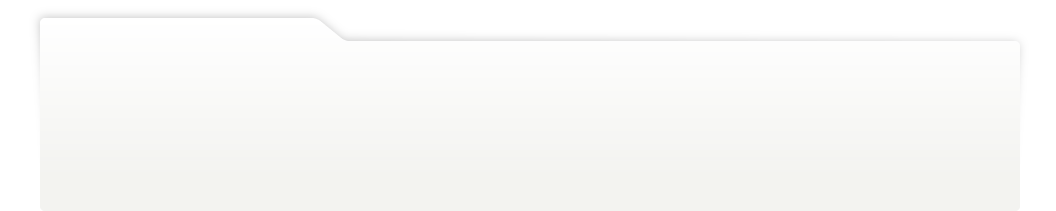
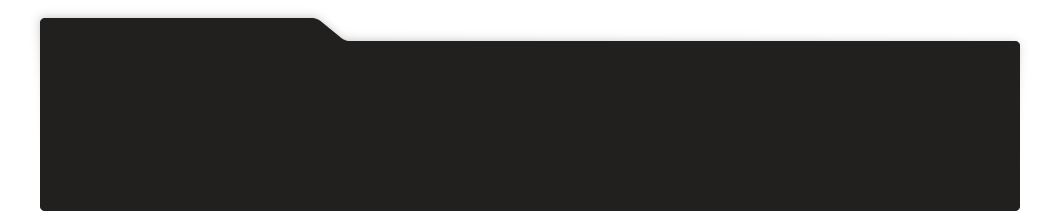
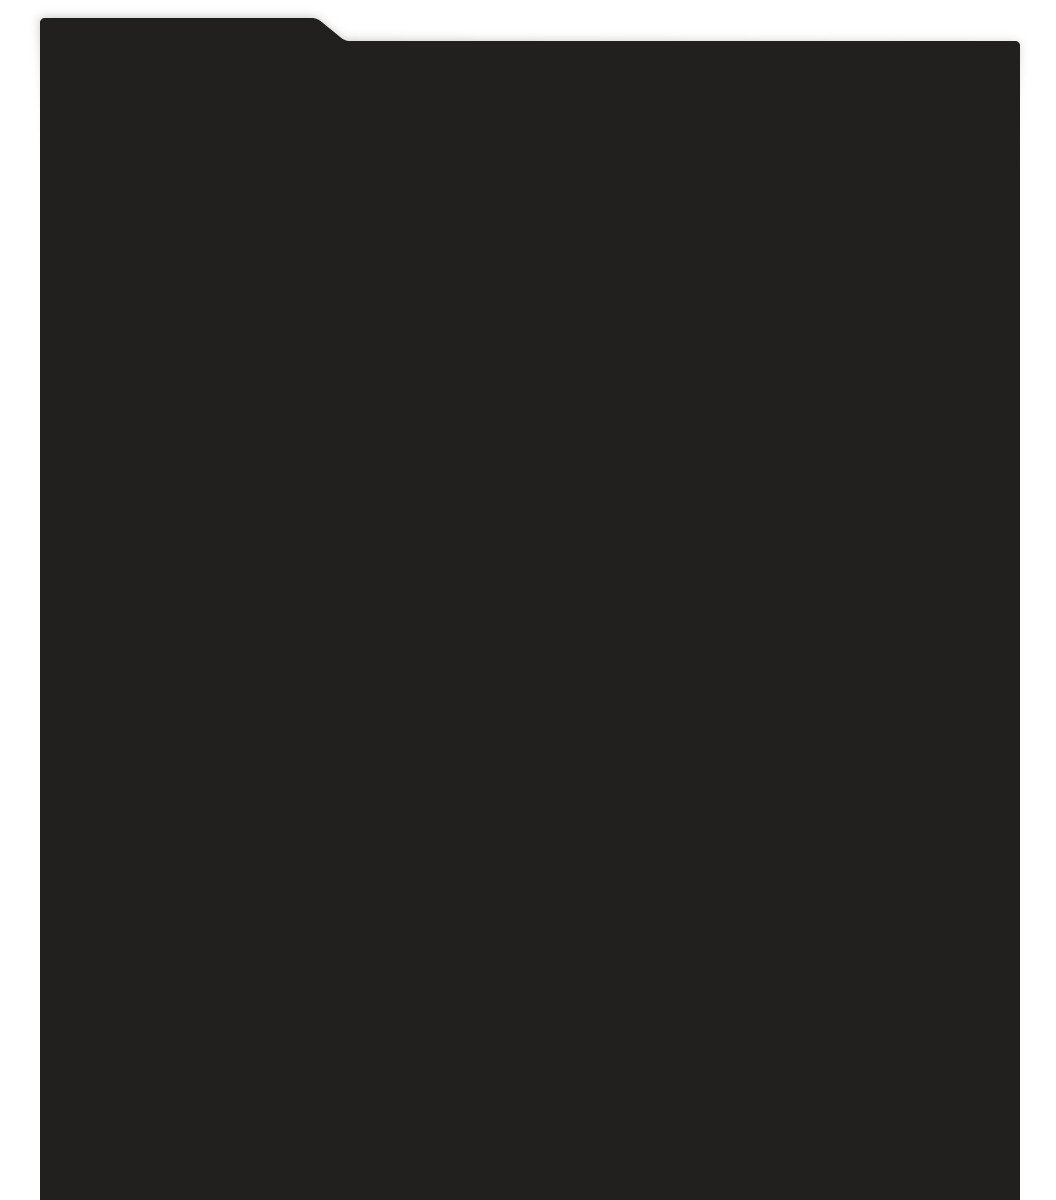
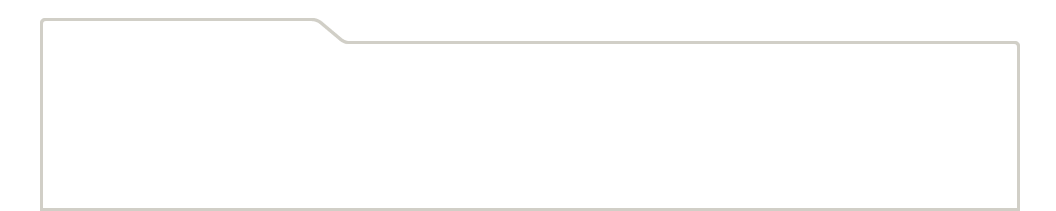
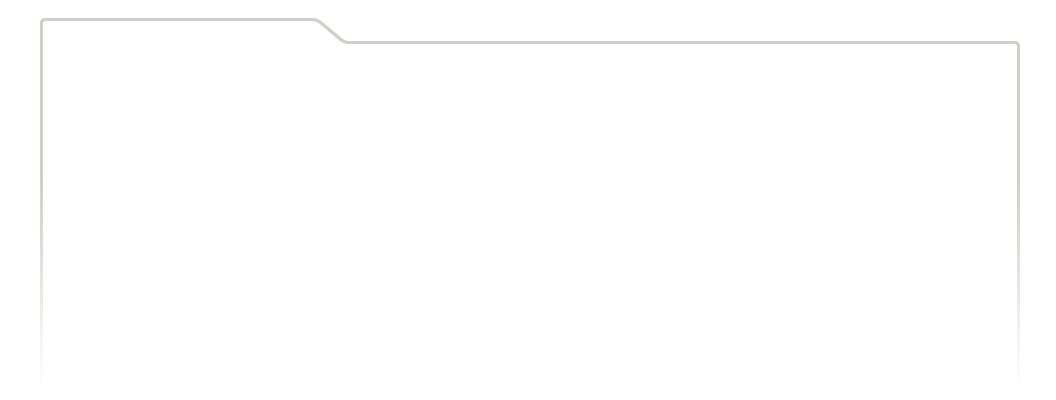
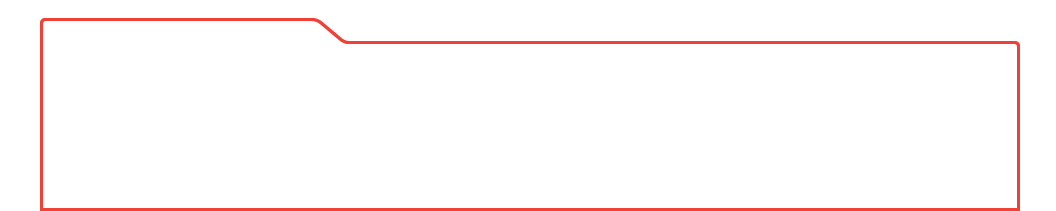
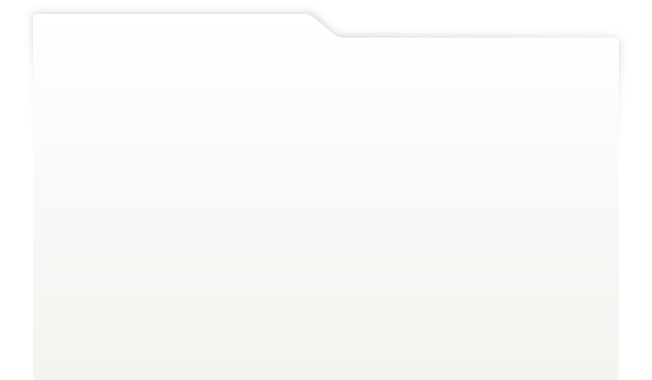
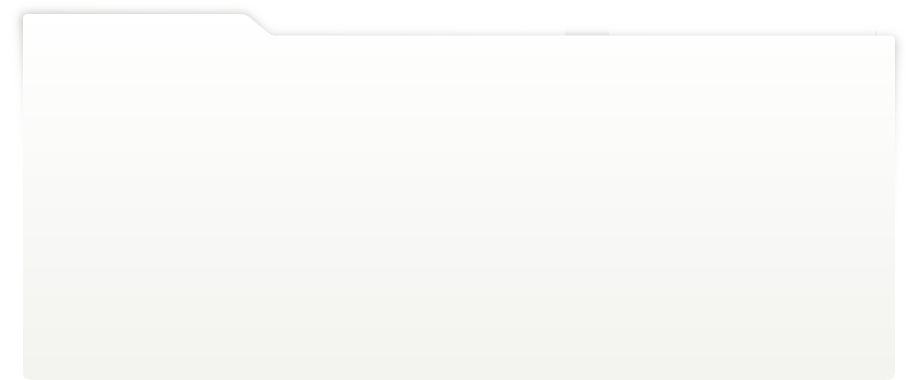
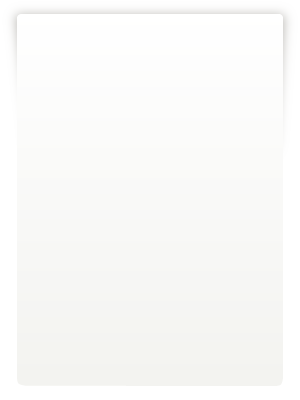
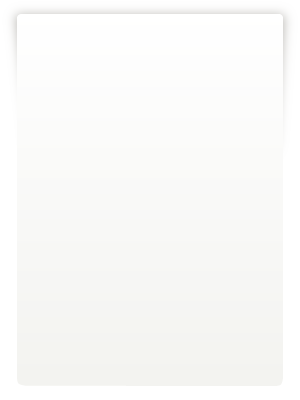
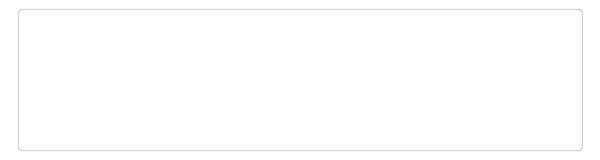
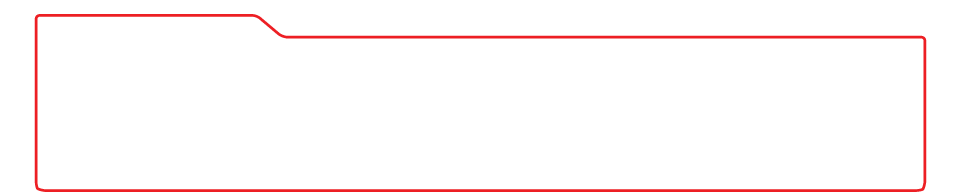
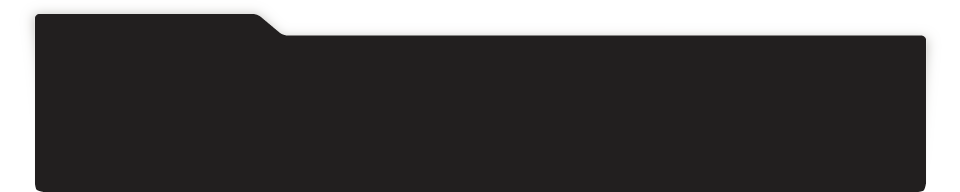
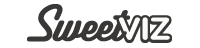
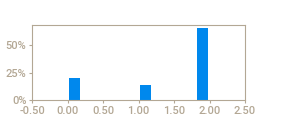
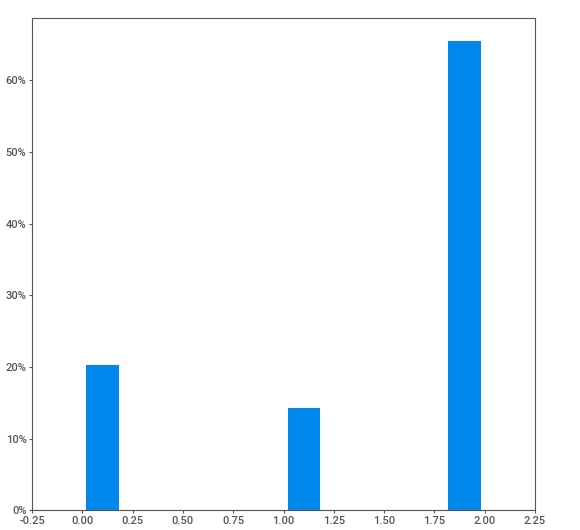
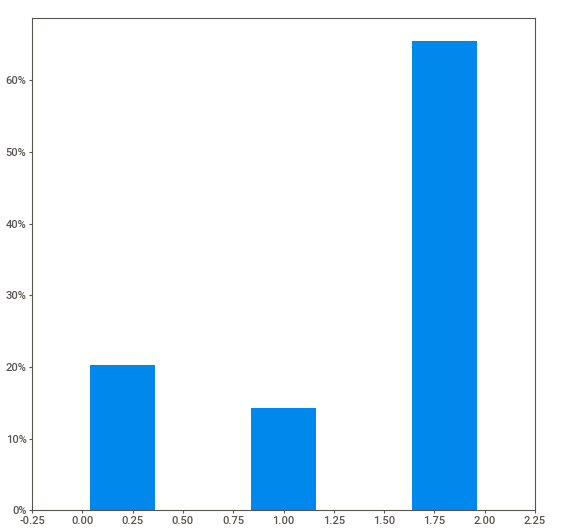
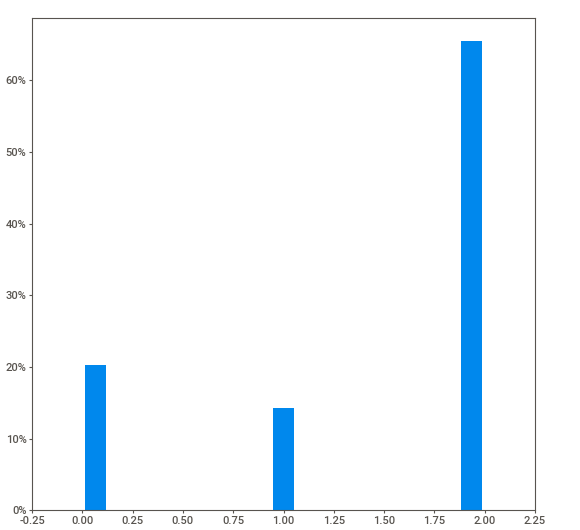
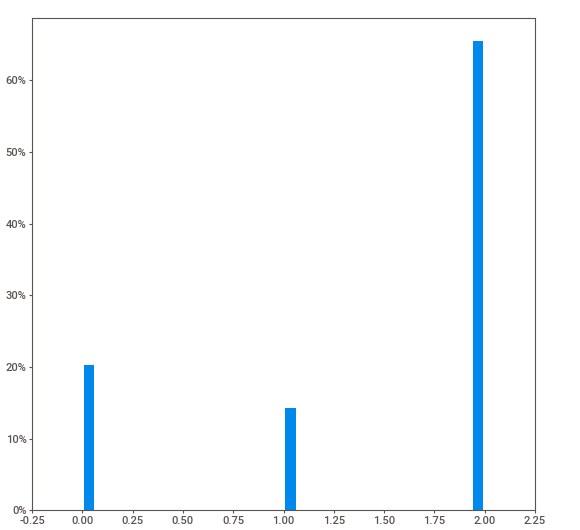
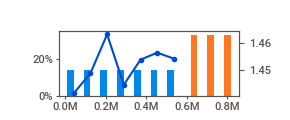
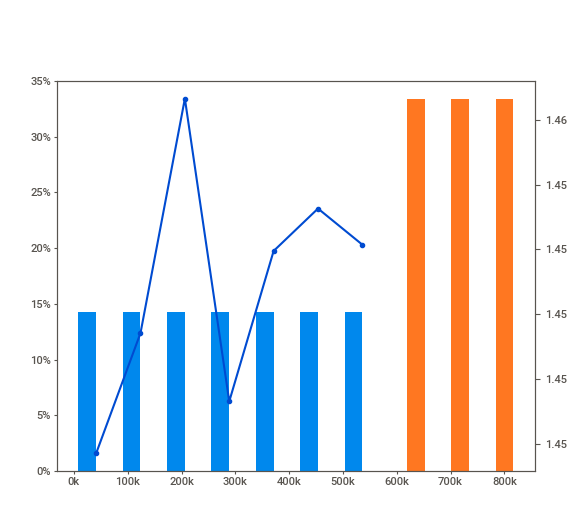
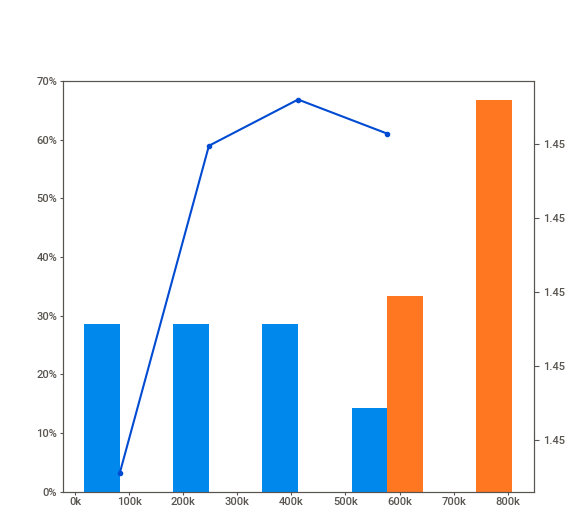
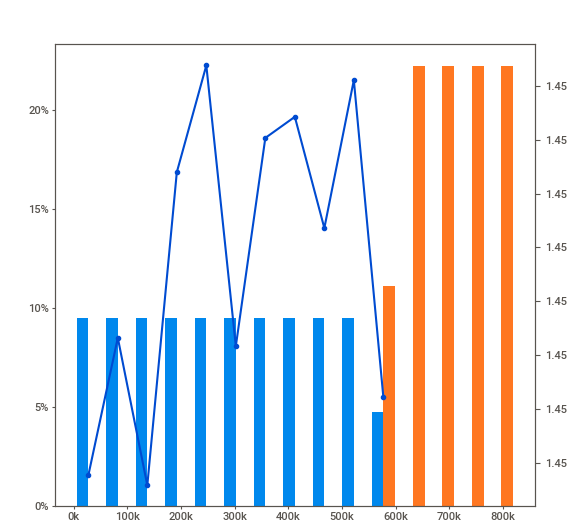
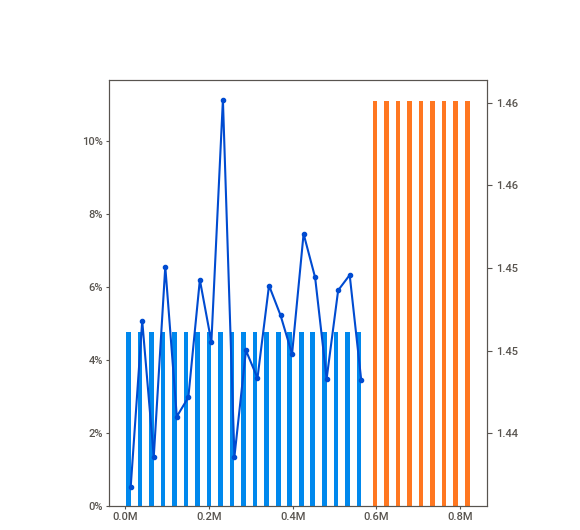
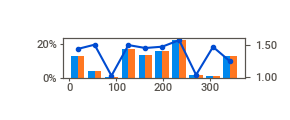
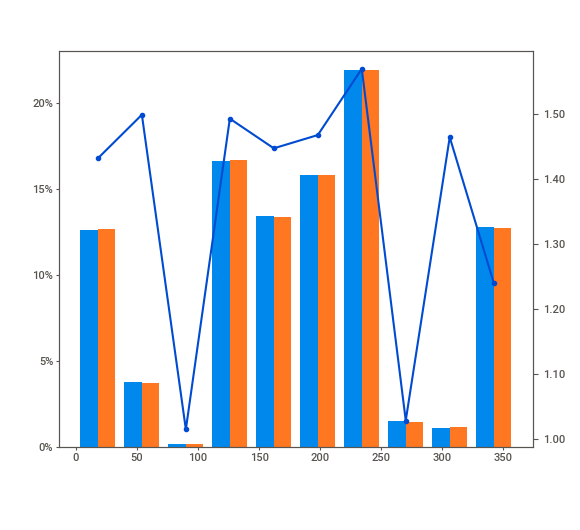
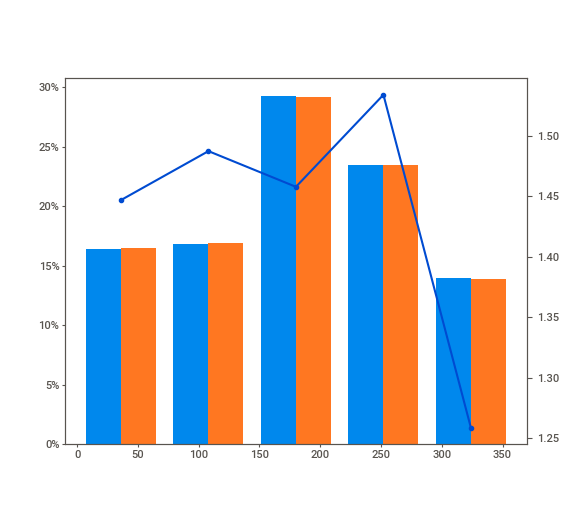
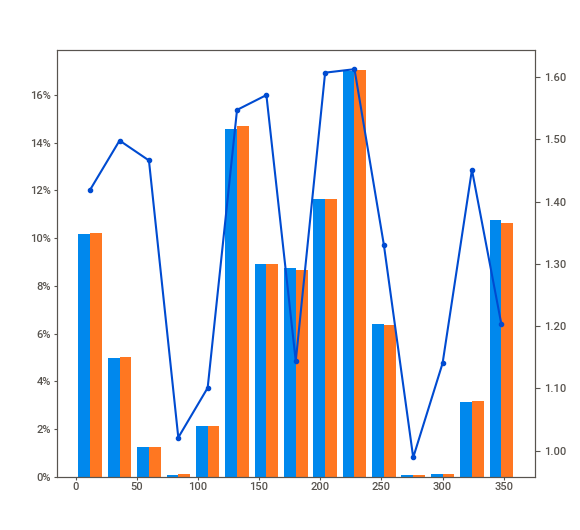
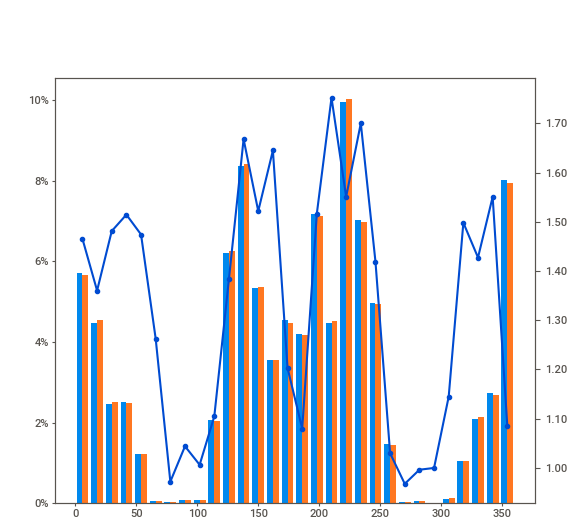
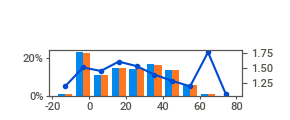
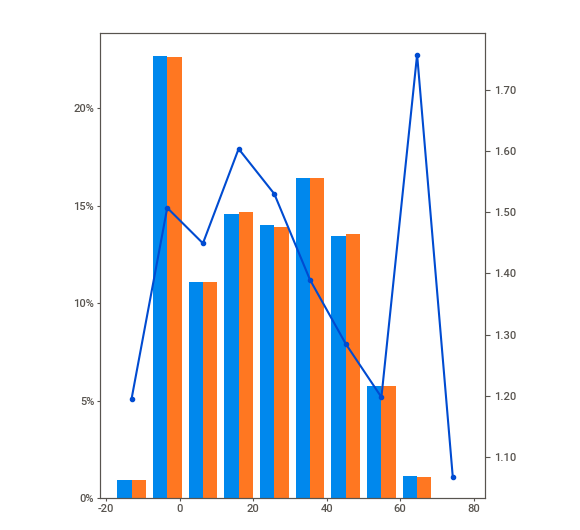
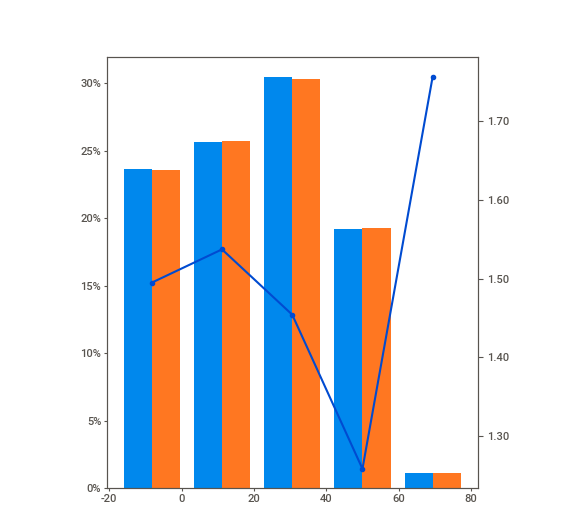
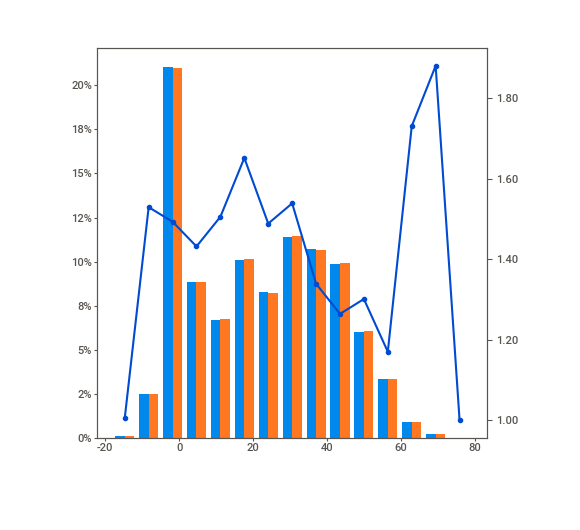
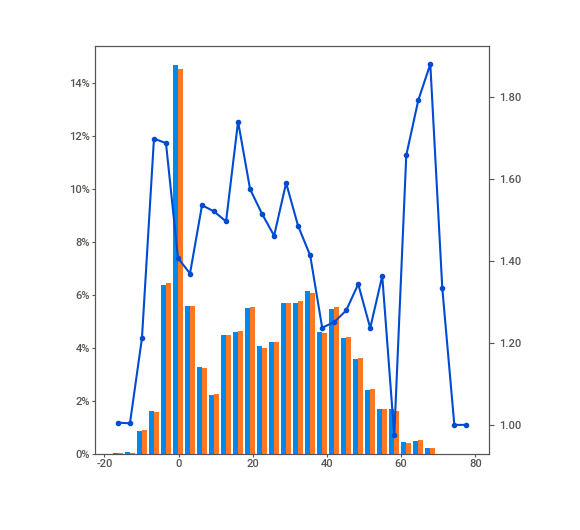
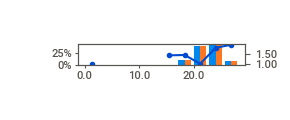
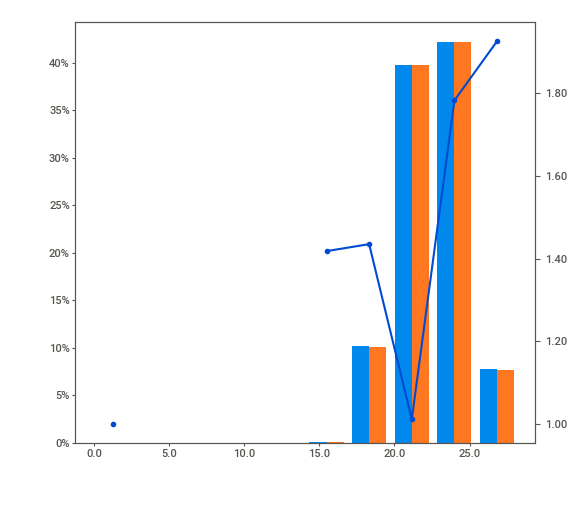
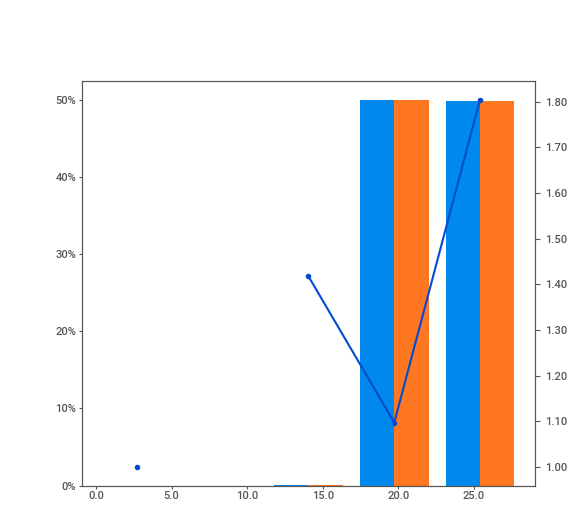
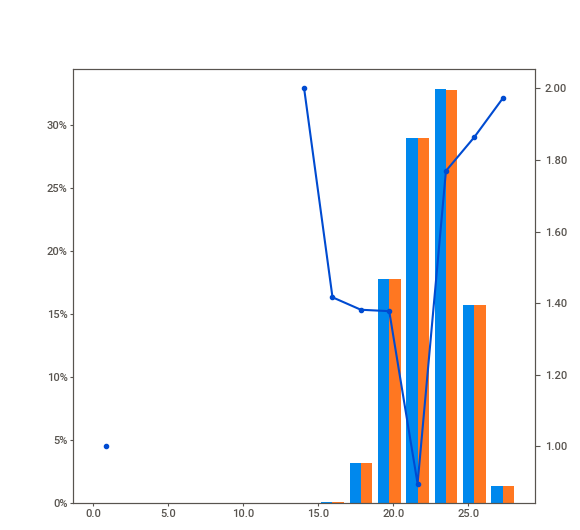
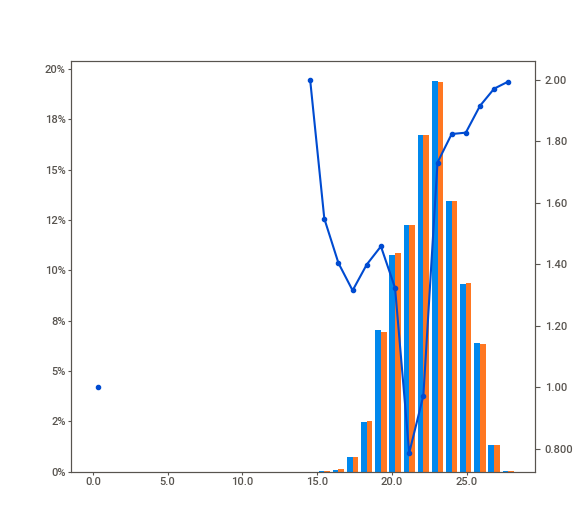
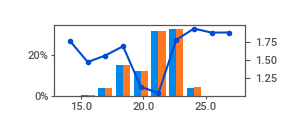
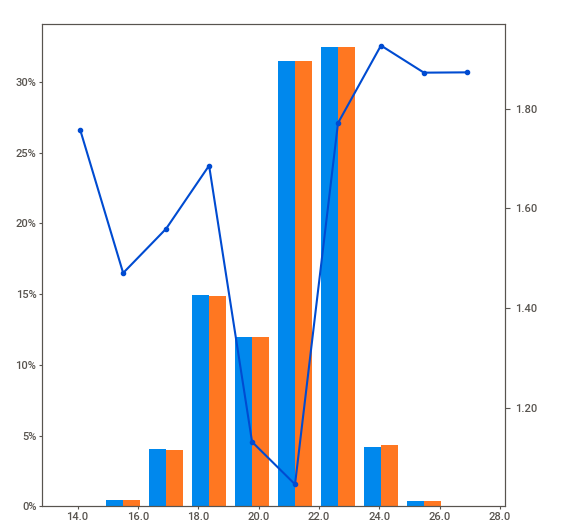
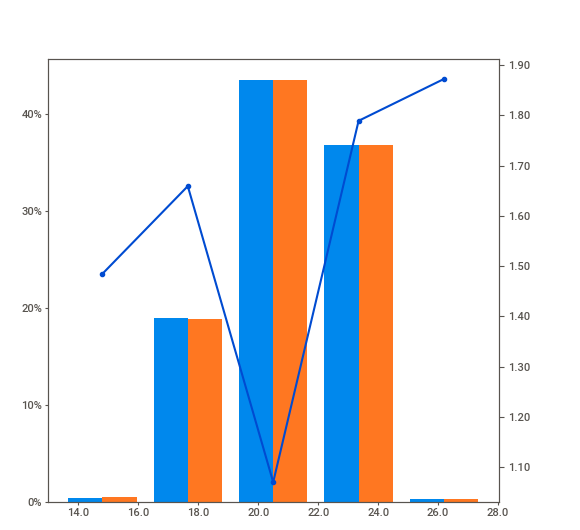
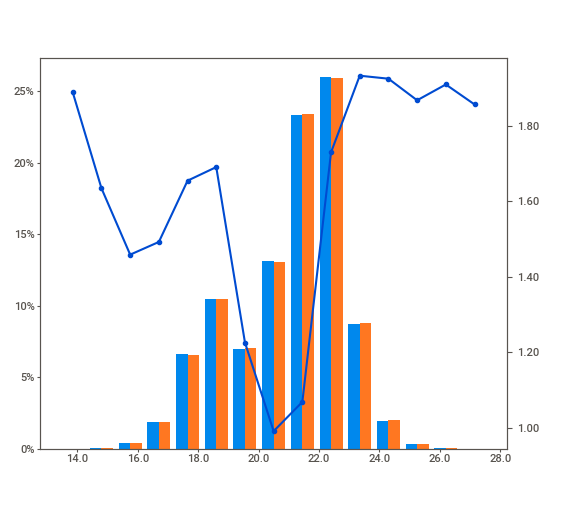
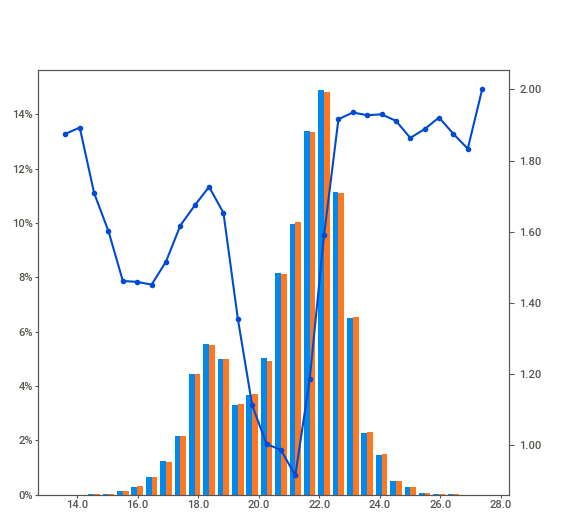
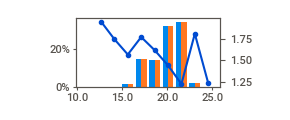
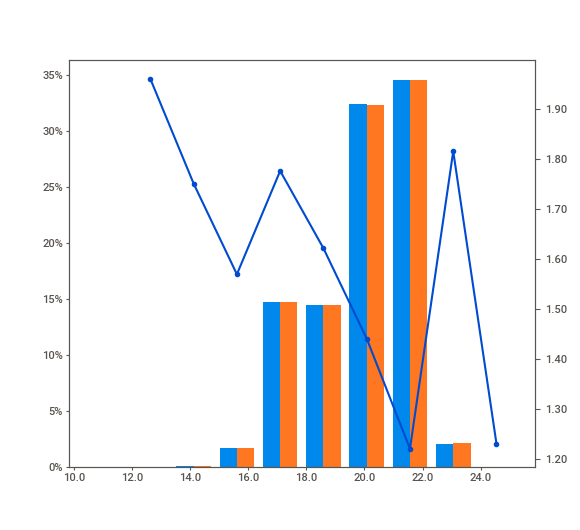
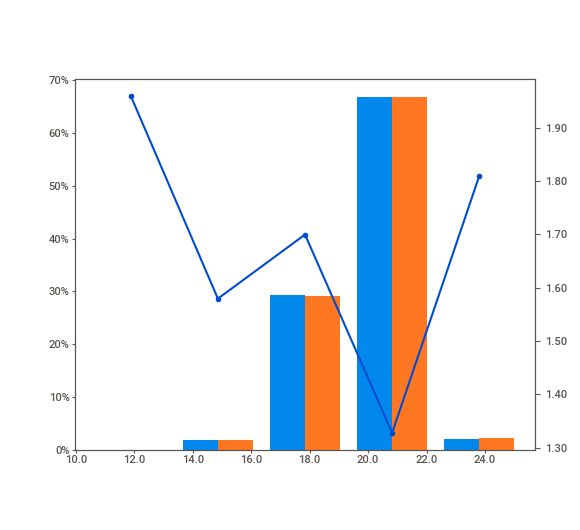
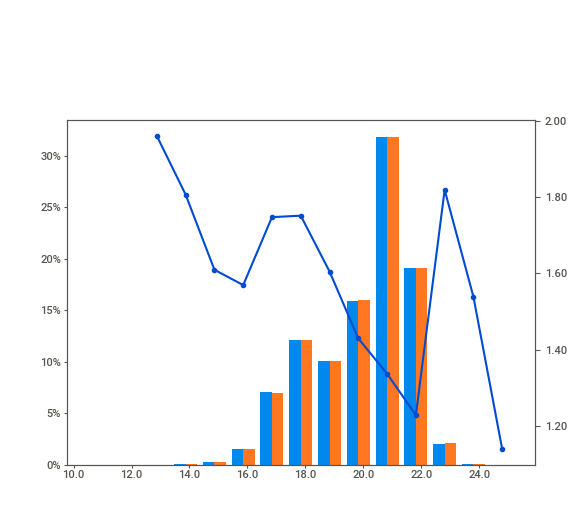
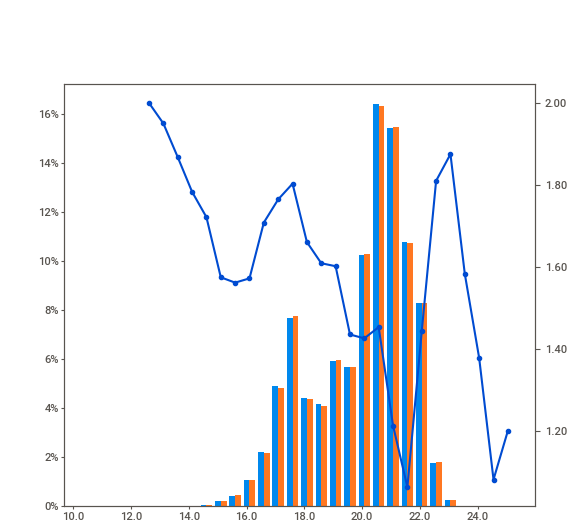
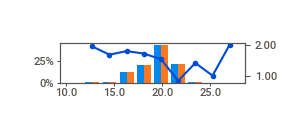
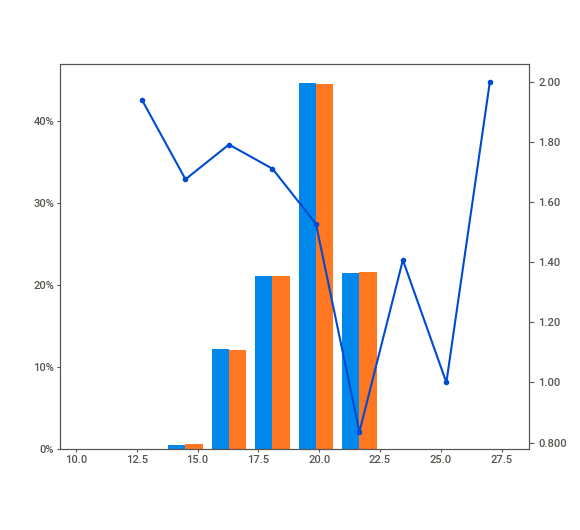
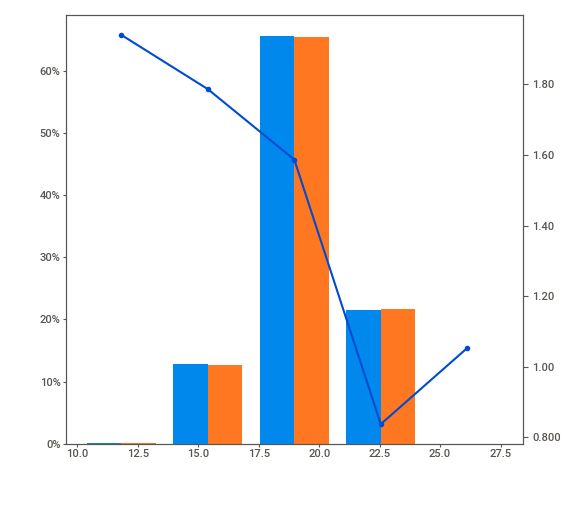
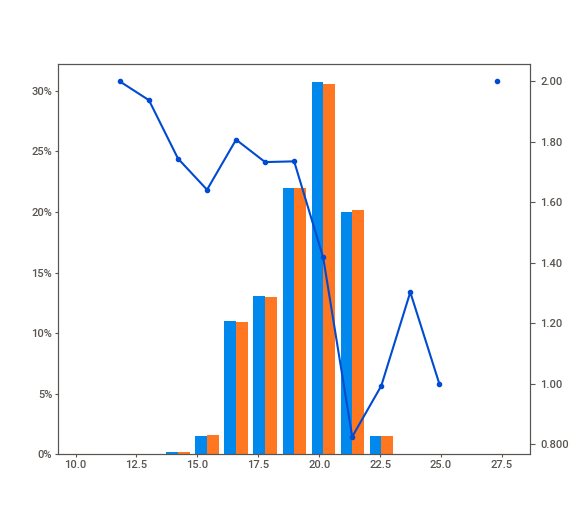
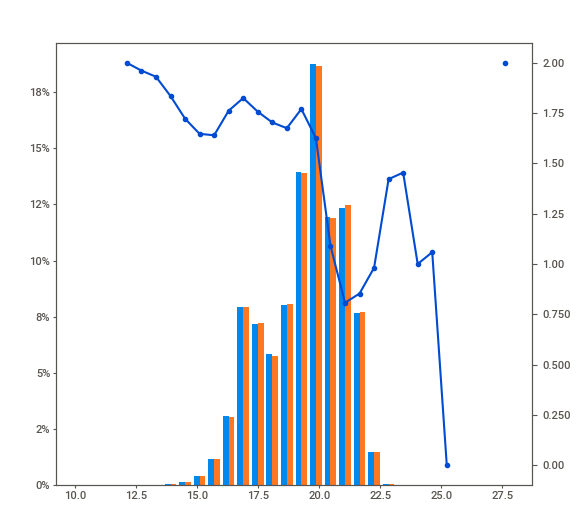
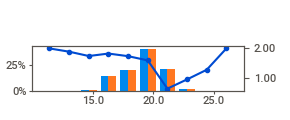
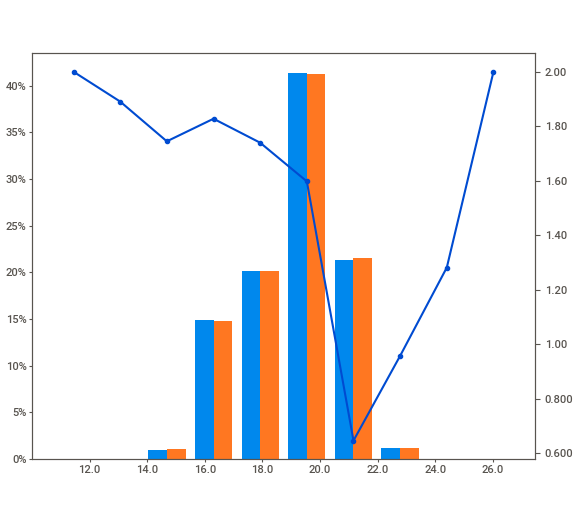
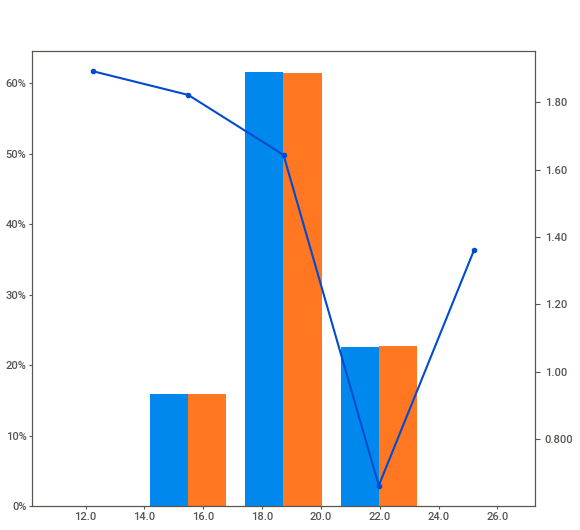
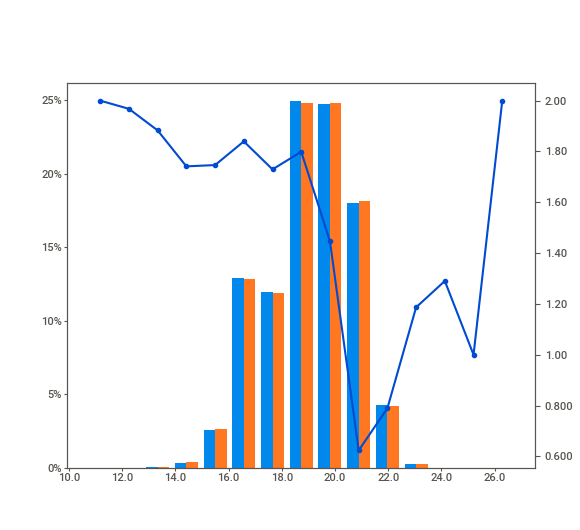
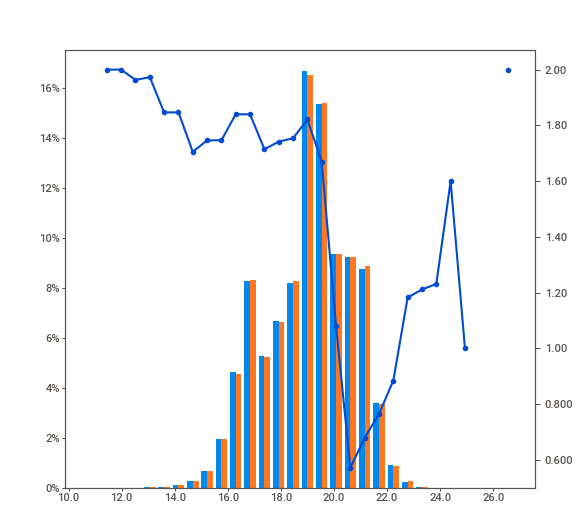
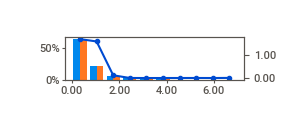
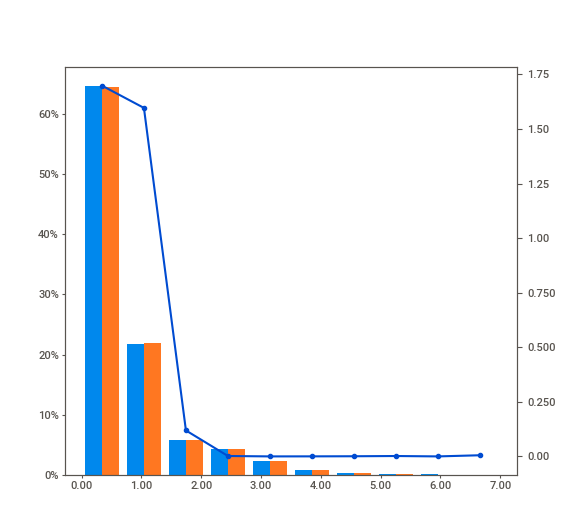
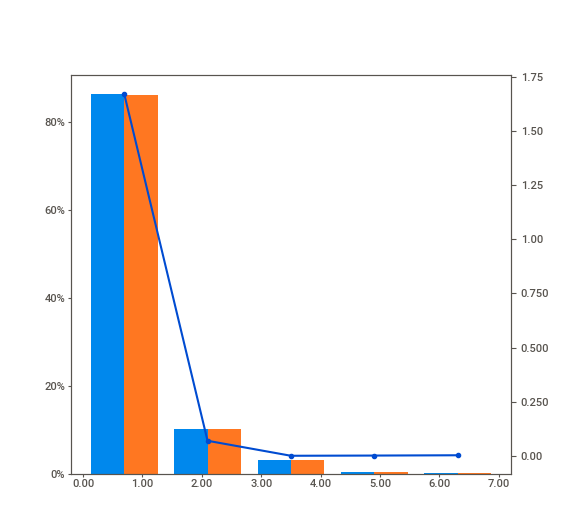
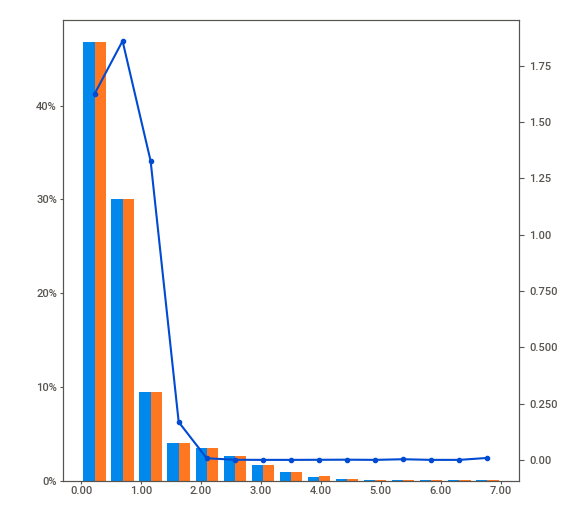
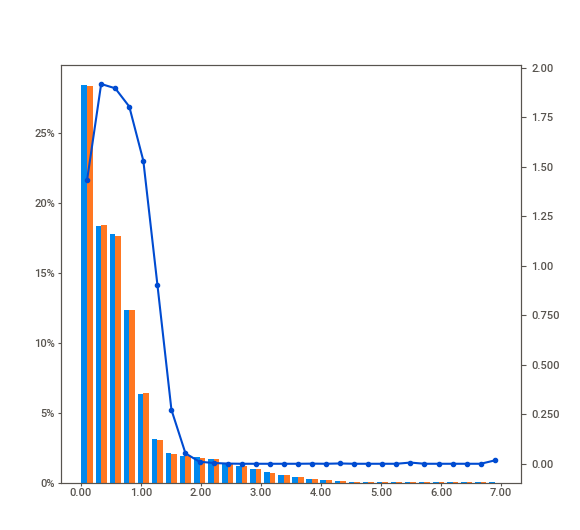
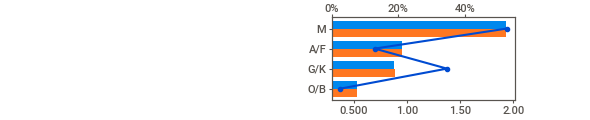
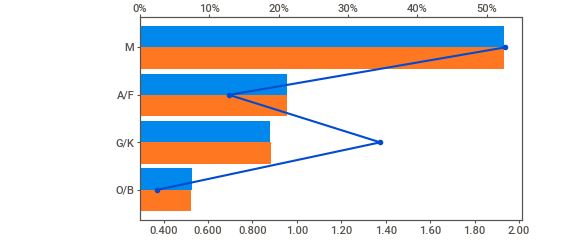
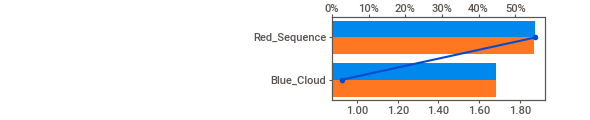
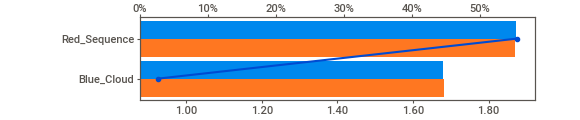
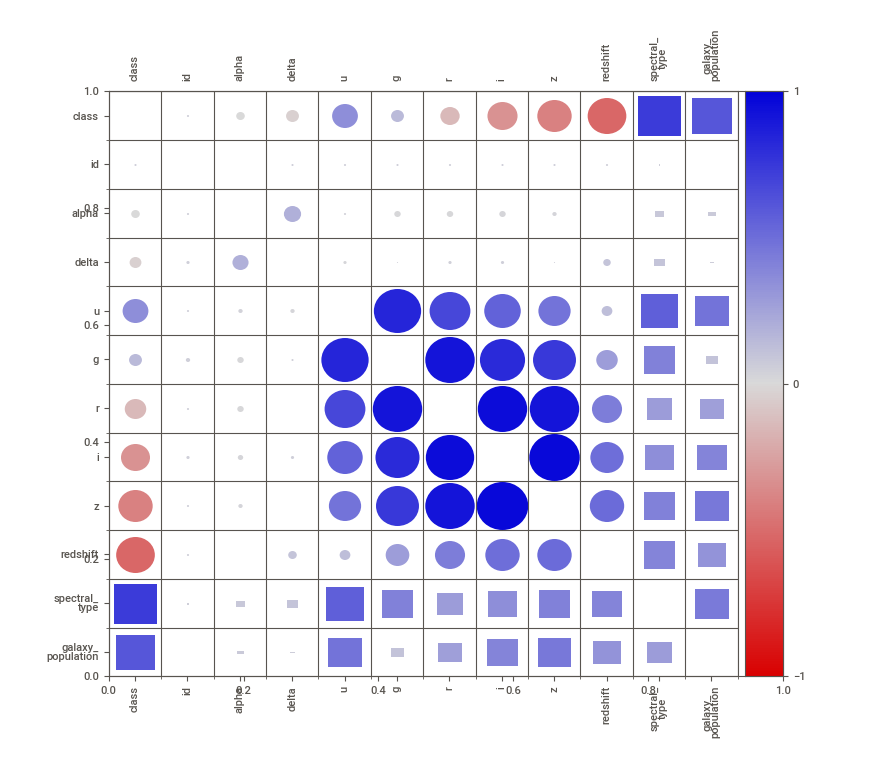
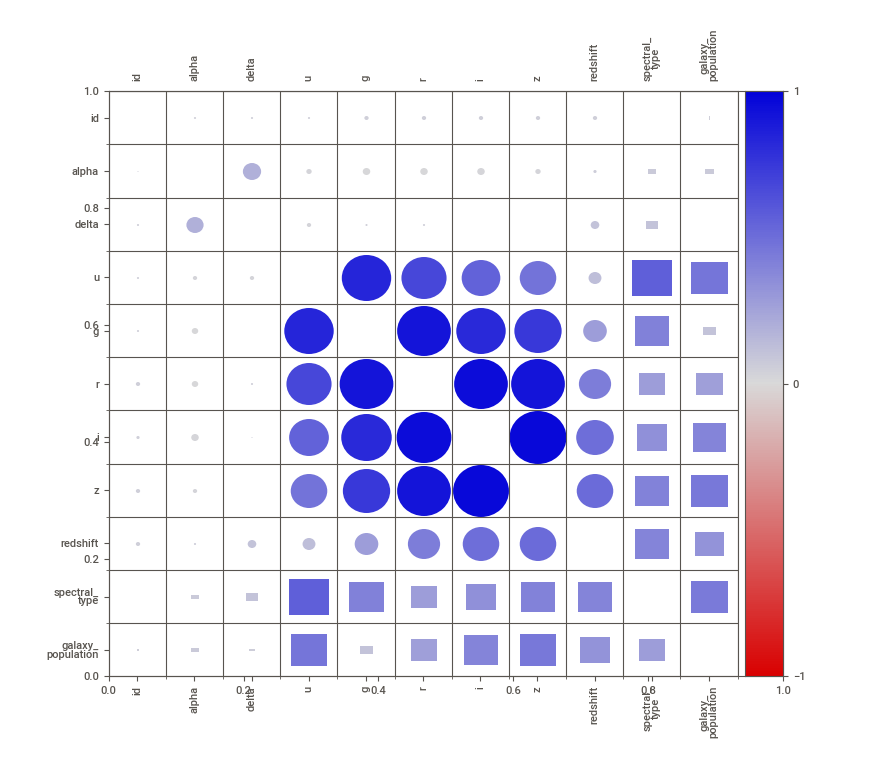

In [7]:
# Sweetviz can't handle categorical, so map the target to numeric
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}

training_df_sv = training_df.copy()
training_df_sv[TARGET] = training_df_sv[TARGET].map(target_mapping).astype(np.int8)

# Tell sweetviz to treat the (now-integer) target as numerical, not categorical
feat_cfg = sv.FeatureConfig(force_num=[TARGET])

# Compare train vs test
train_test_comparison_report = sv.compare(
    [training_df_sv, "Training Data"],
    [test_df, "Test Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)
train_test_comparison_report.show_notebook(
    w="100%",
    h=700,
    layout='vertical'
)

We also load the original [Stellar Classification Dataset (SDSS17)](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17) to compare its distributions against the competition's synthetic training set. This helps reveal whether the synthetic data faithfully reproduces the source distribution or introduces artifacts that may affect generalization.

                                             |                                                                …


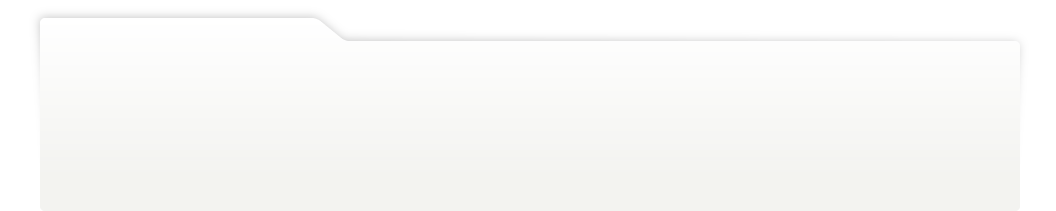
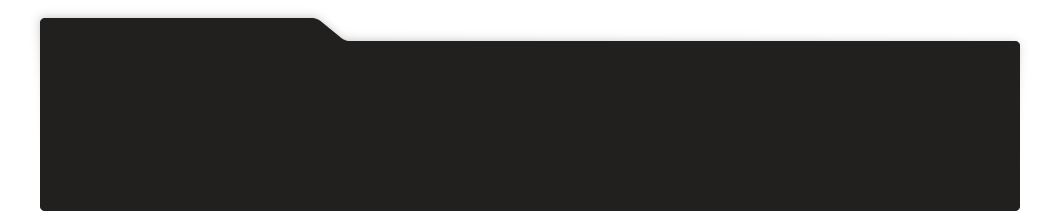
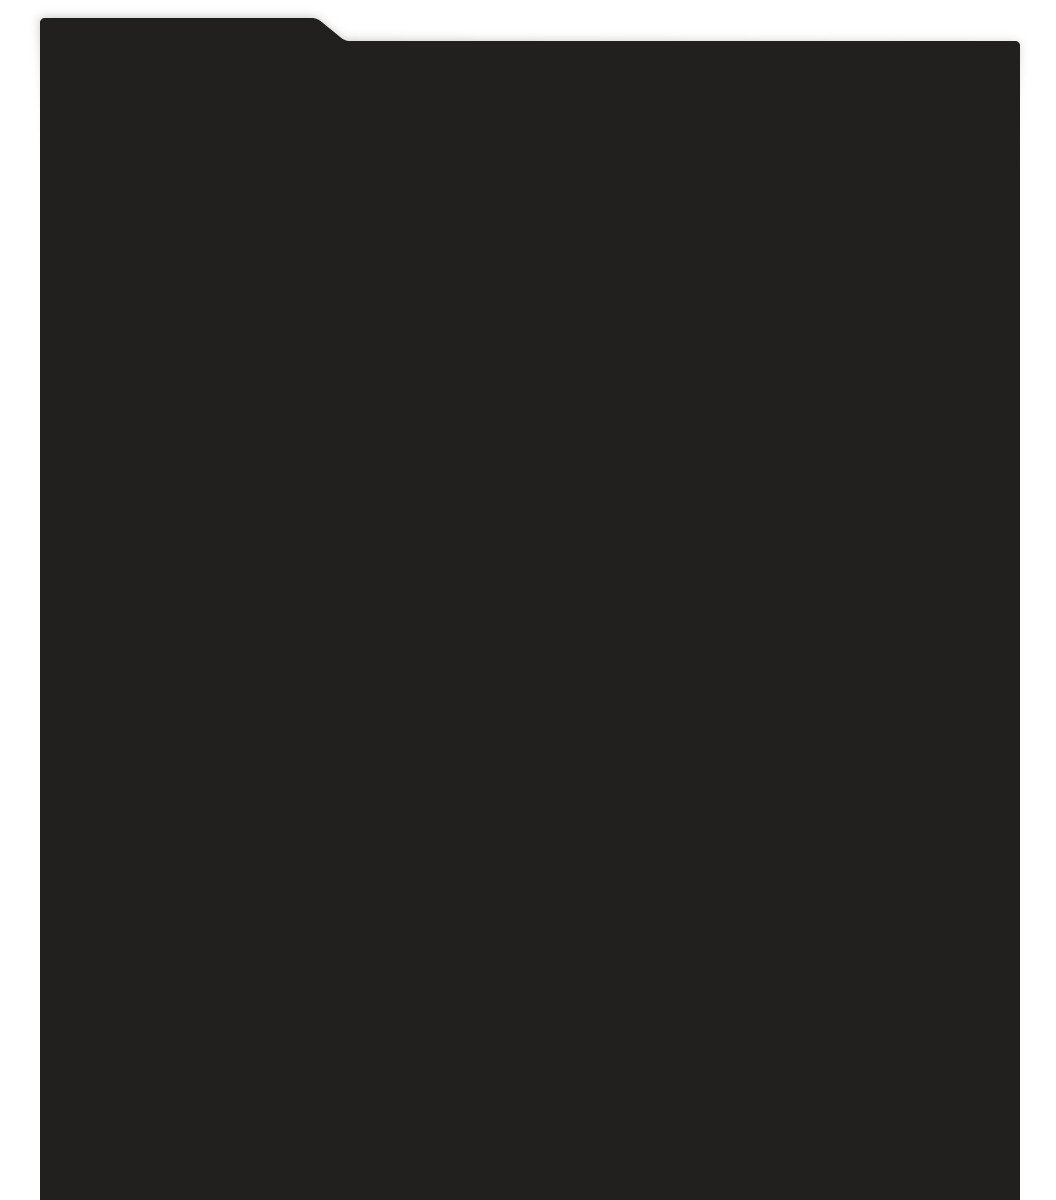
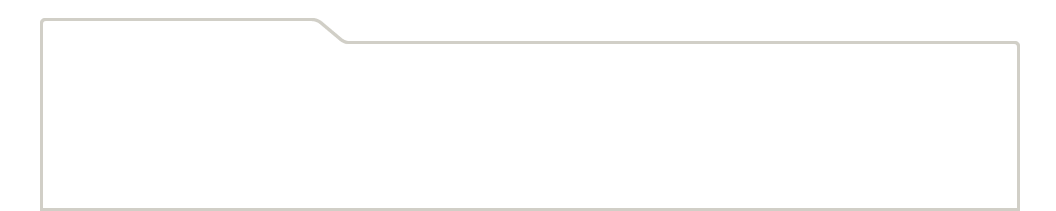
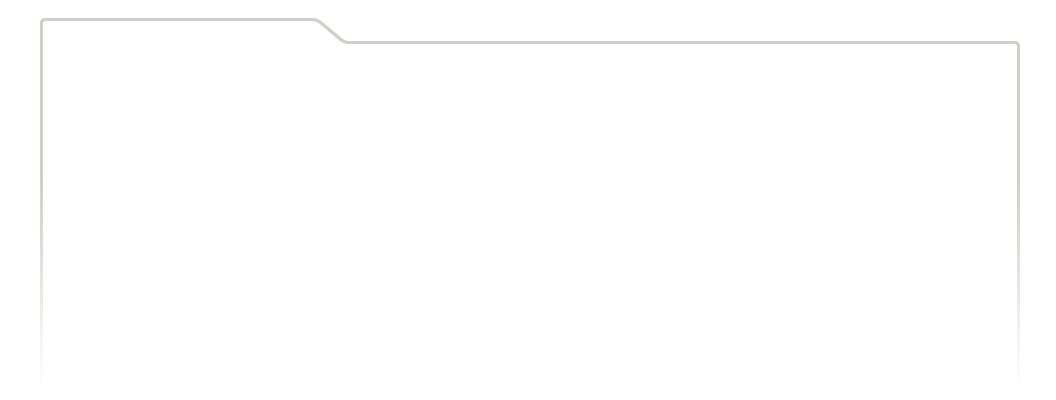
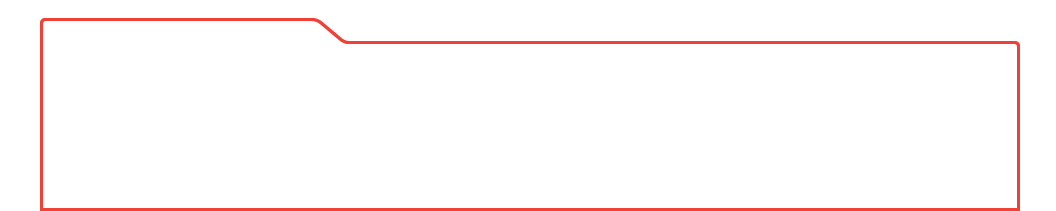
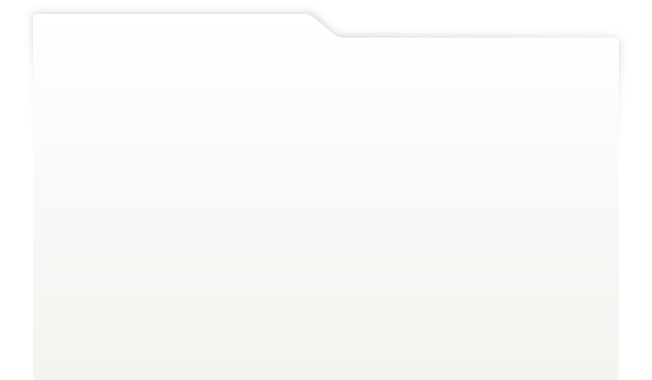
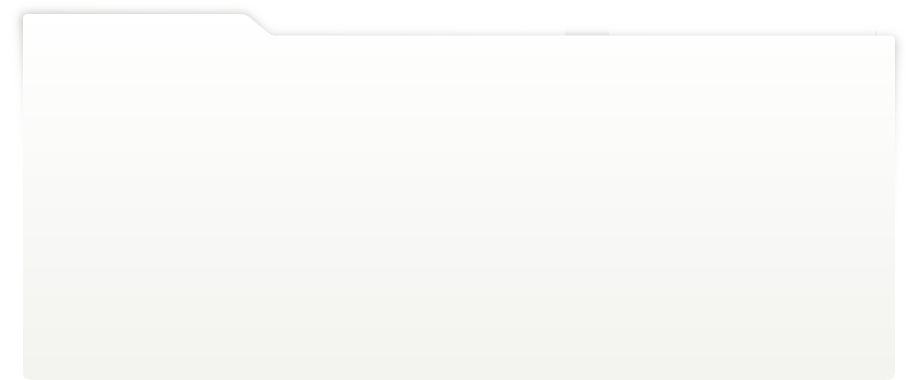
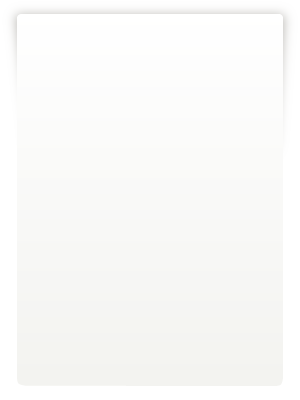
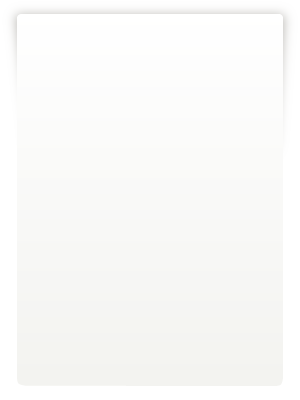
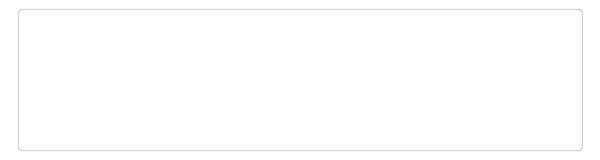
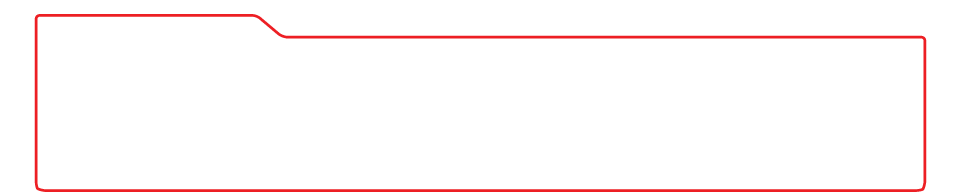
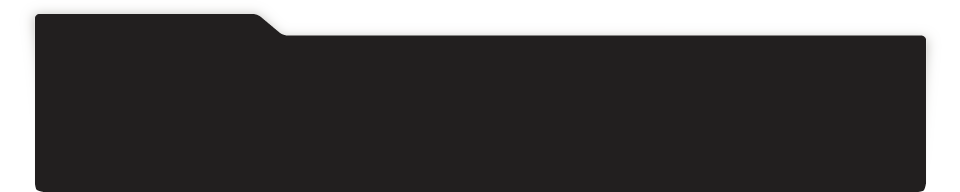
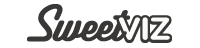
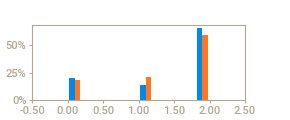
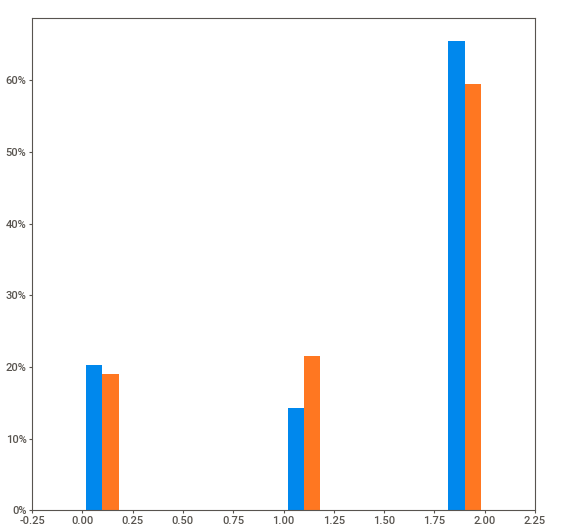
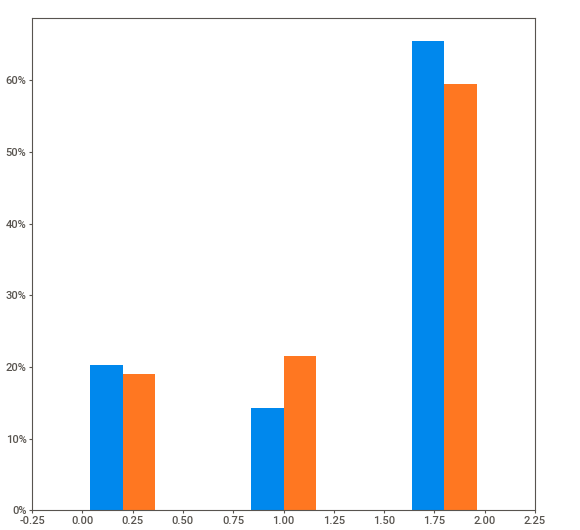
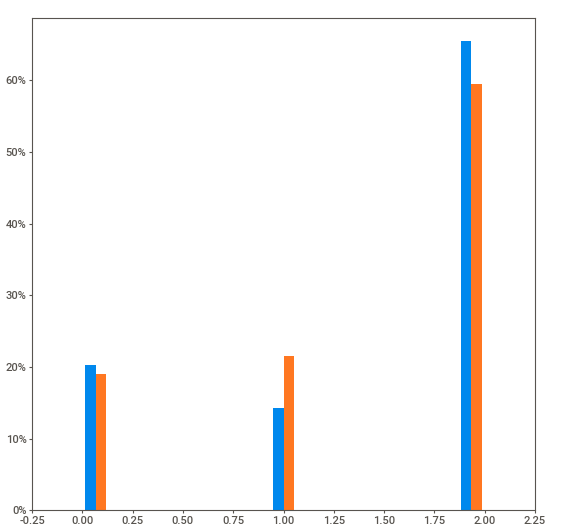
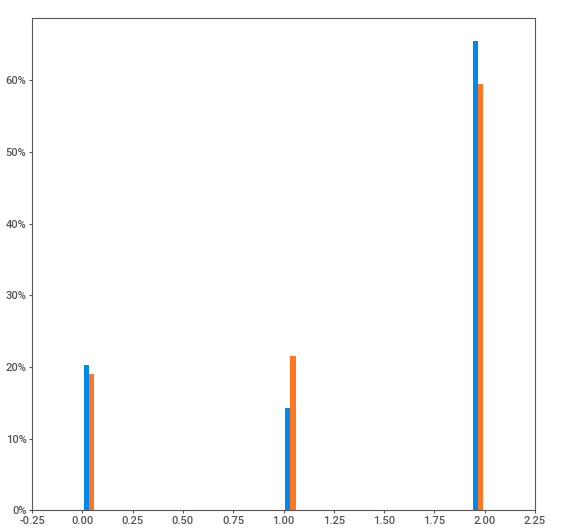
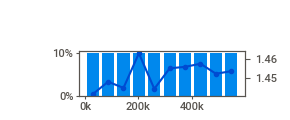
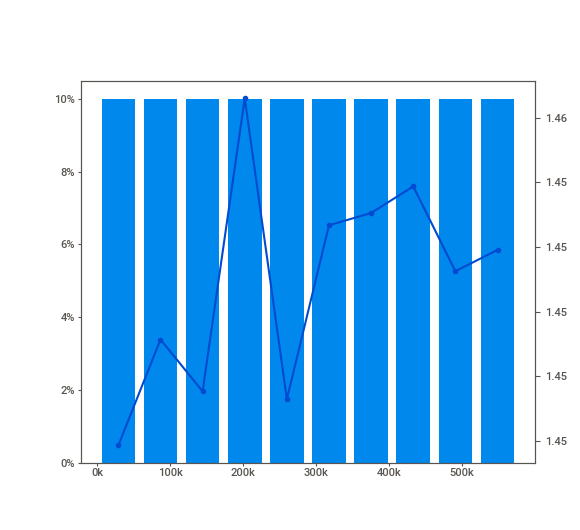
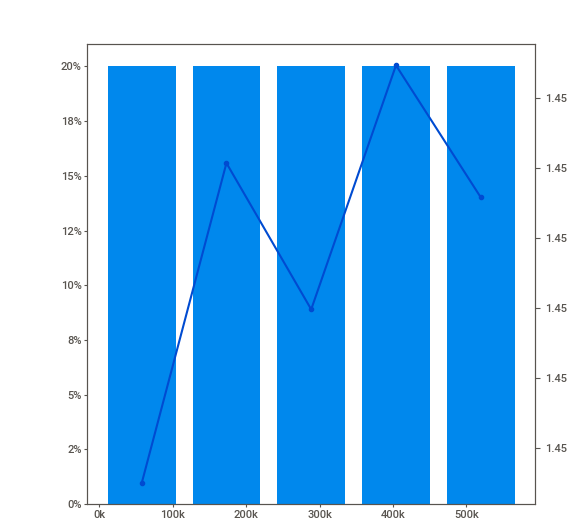
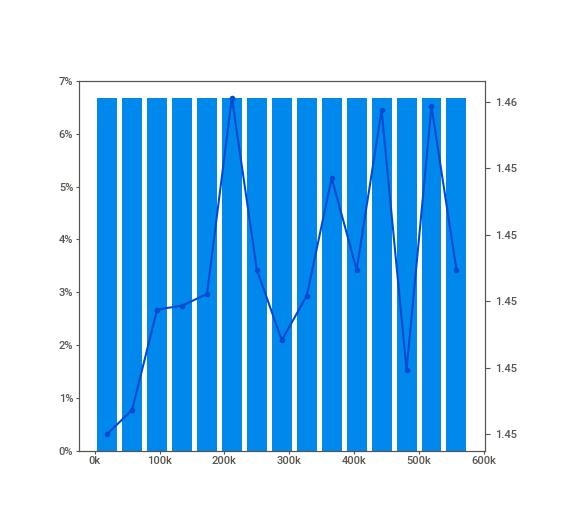
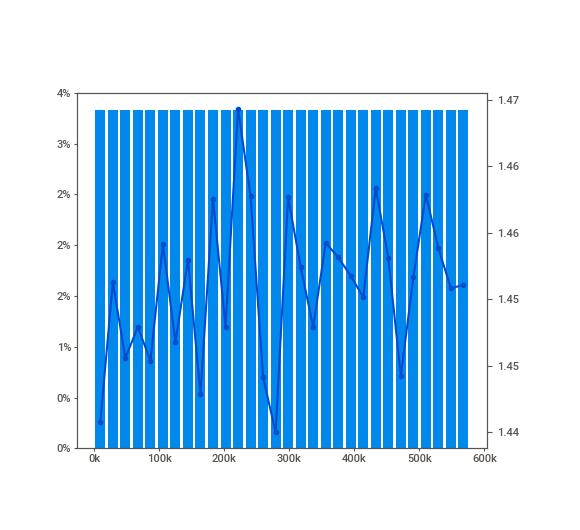
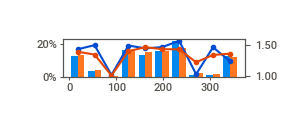
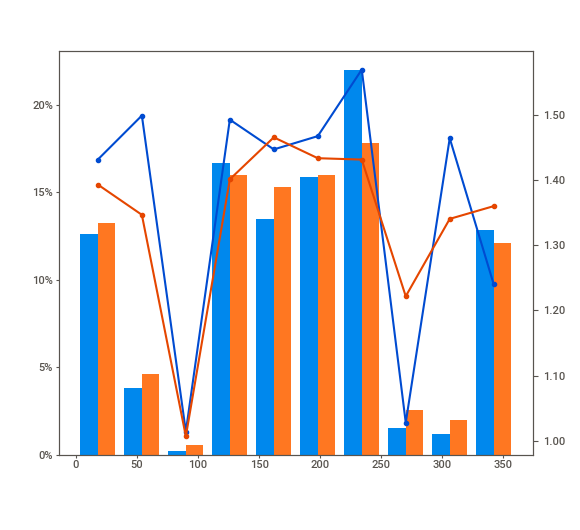
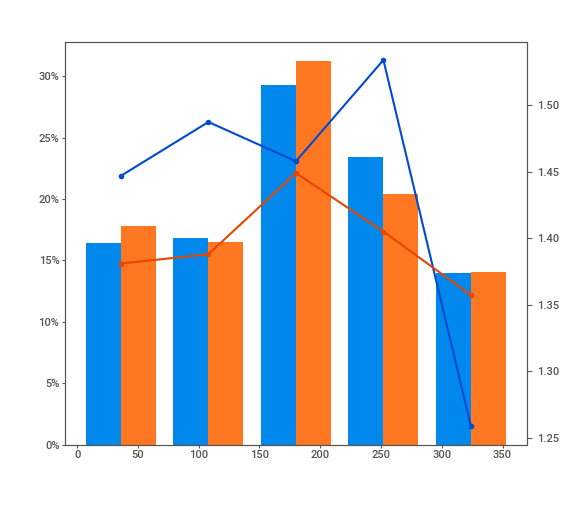
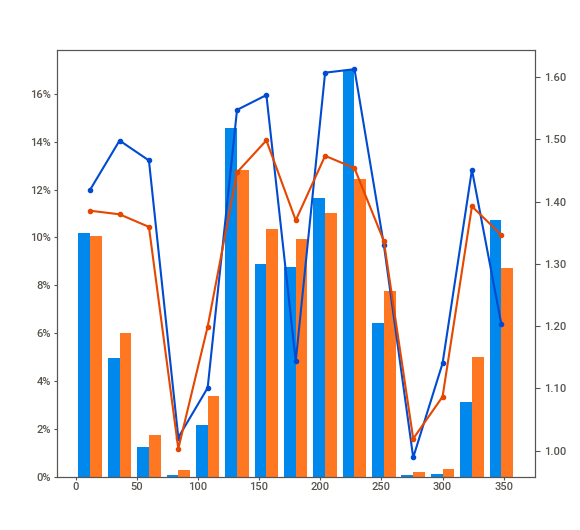
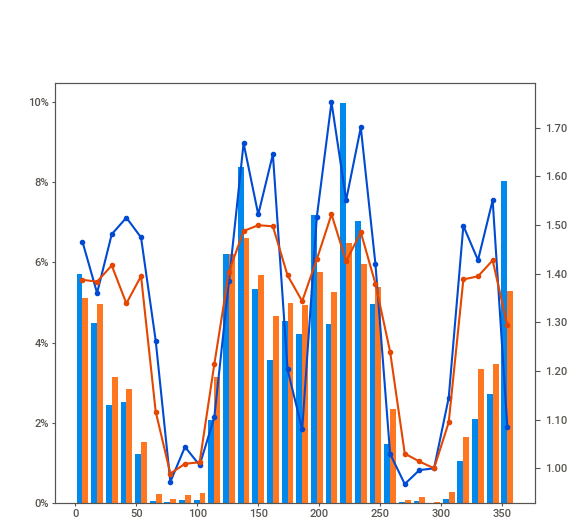
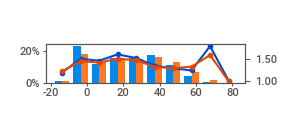
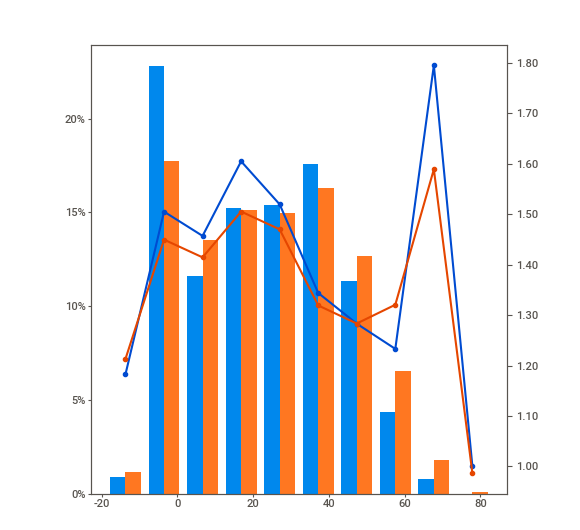
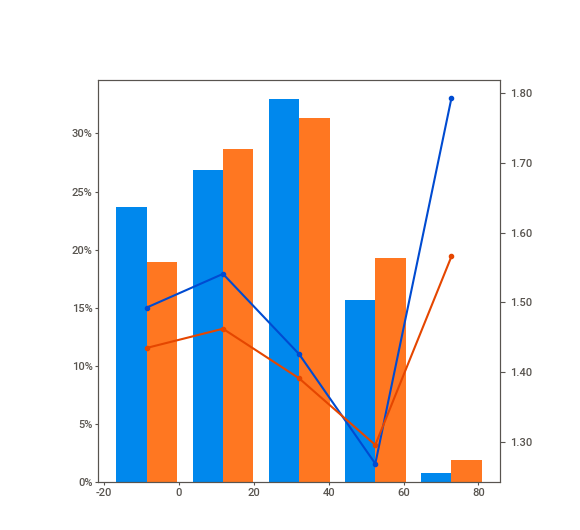
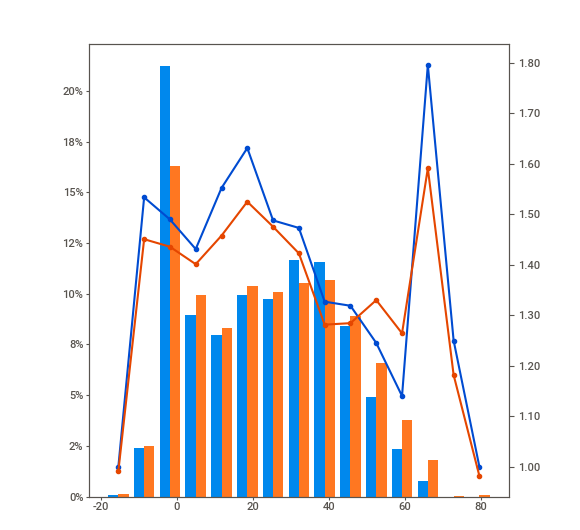
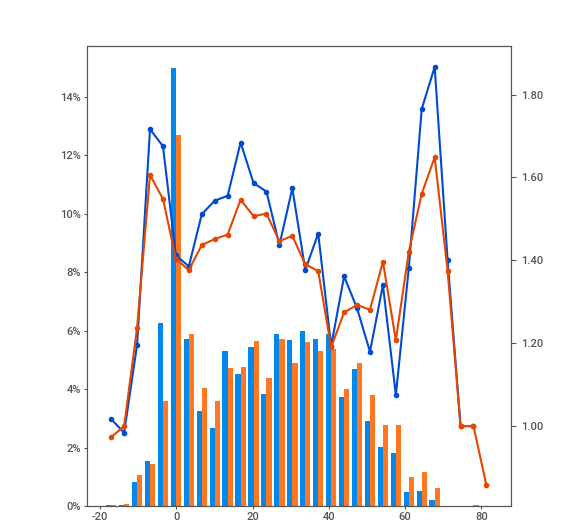
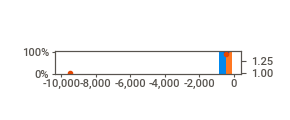
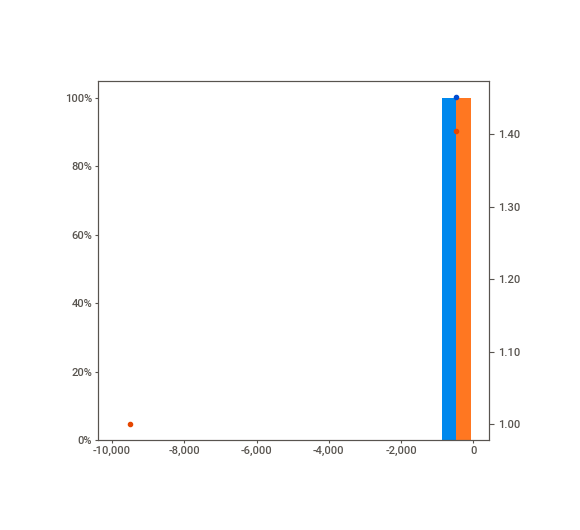
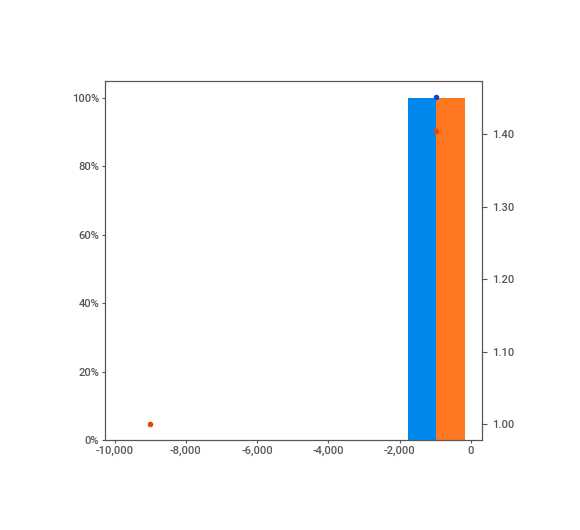
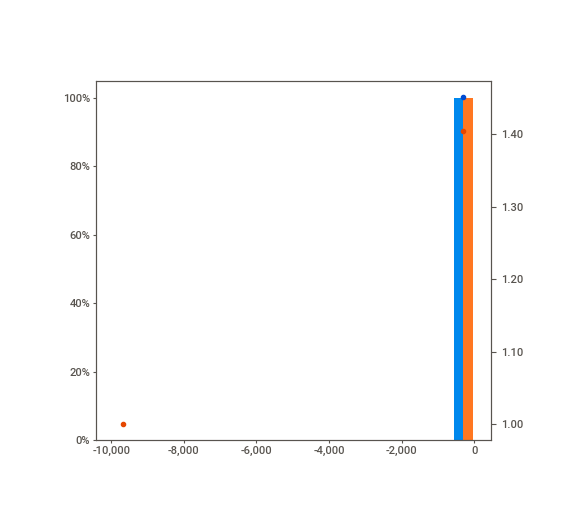
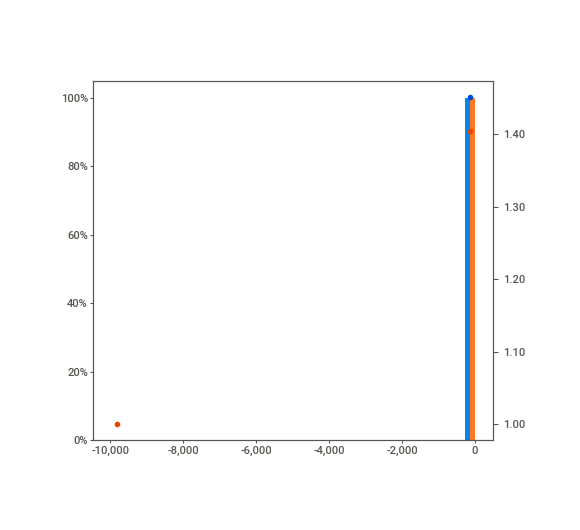
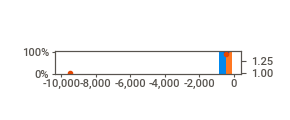
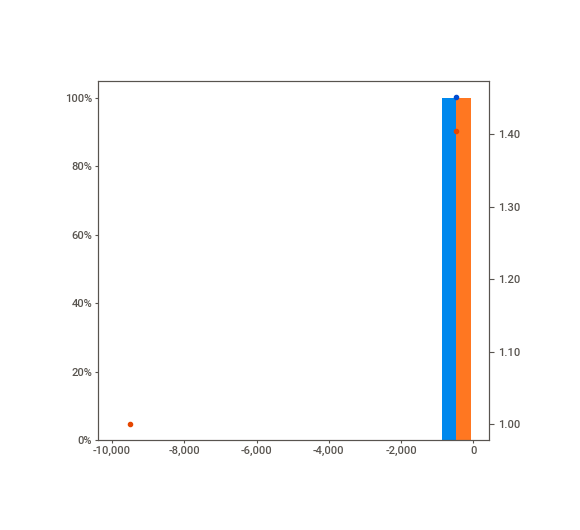
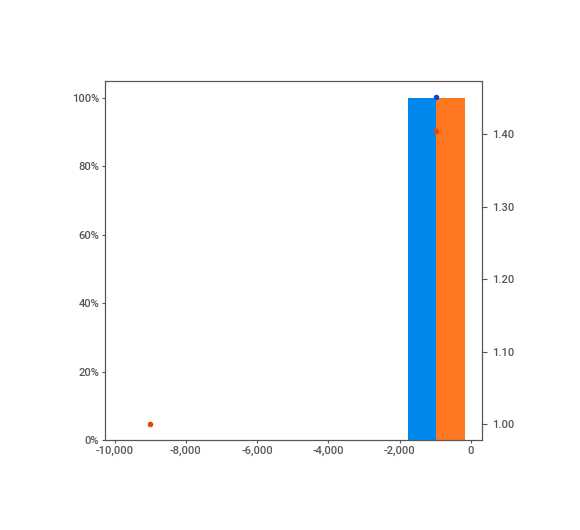
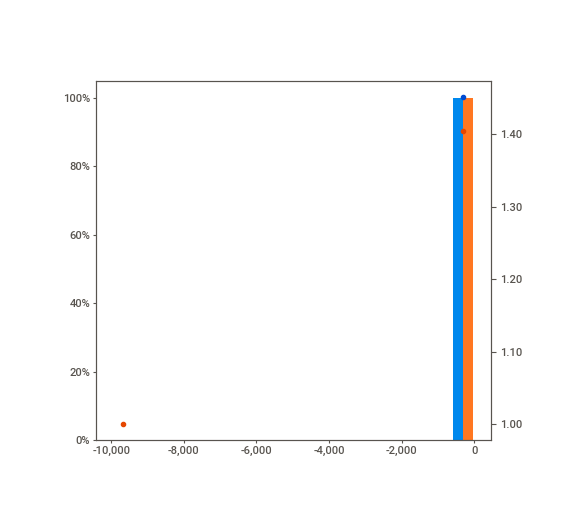
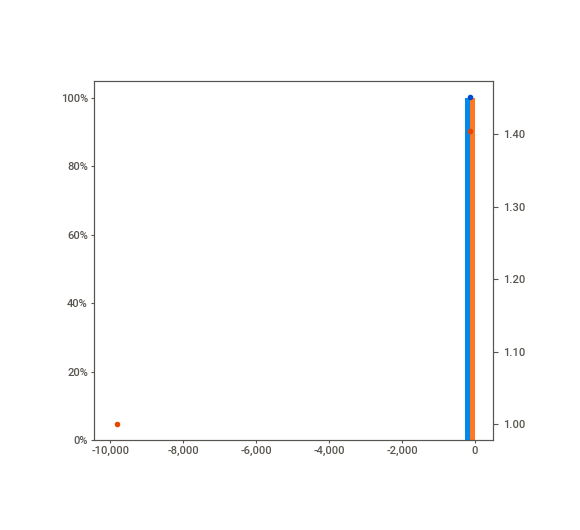
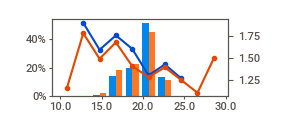
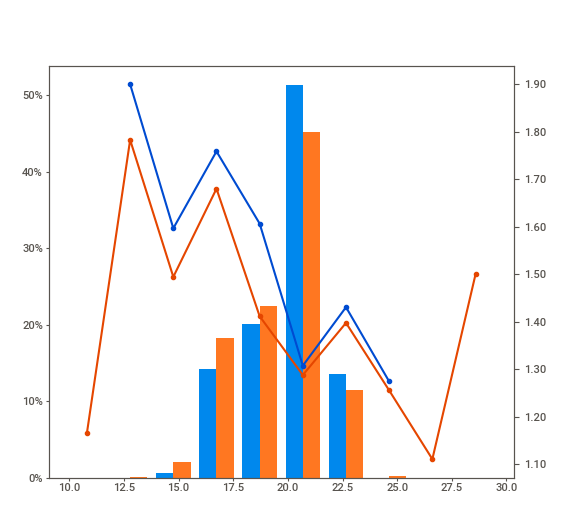
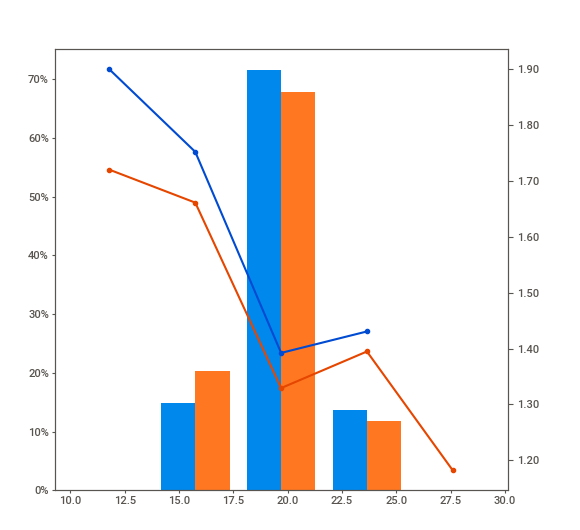
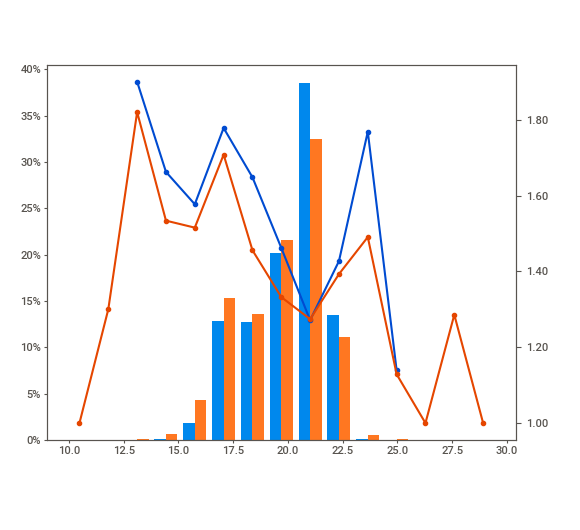
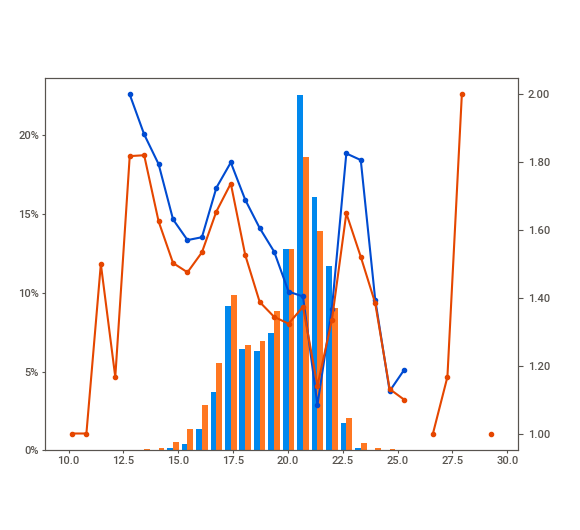
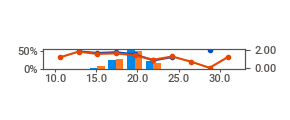
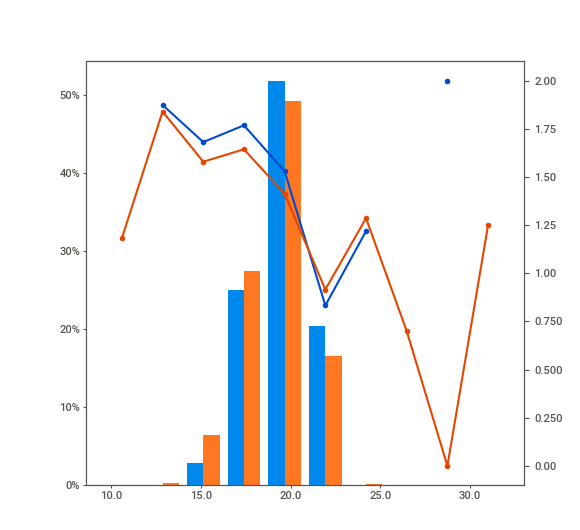
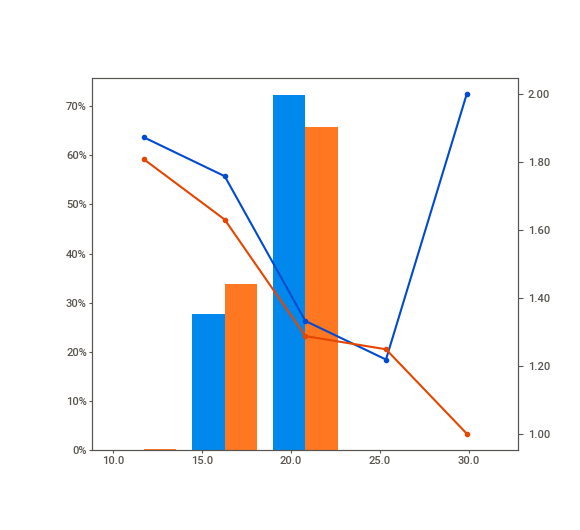
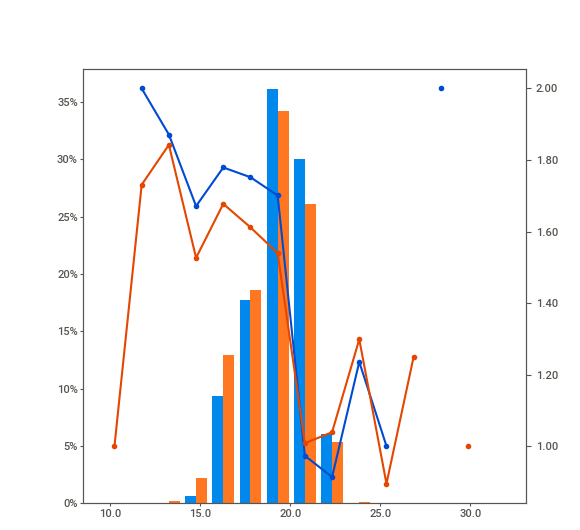
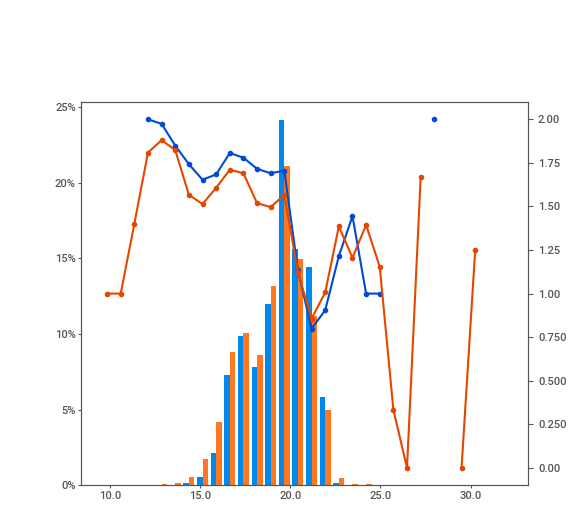
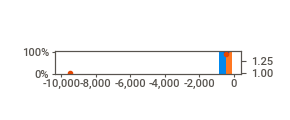
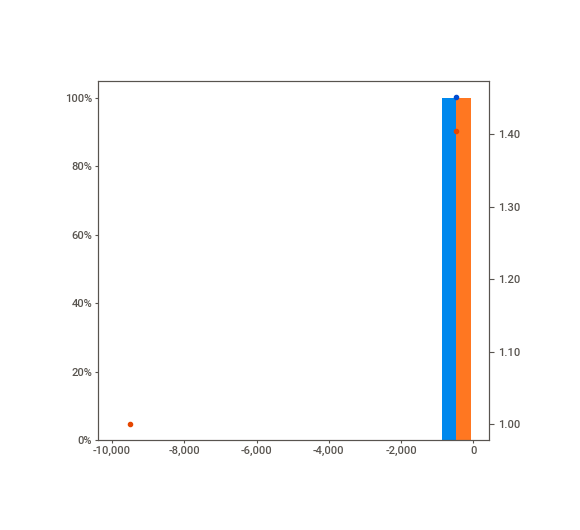
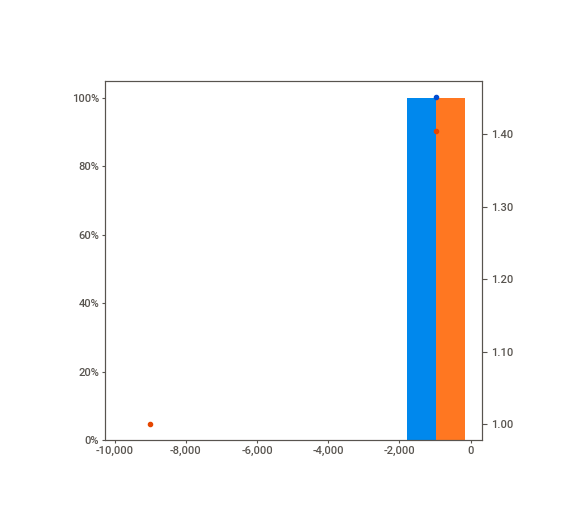
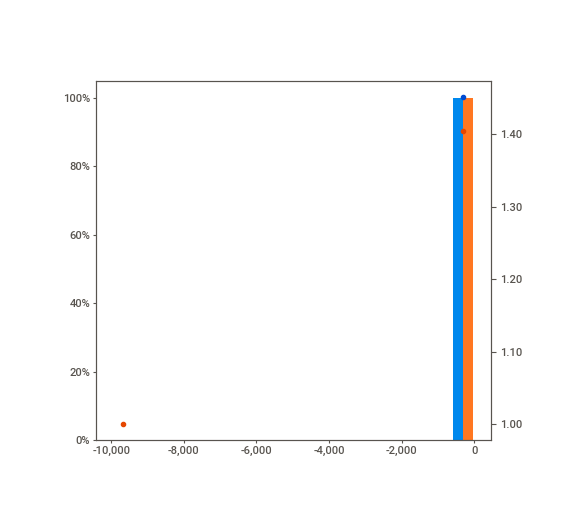
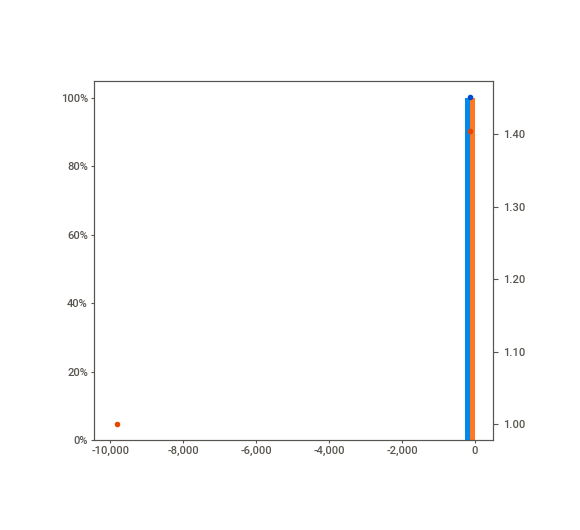
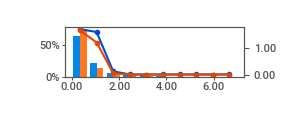
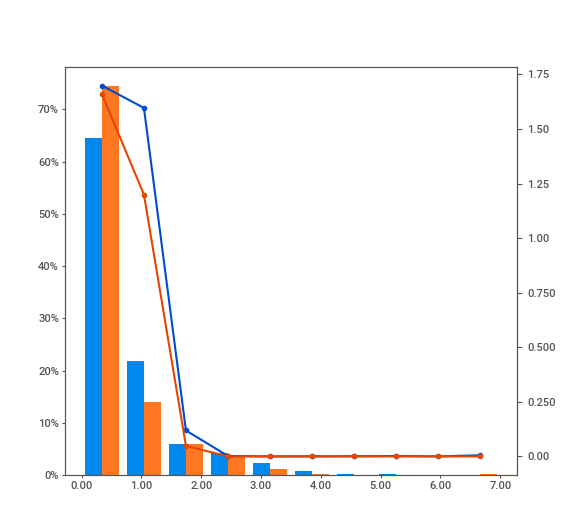
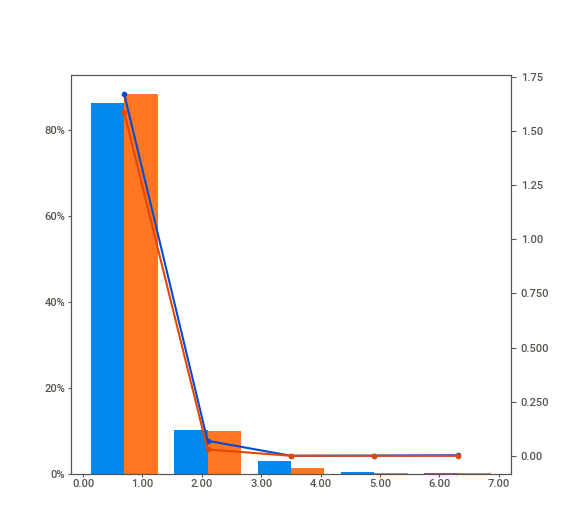
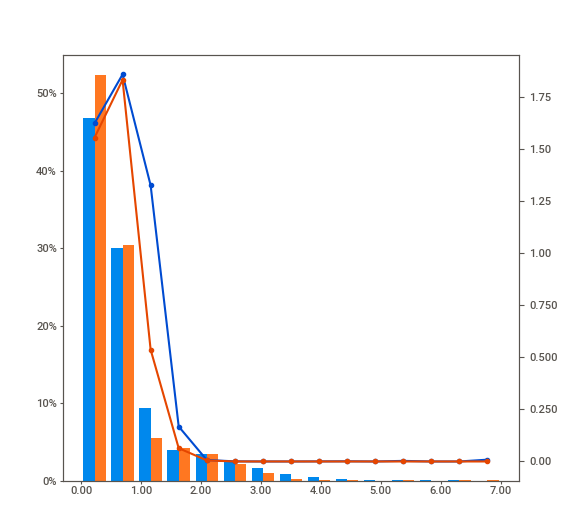
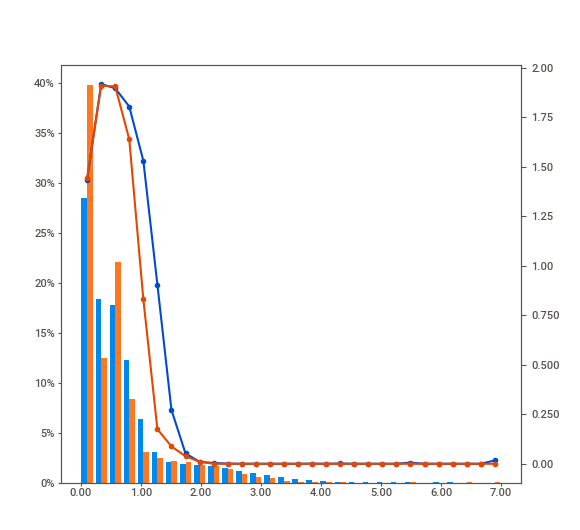
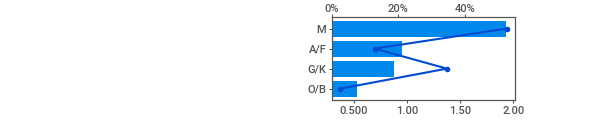
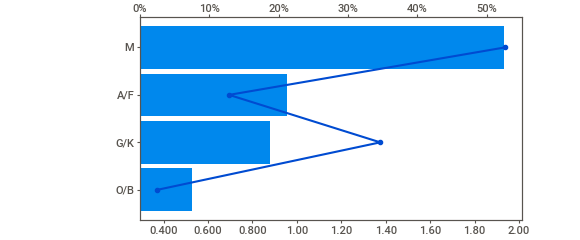
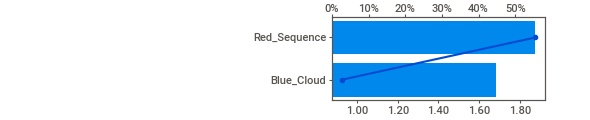
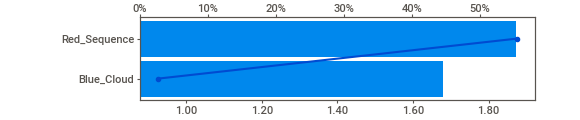
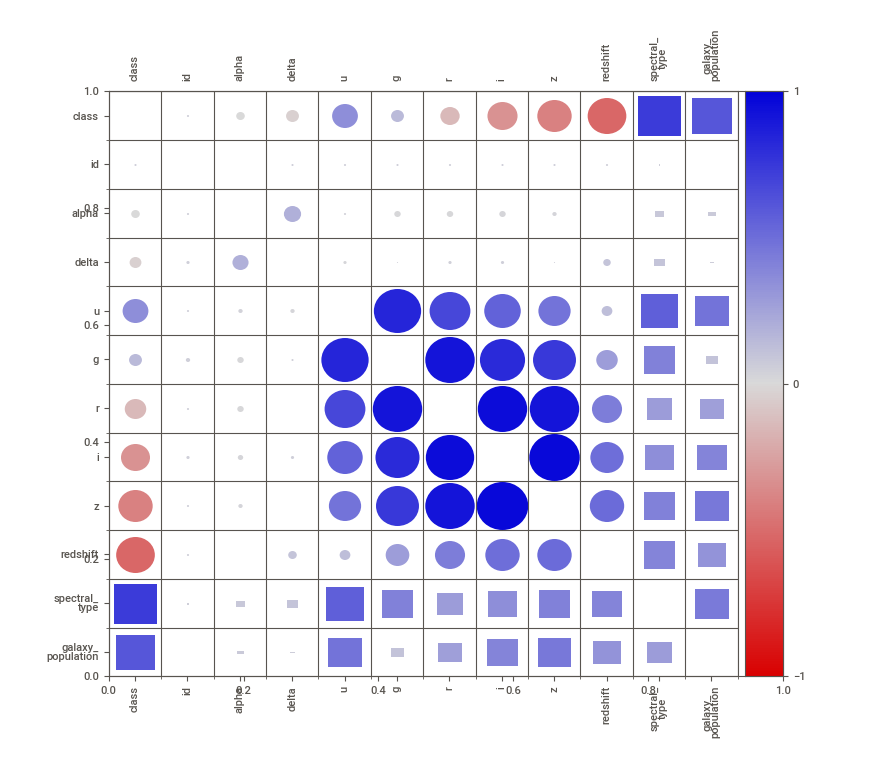
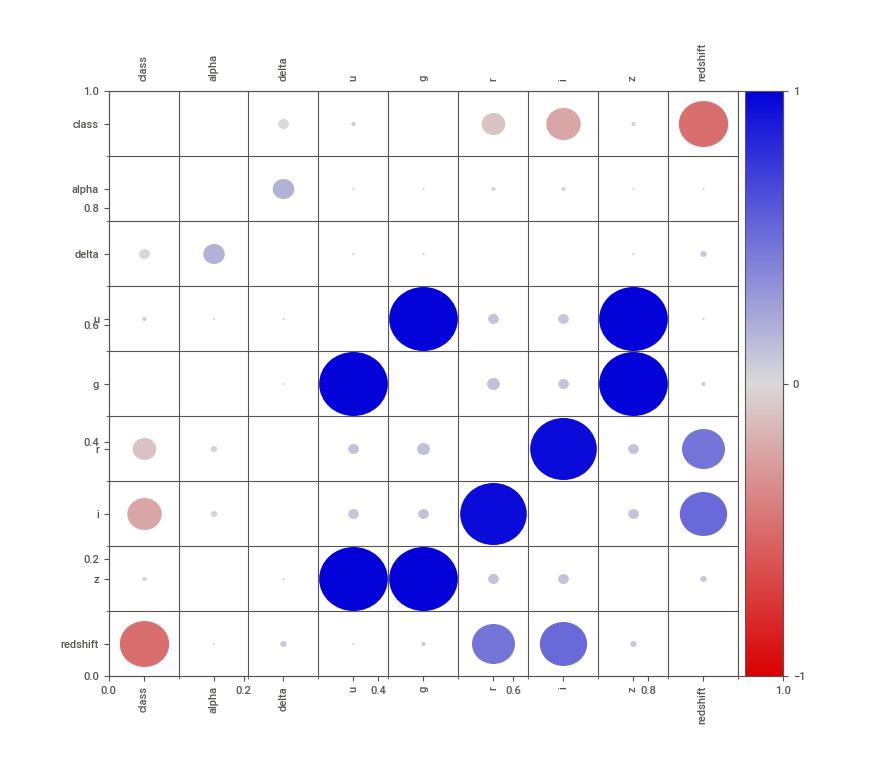

In [8]:
original_df_sv = original_df.copy()
original_df_sv[TARGET] = original_df_sv[TARGET].map(target_mapping).astype(np.int8)

# Compare train vs original
train_original_comparison_report = sv.compare(
    [training_df_sv, "Training Data"],
    [original_df_sv, "Original Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)
train_original_comparison_report.show_notebook(
    w="100%",
    h=700,
    layout='vertical'
)


In addition to the train/test comparison, `sweetviz` can generate a full standalone profile of the training data alone via `sv.analyze`. This report provides per-feature breakdowns of distributions, missing values, and correlations against the target.  This is useful to examine before introducing the test set into the picture.

                                             |                                                                …


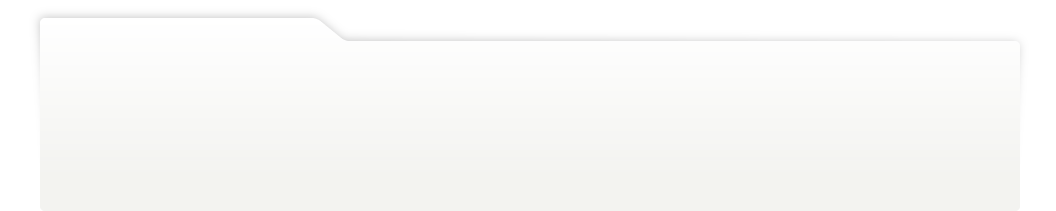
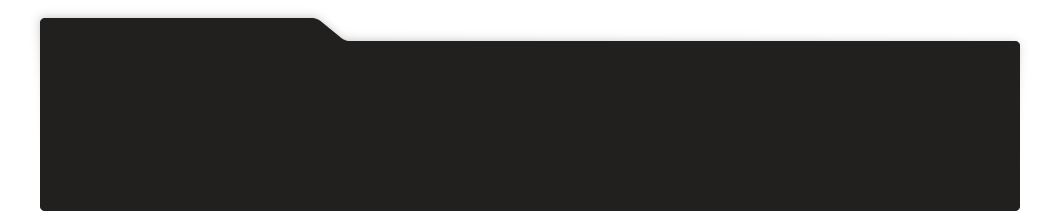
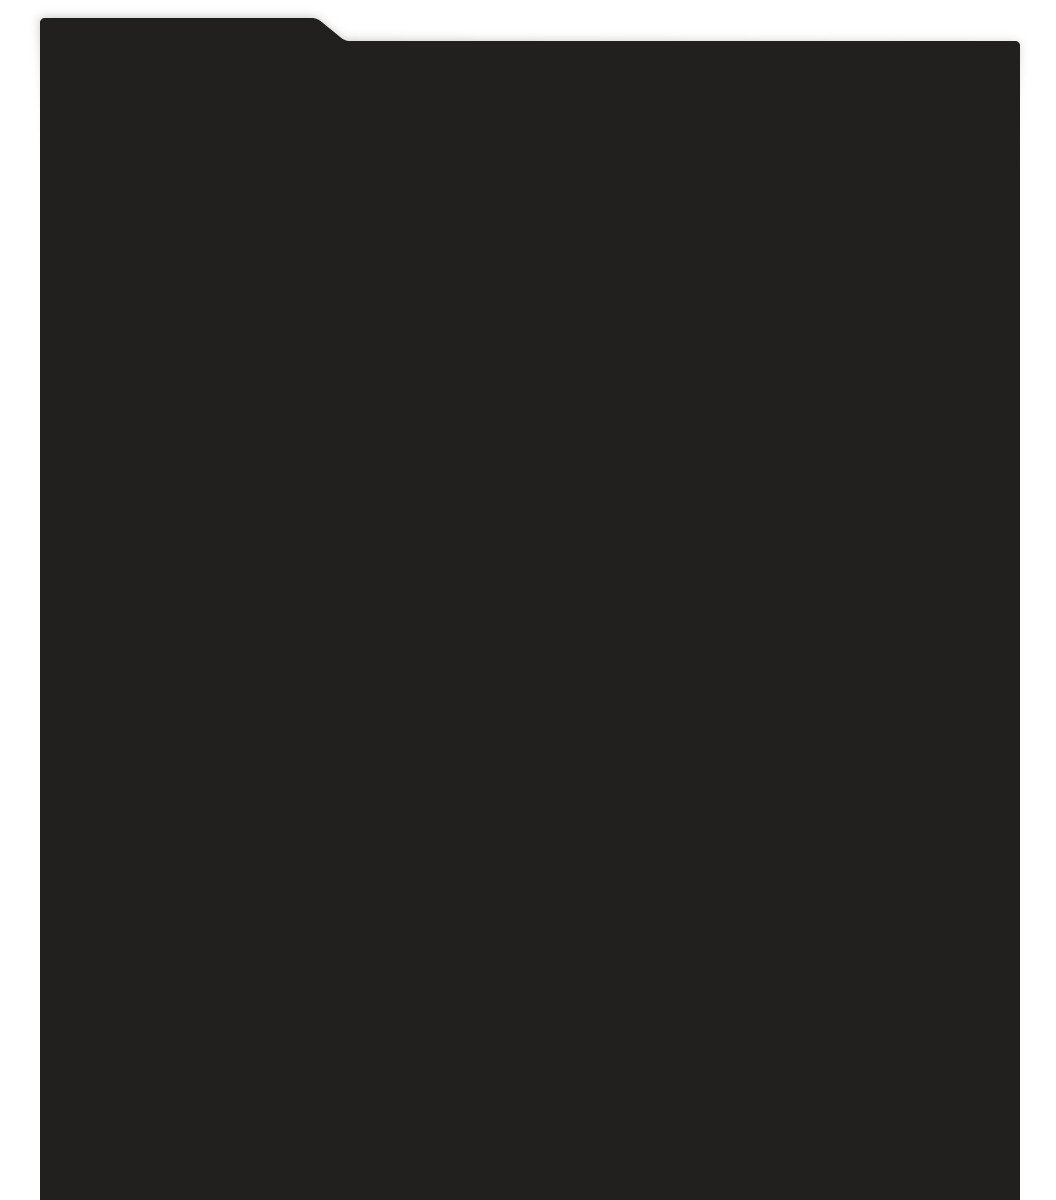
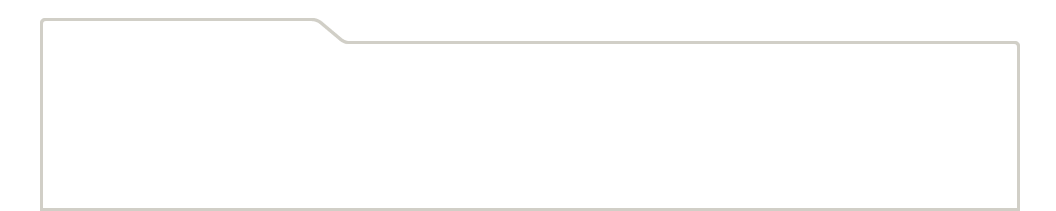
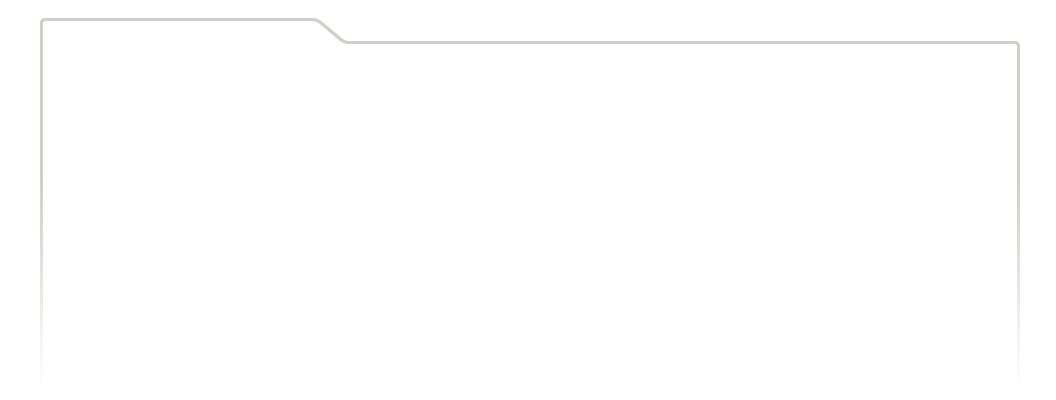
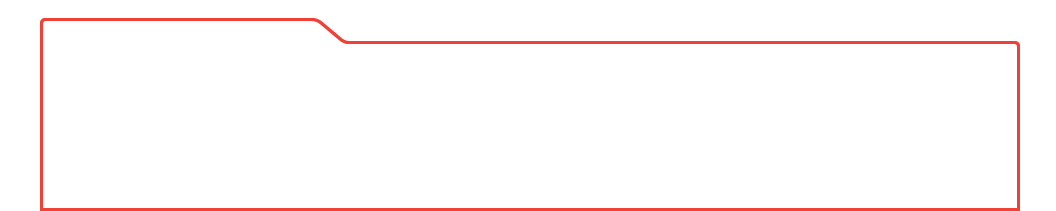
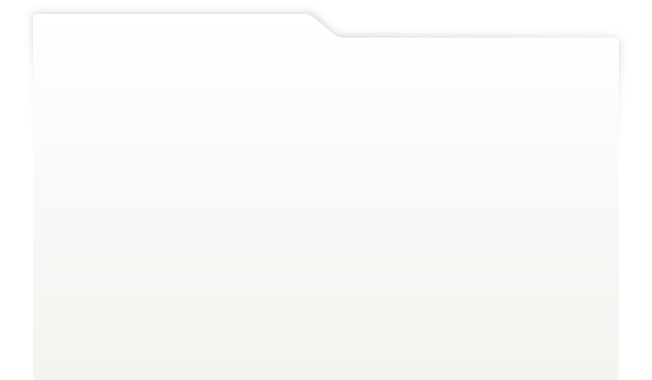
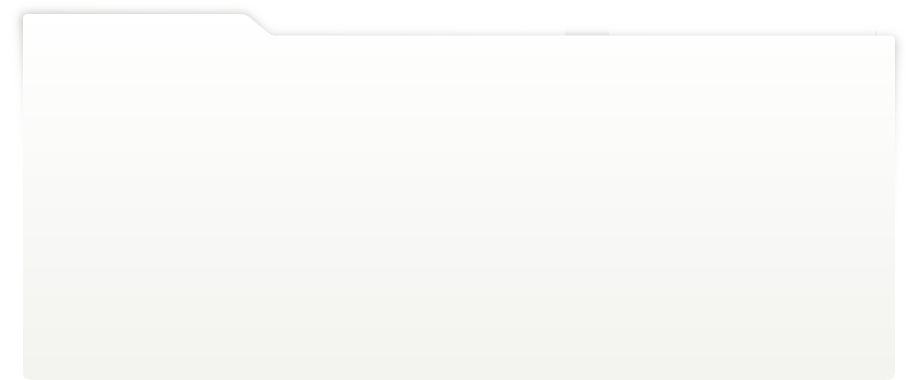
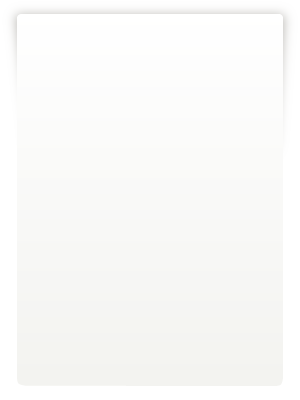
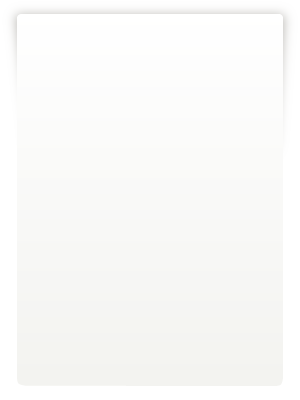
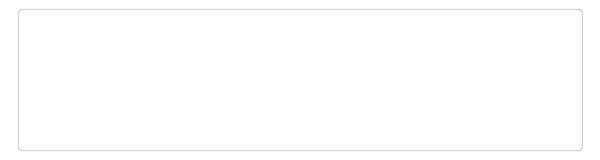
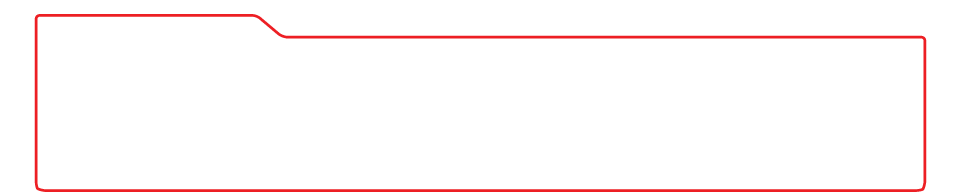
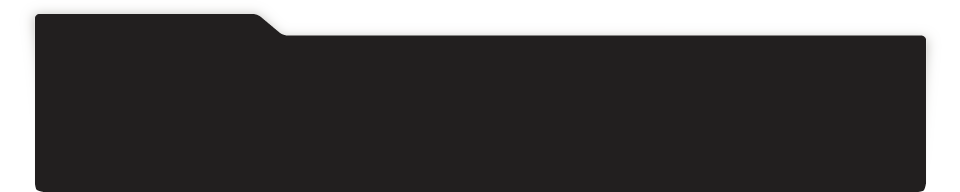
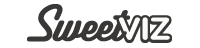
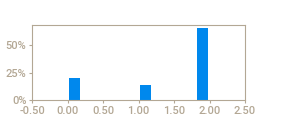
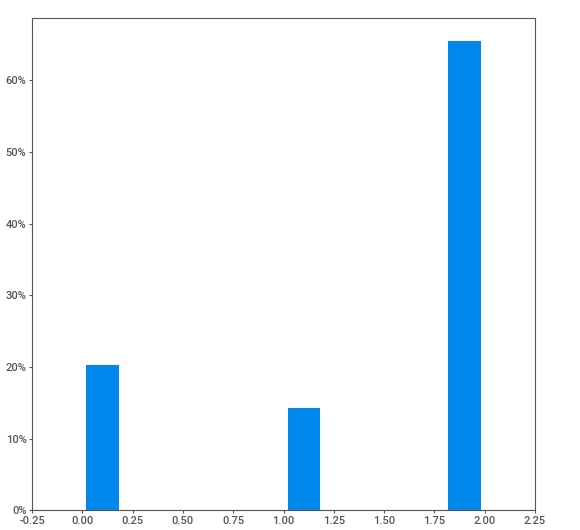
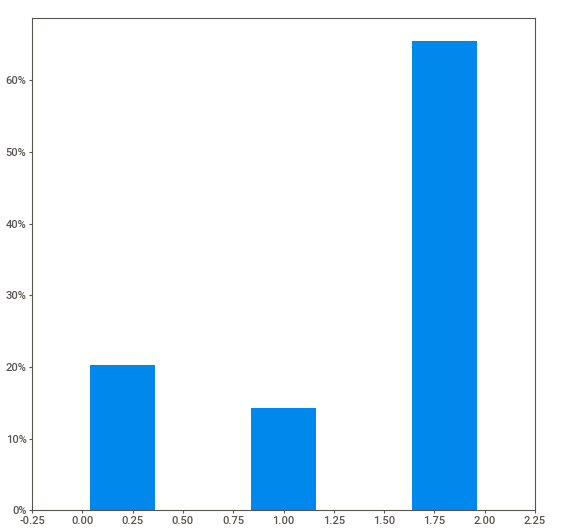
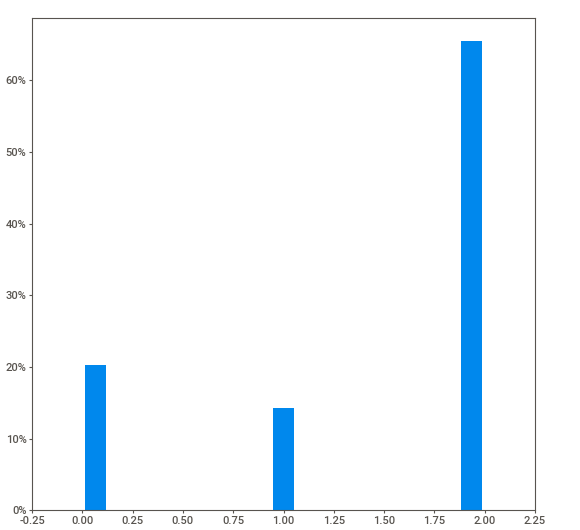
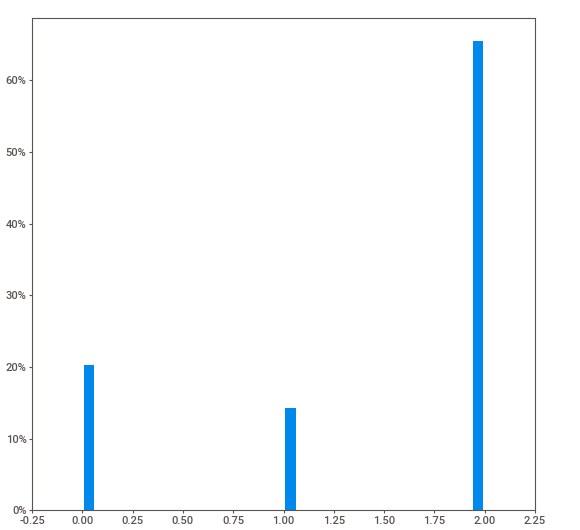
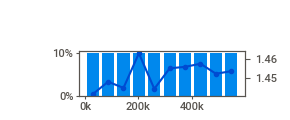
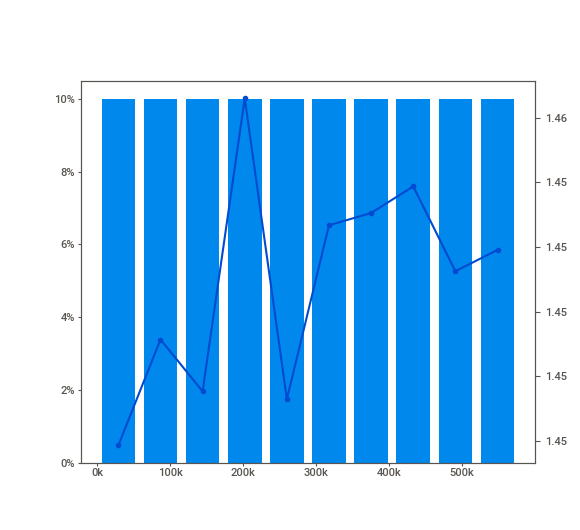
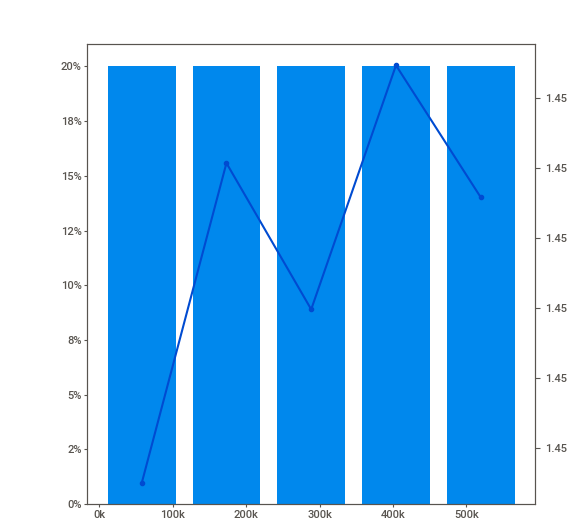
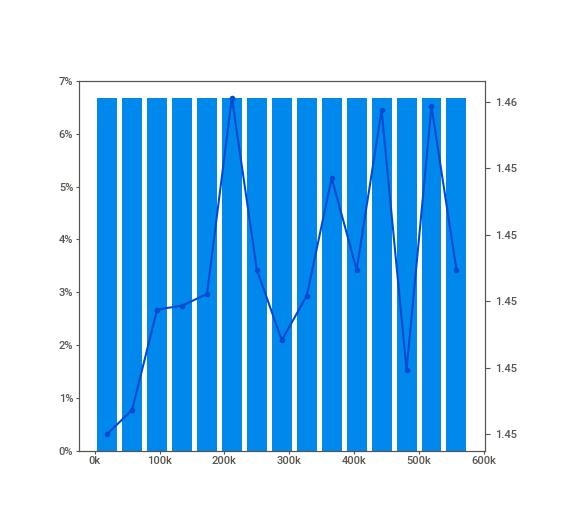
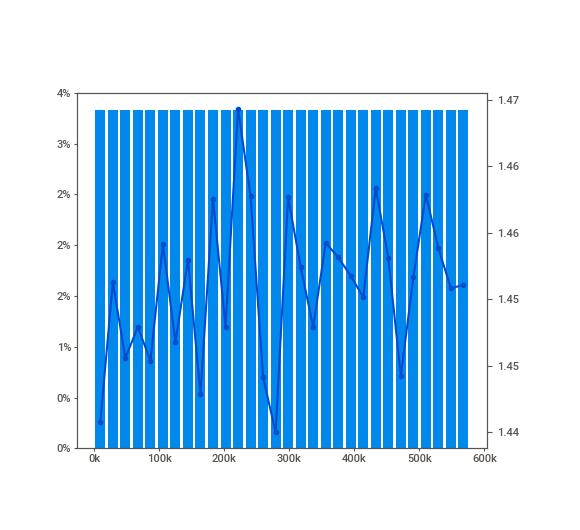
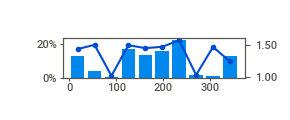
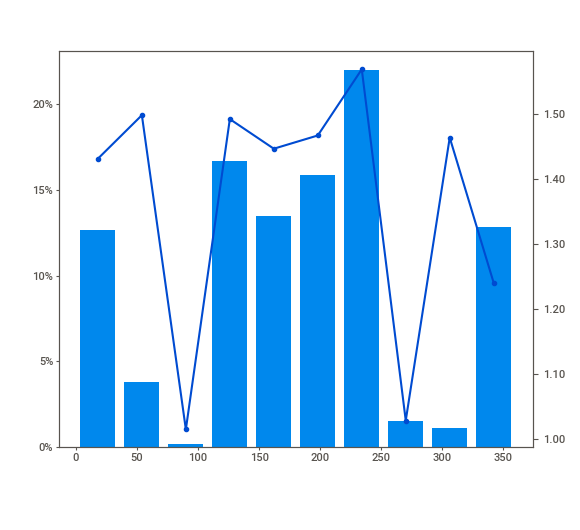
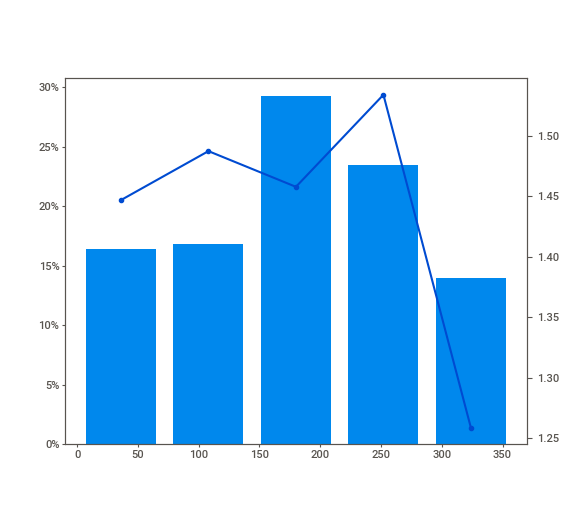
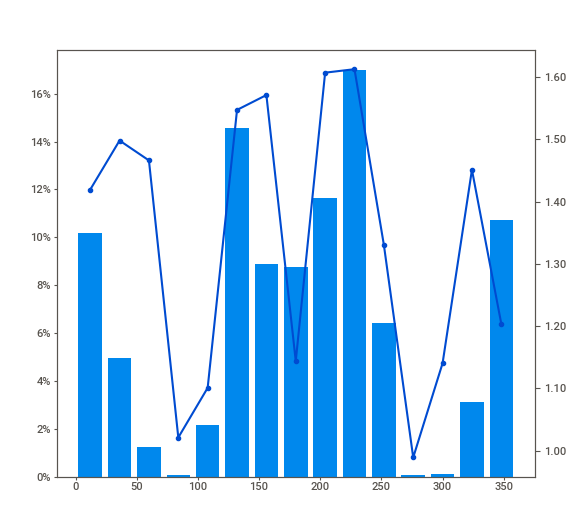
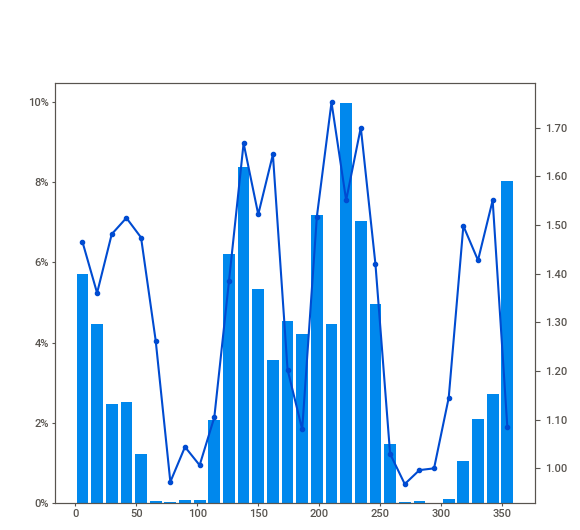
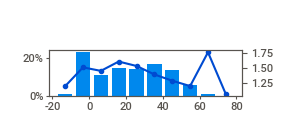
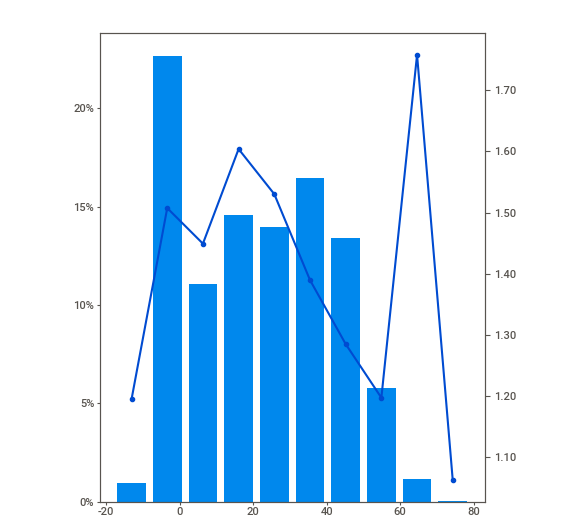
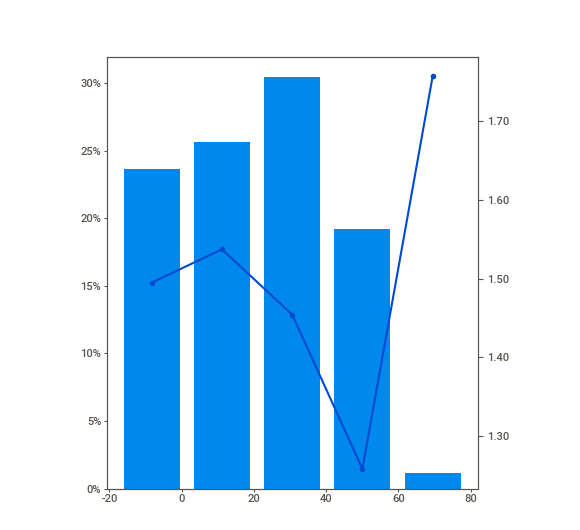
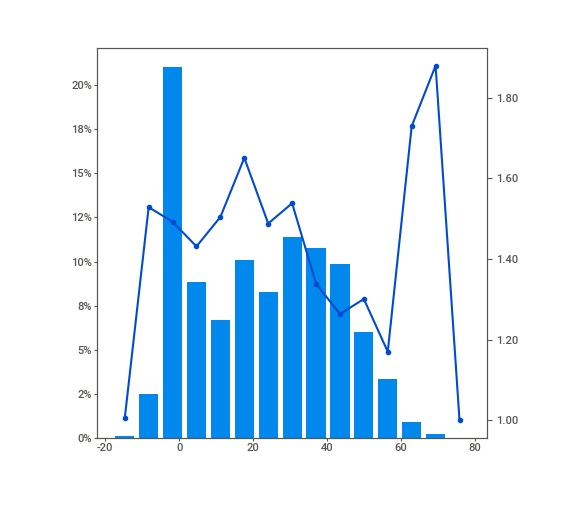
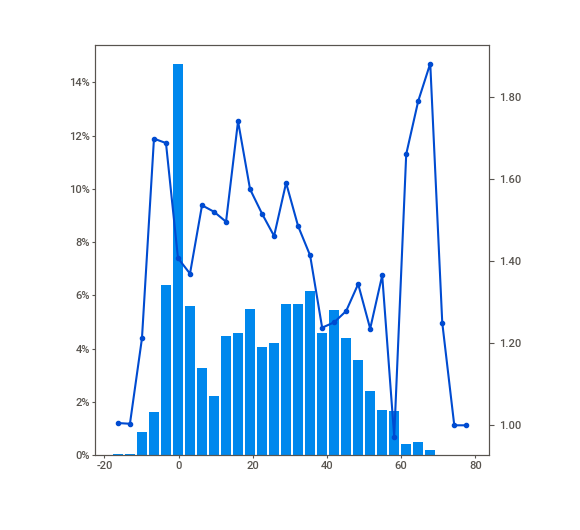
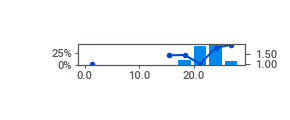
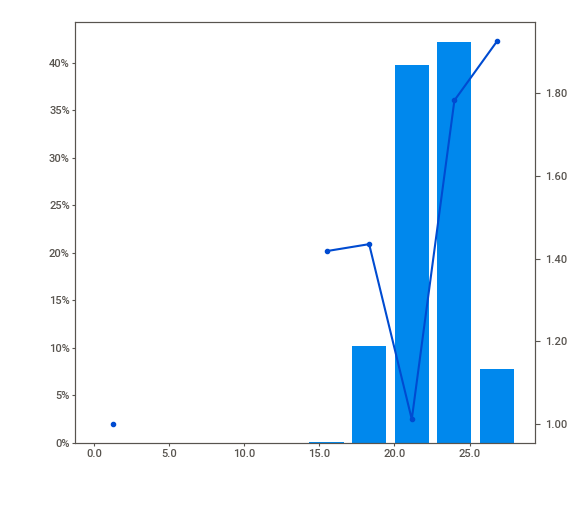
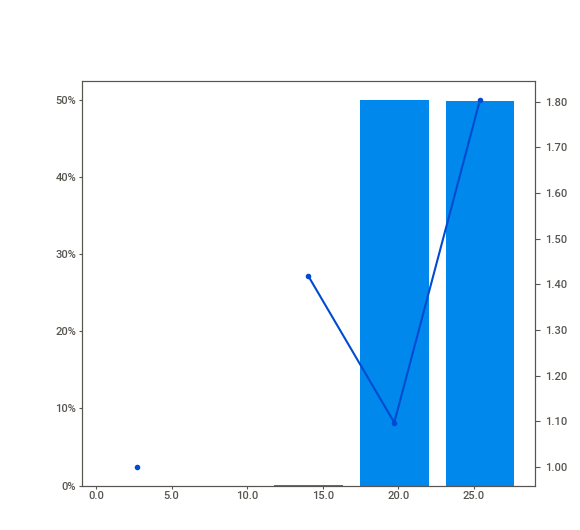
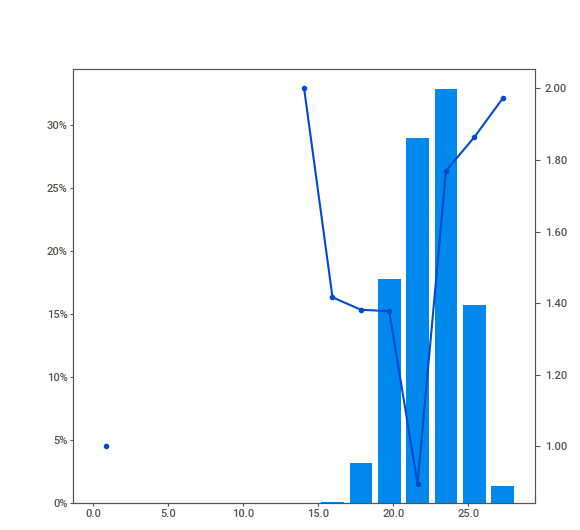
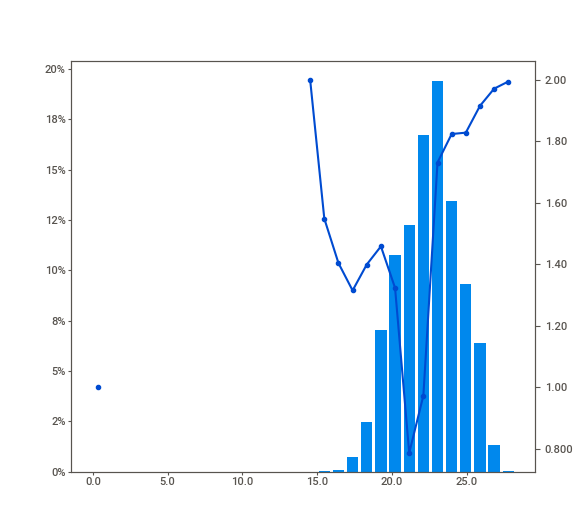
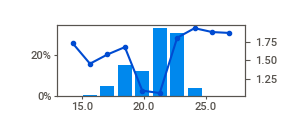
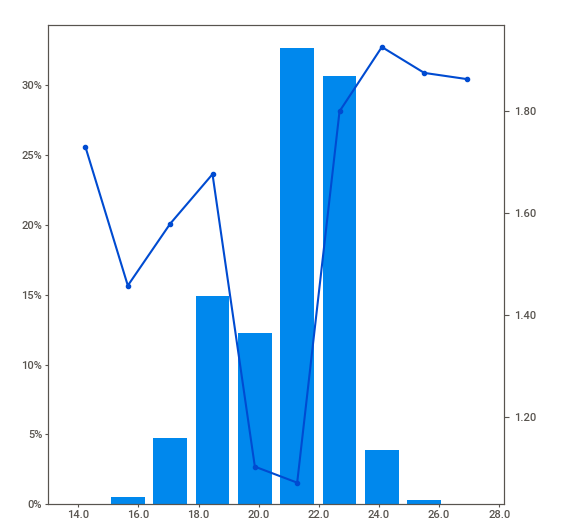
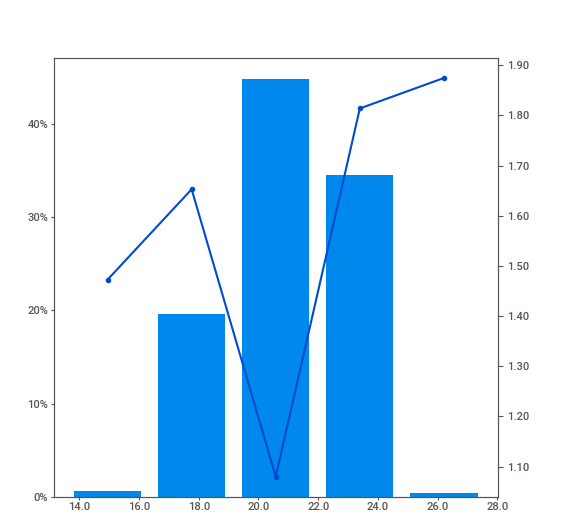
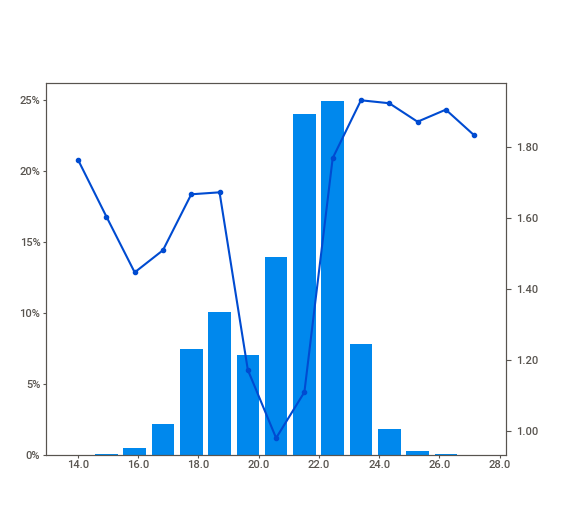
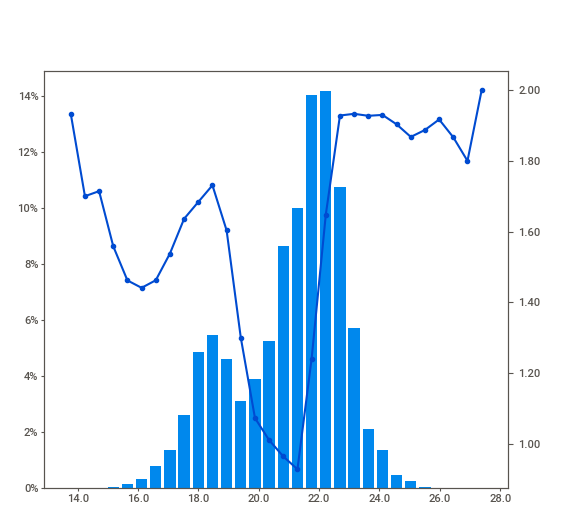
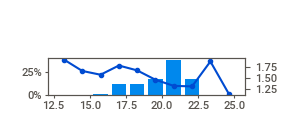
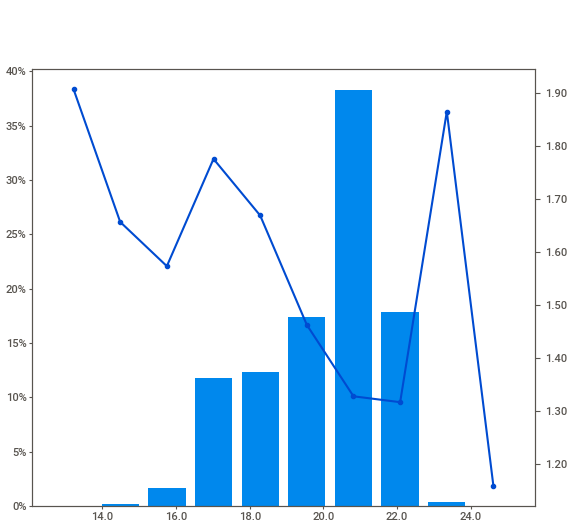
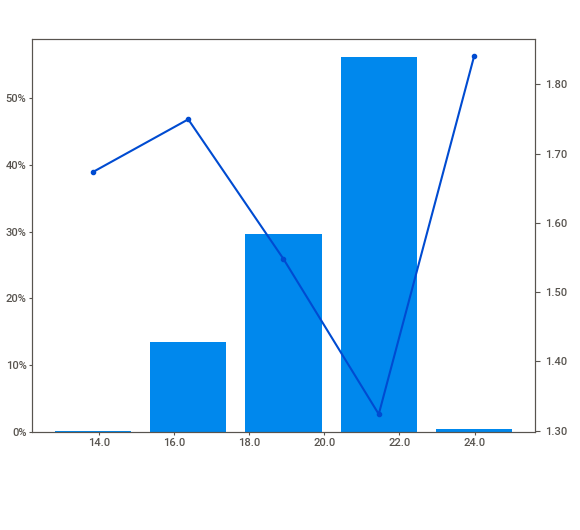
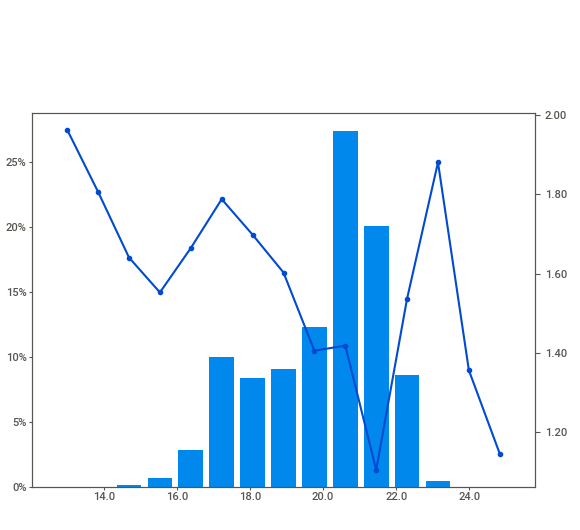
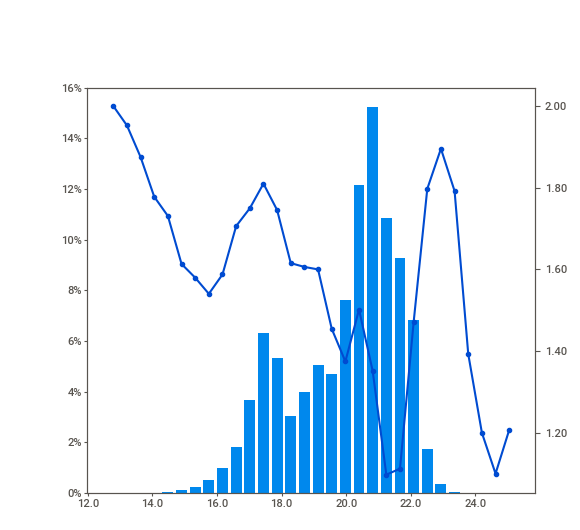
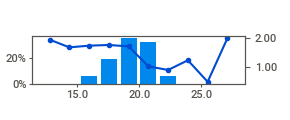
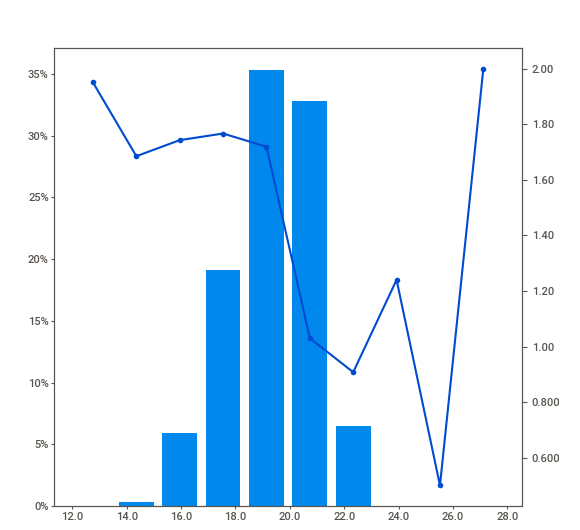
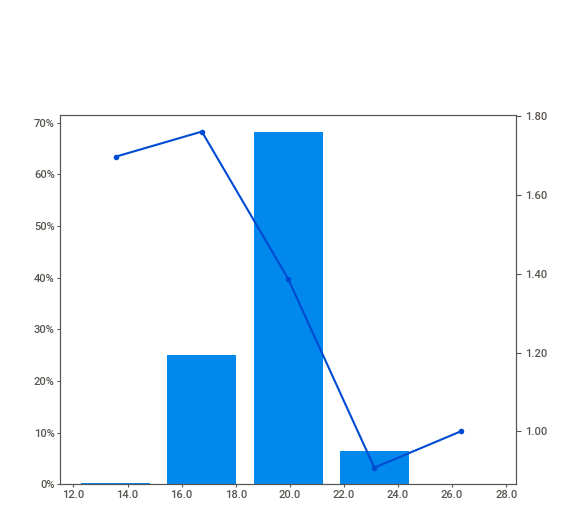
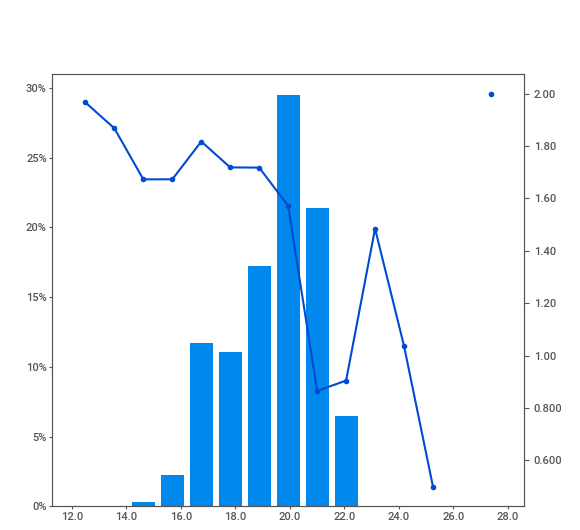
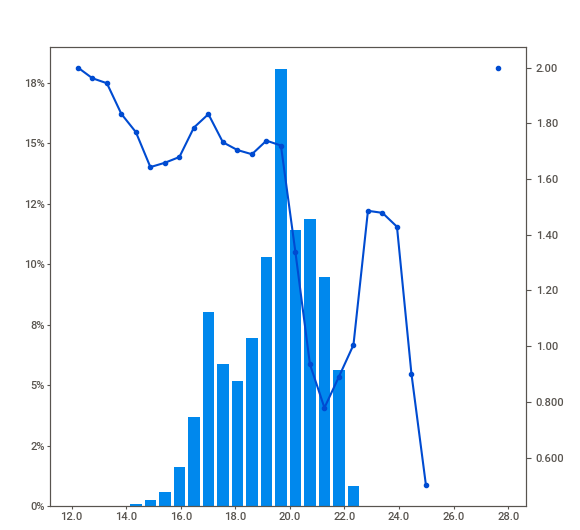
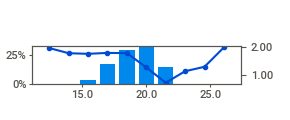
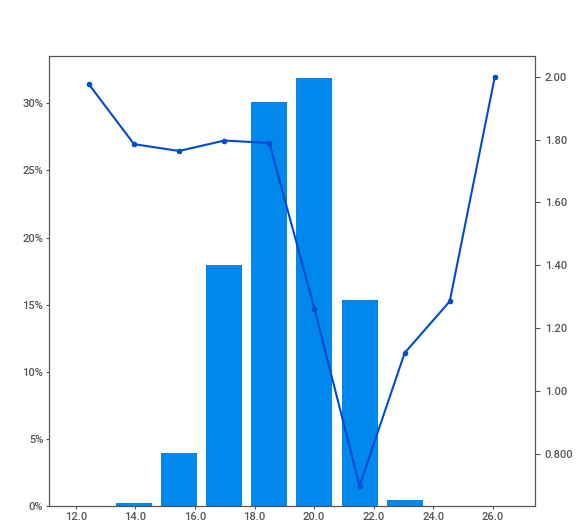
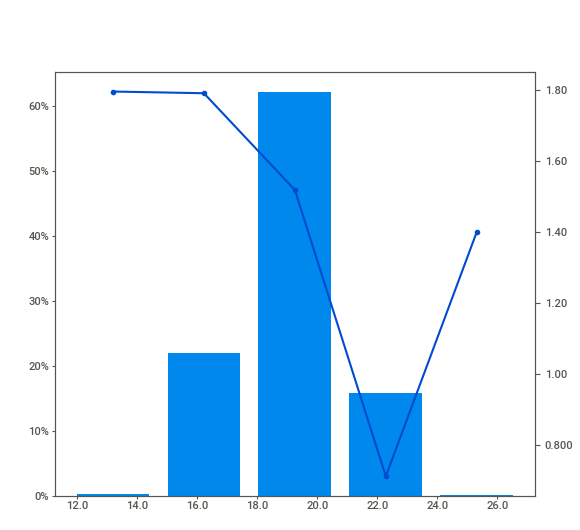
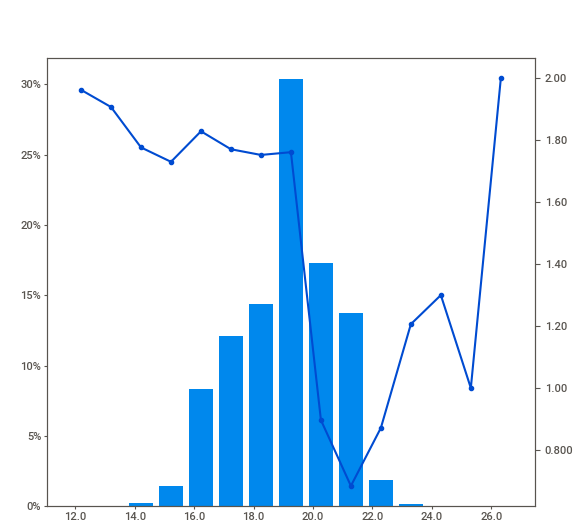
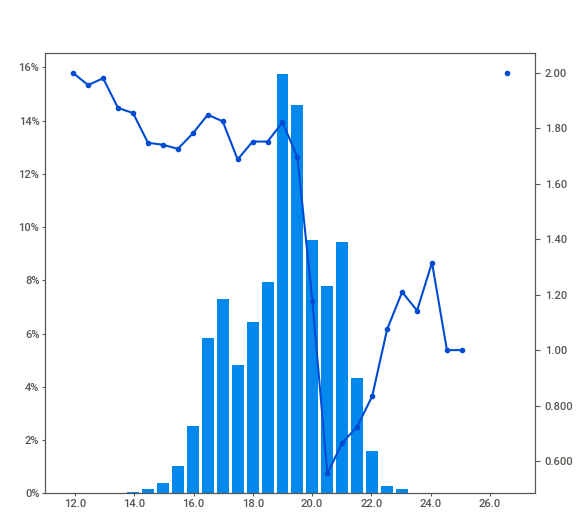
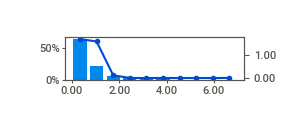
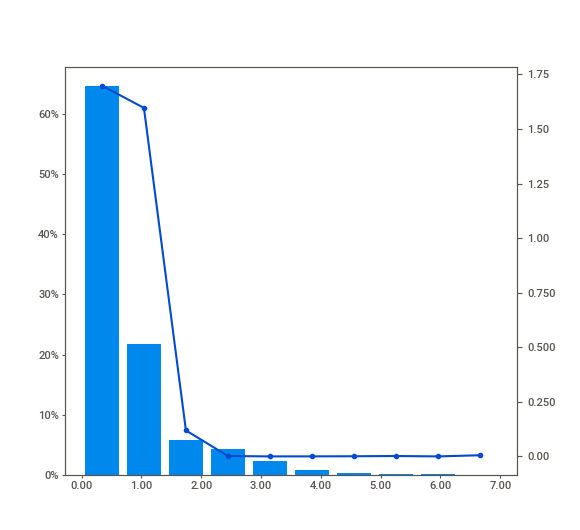
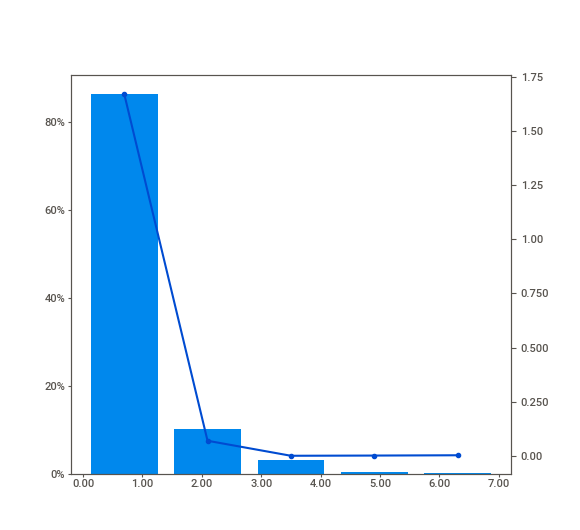
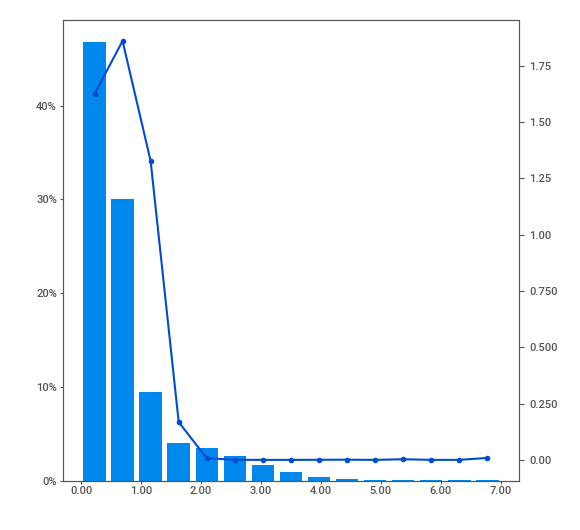
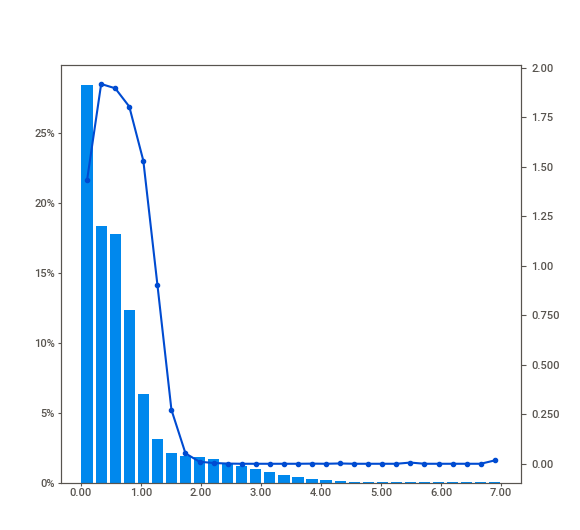
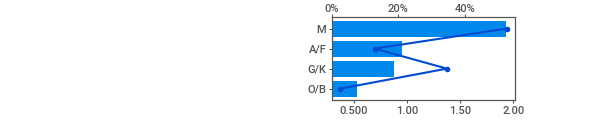
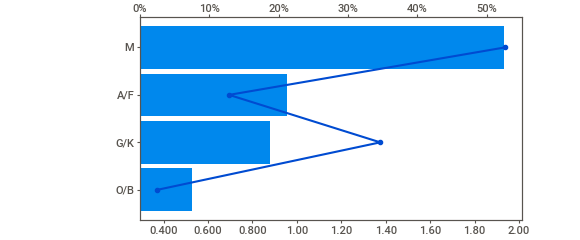
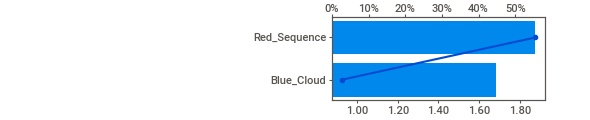
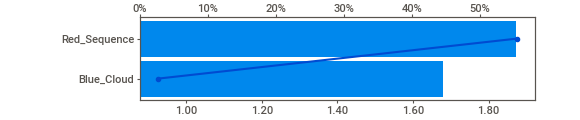
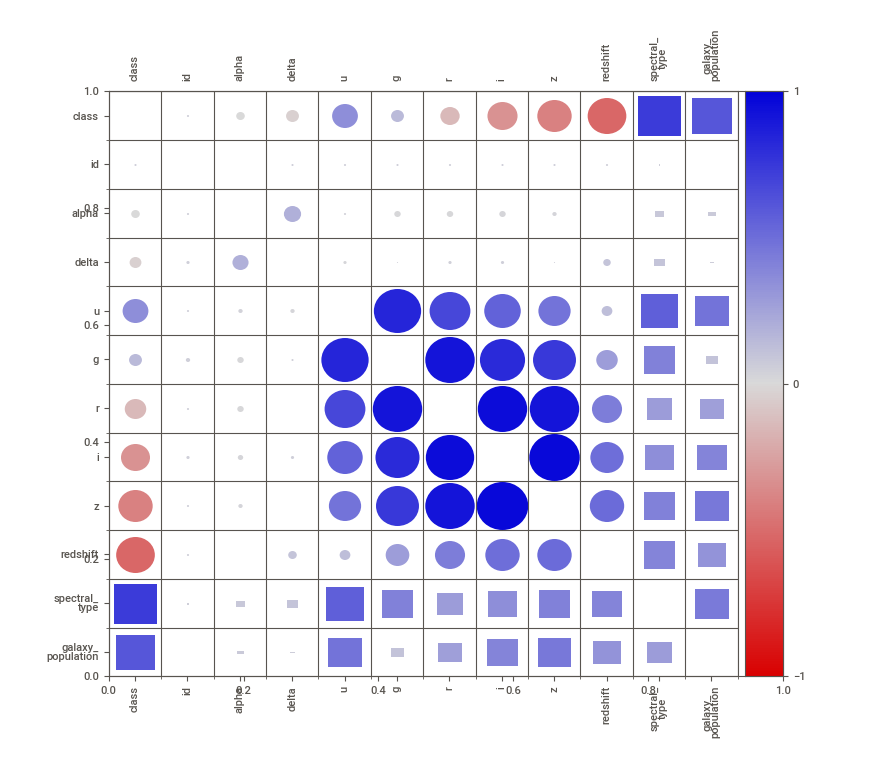
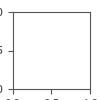

In [9]:
# Full profile of training data alone
training_report = sv.analyze(
    [training_df_sv, "Training Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)
training_report.show_notebook(
    w="100%",
    h=700,
    layout='vertical'
)


Finally, `sv.compare_intra` lets us compare two subsets of the training data against each other. Here we split on class membership, GALAXY rows vs. all others, to surface which features carry the most discriminating signal between stellar classes. This is particularly informative for a three-class problem like this one, where understanding per-class feature separability guides both feature engineering and model selection.

                                             |                                                                …


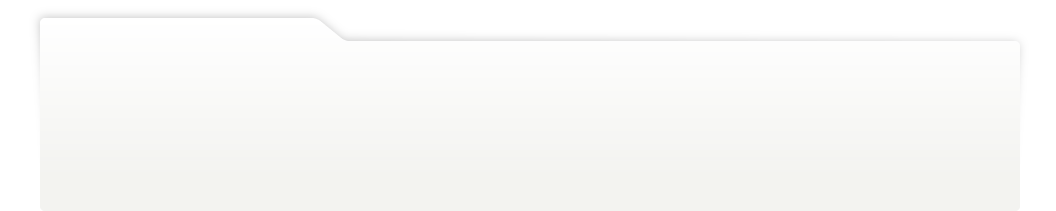
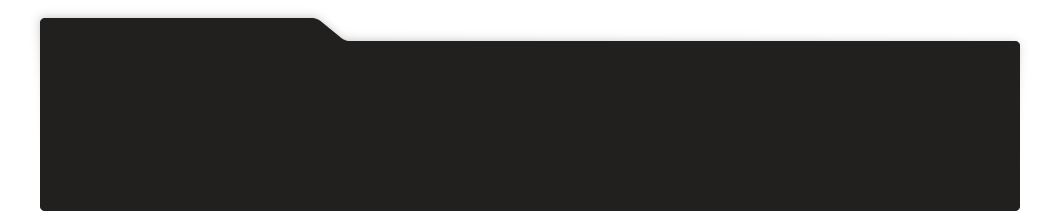
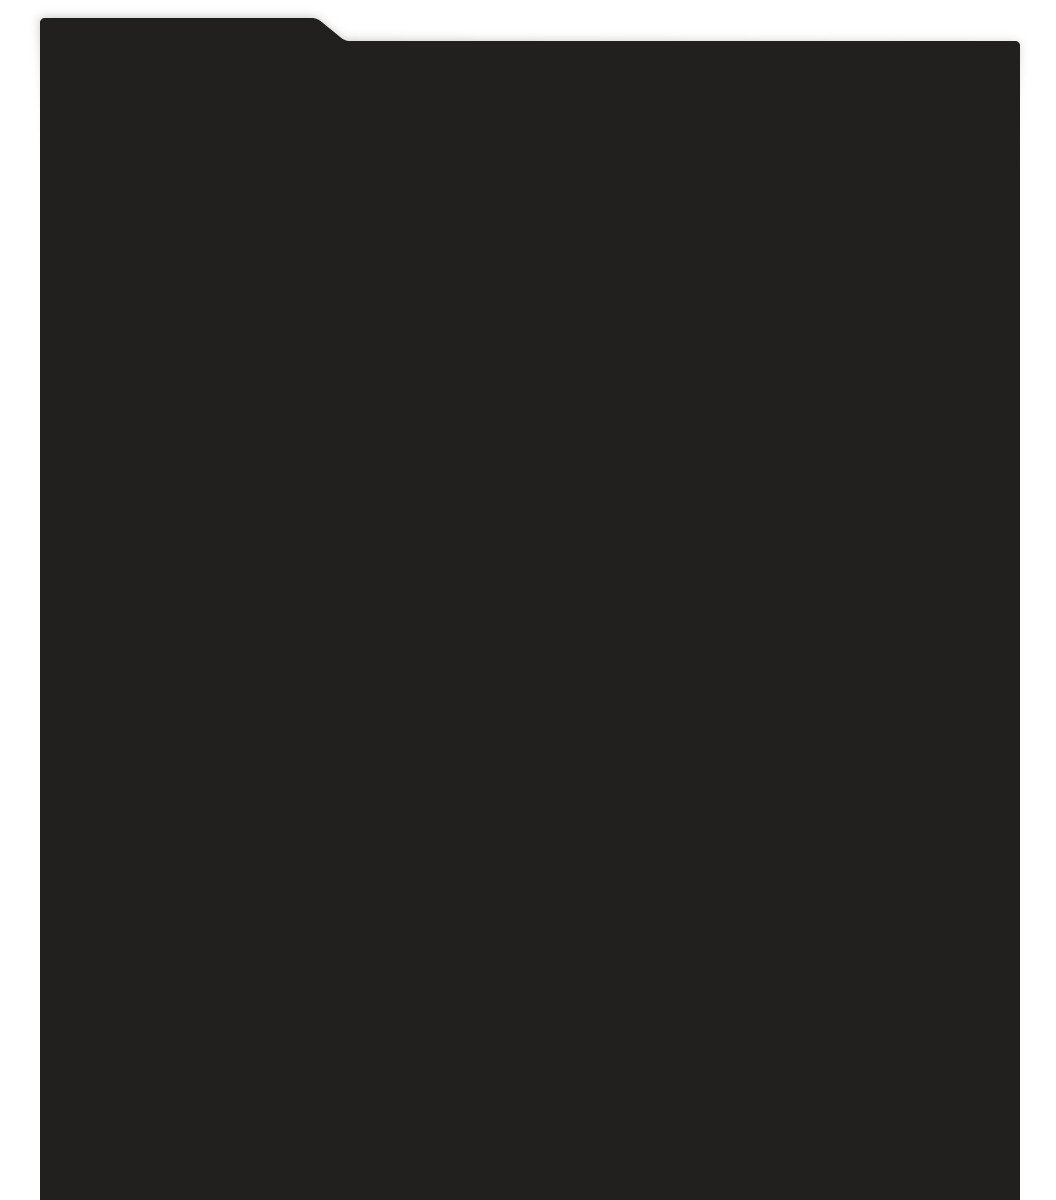
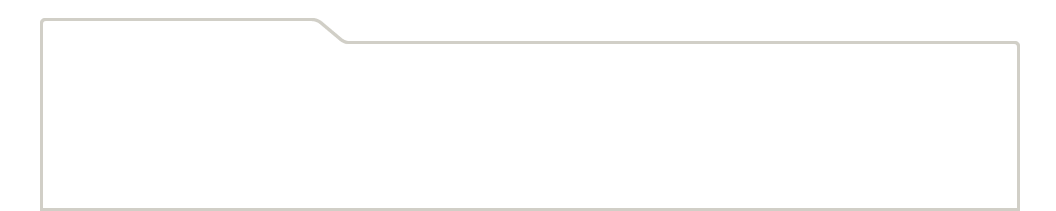
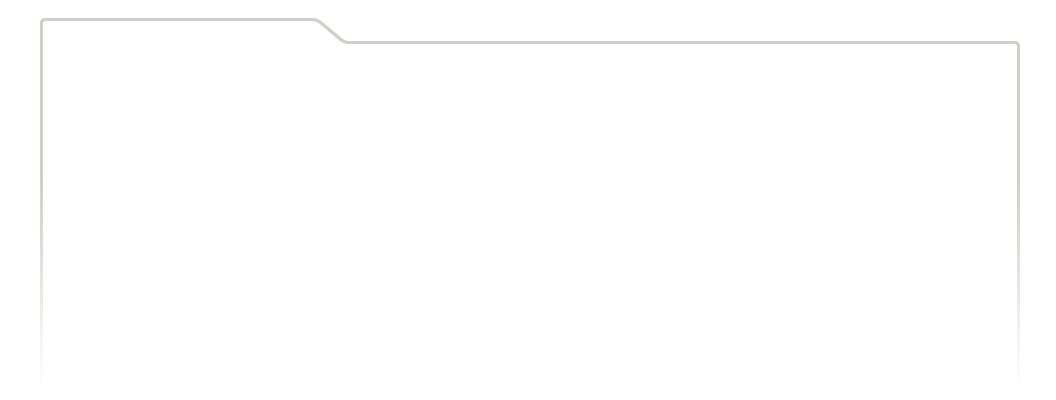
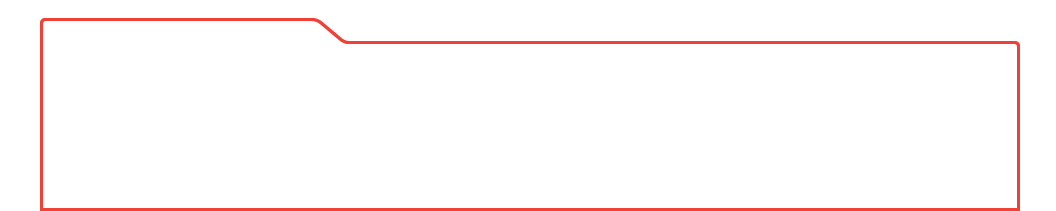
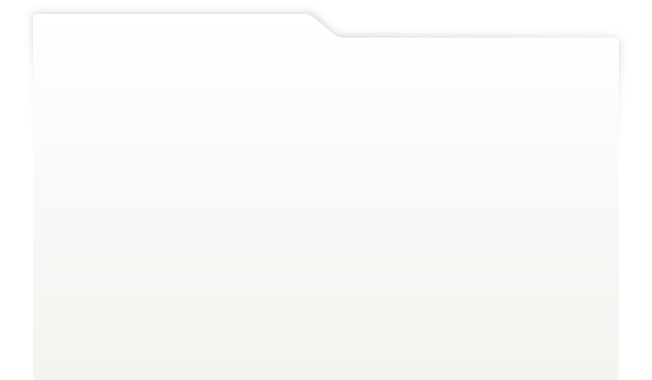
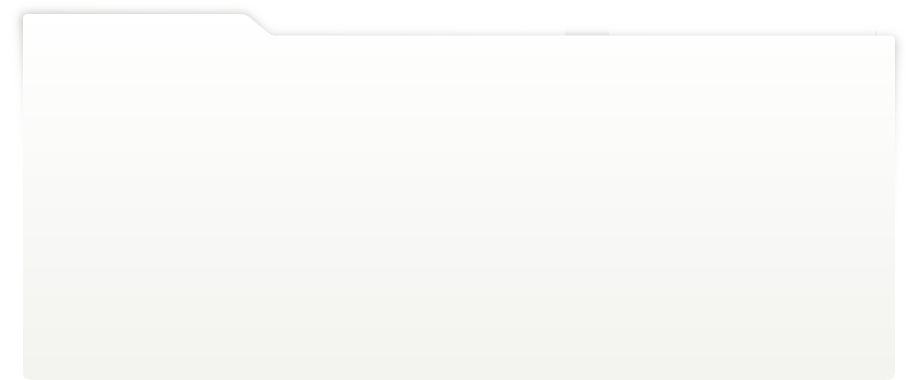
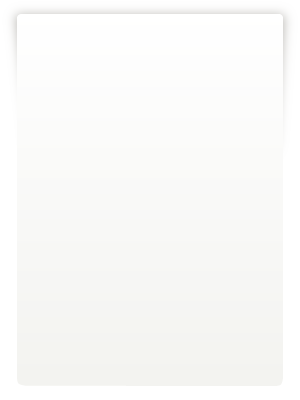
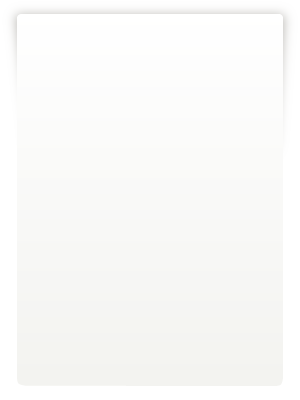
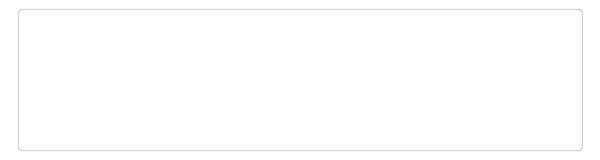
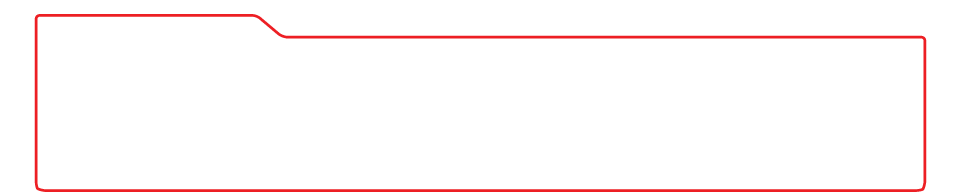
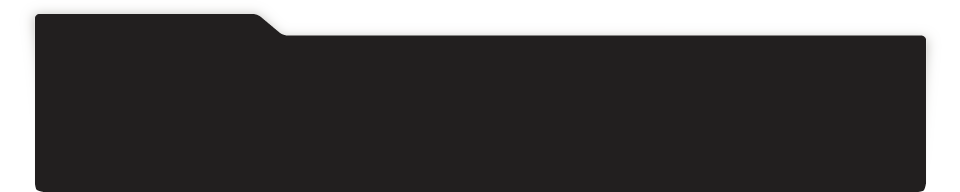
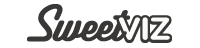
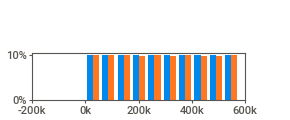
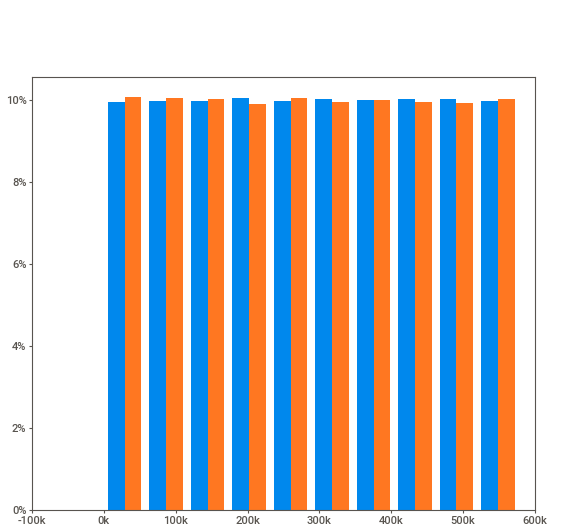
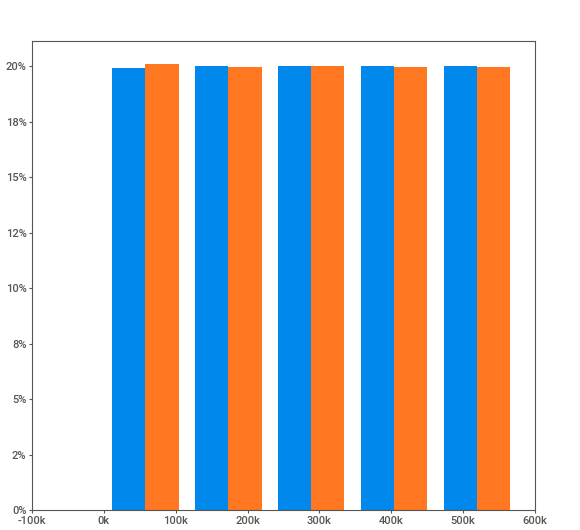
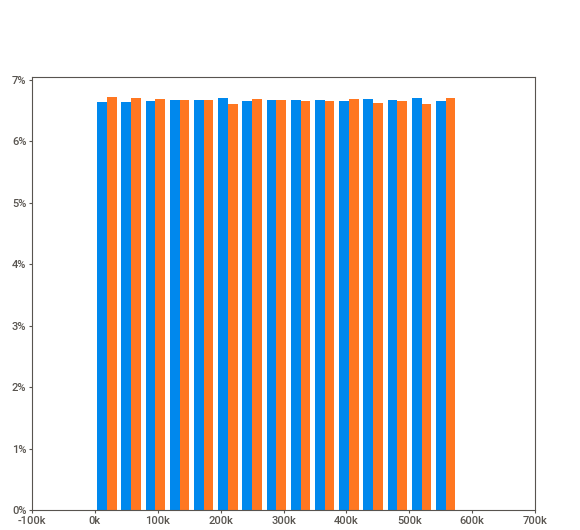
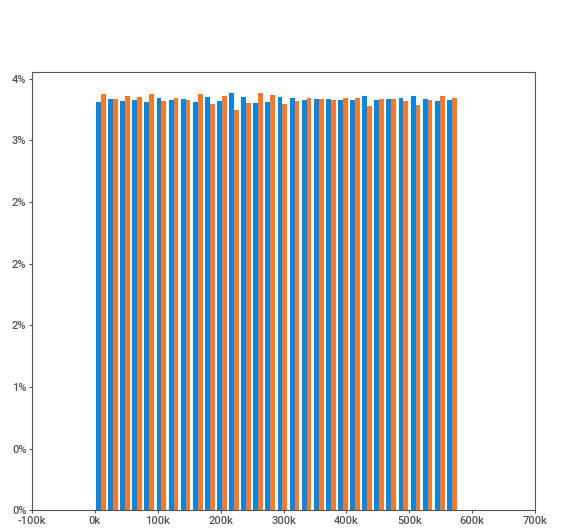
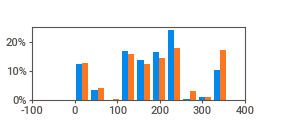
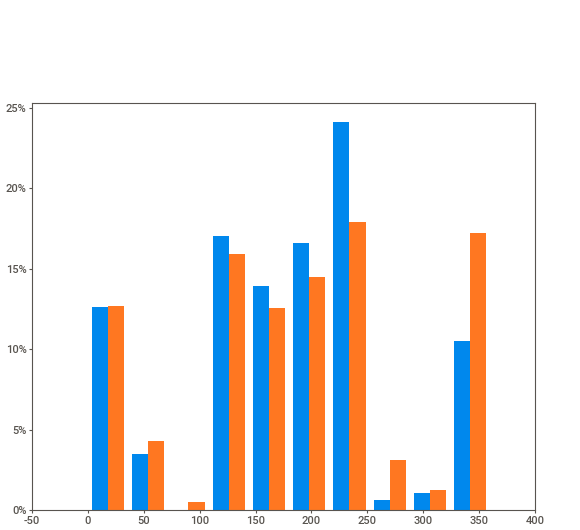
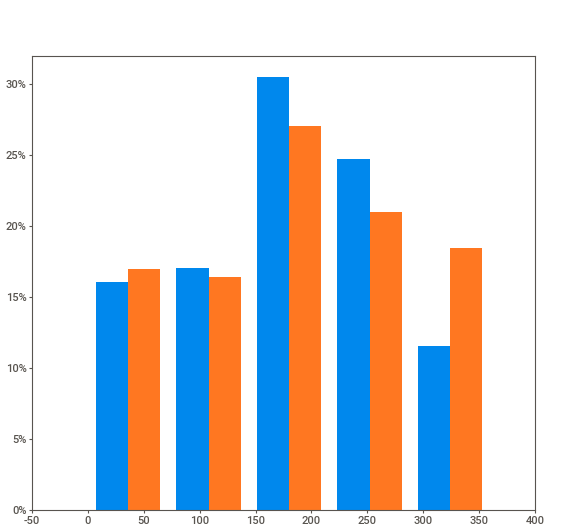
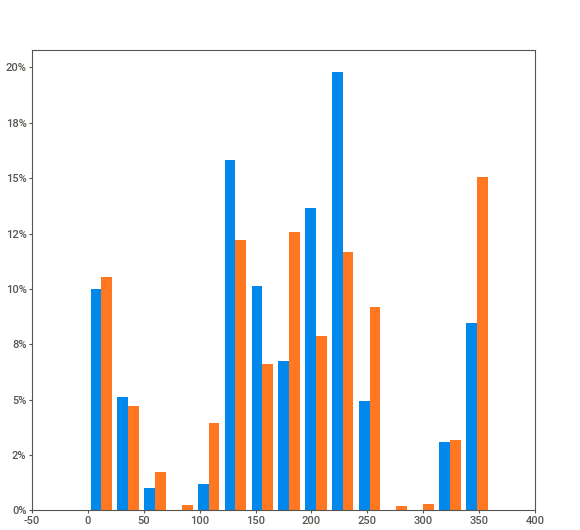
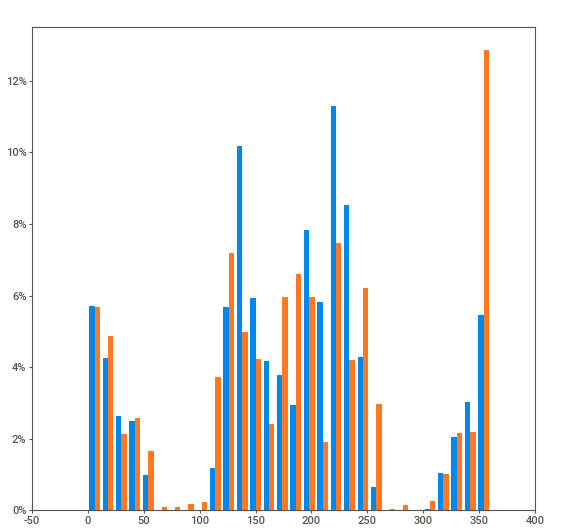
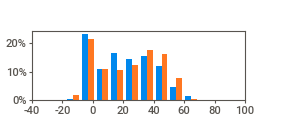
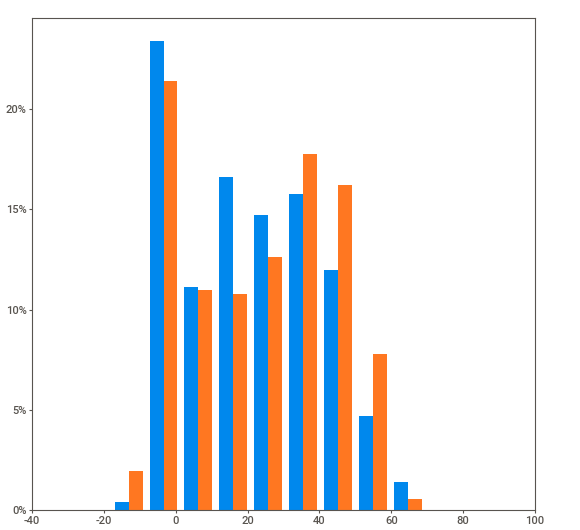
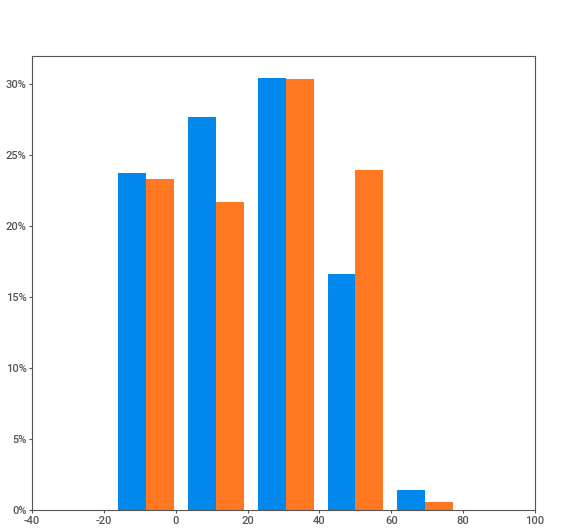
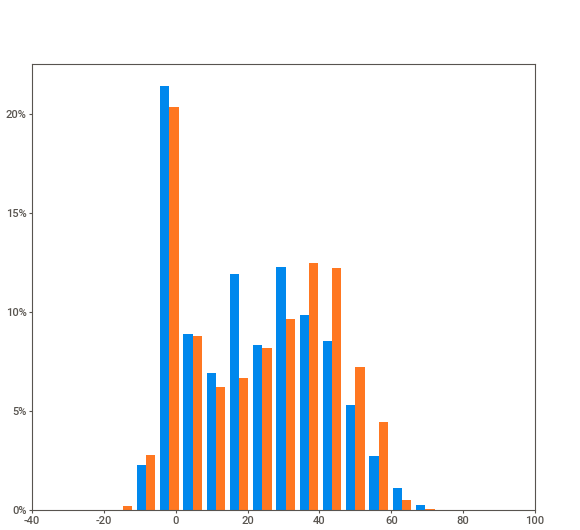
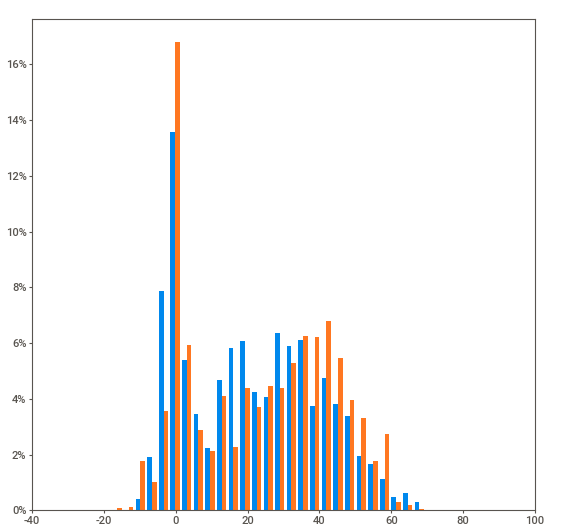
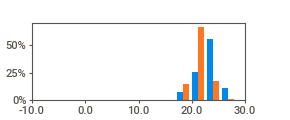
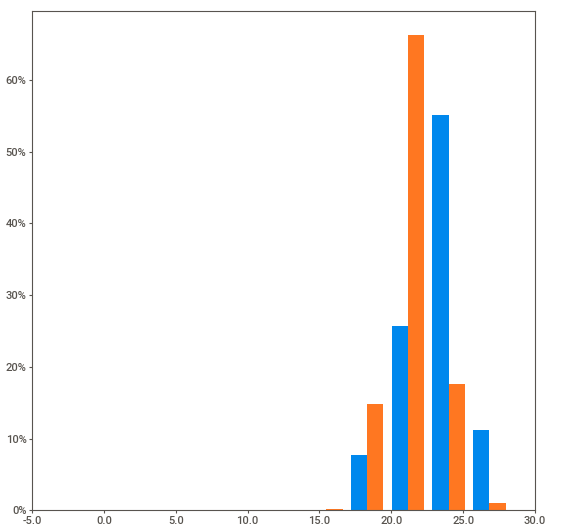
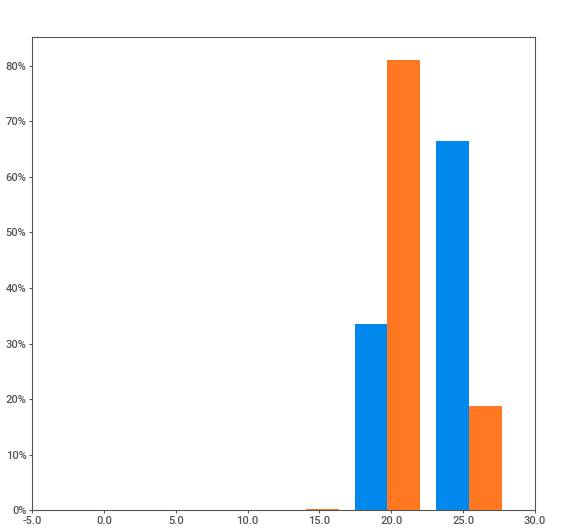
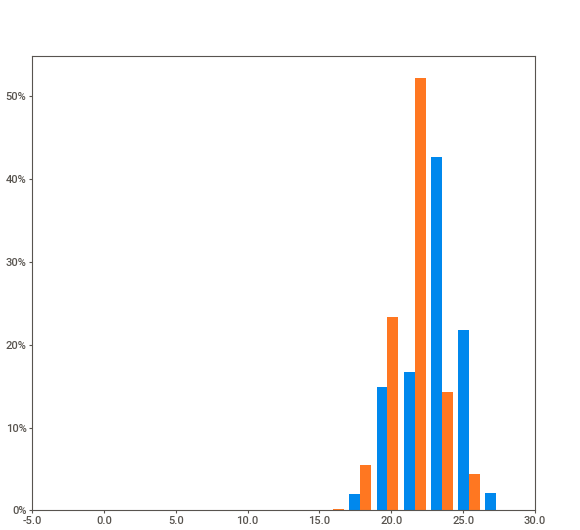
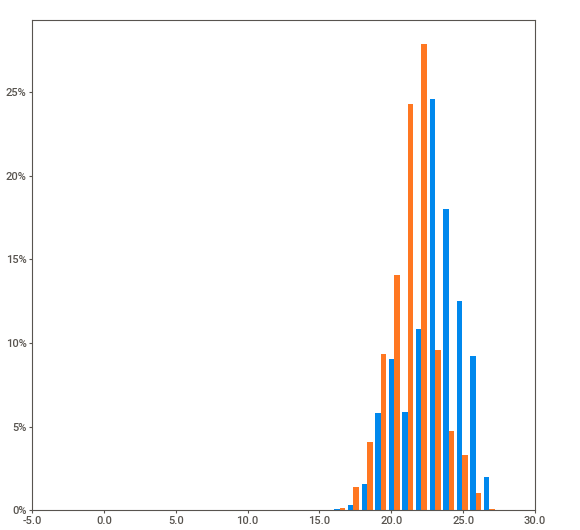
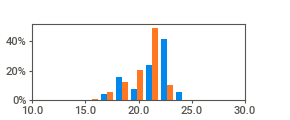
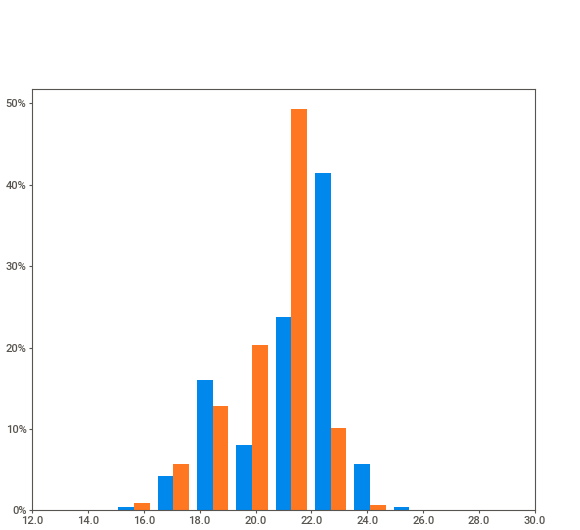
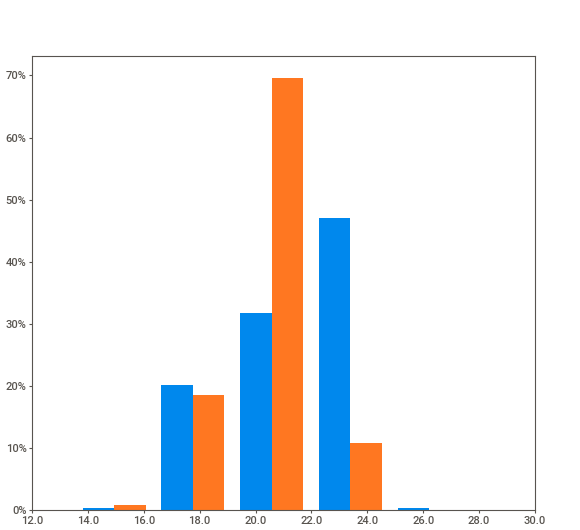
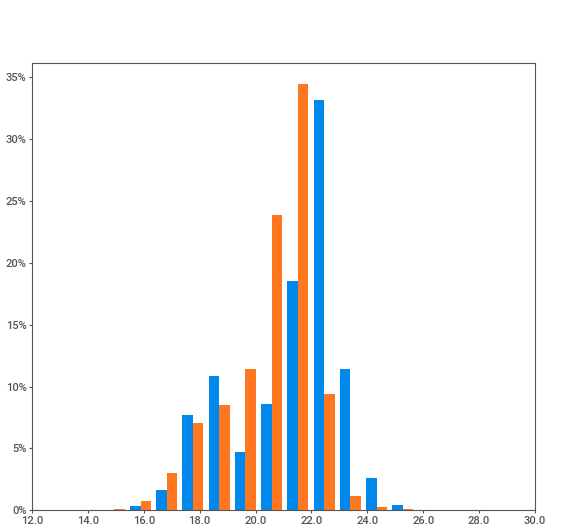
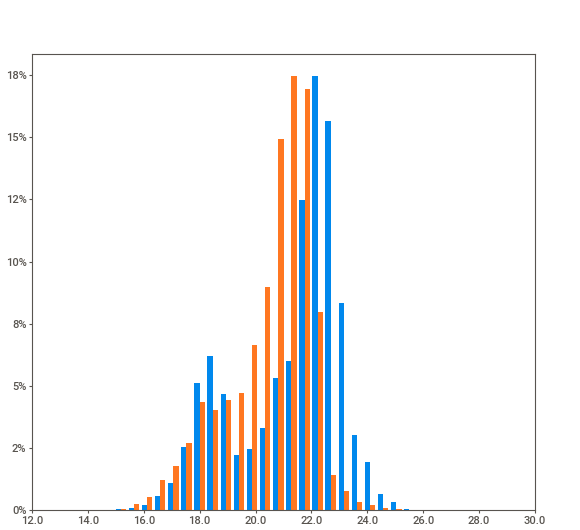
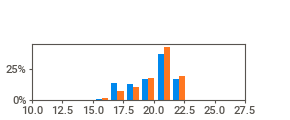
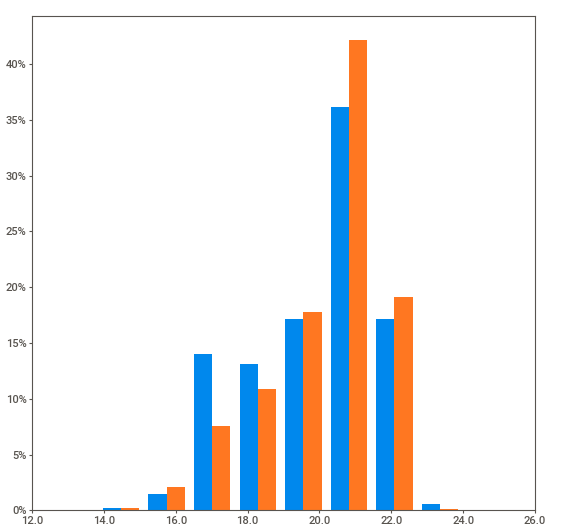
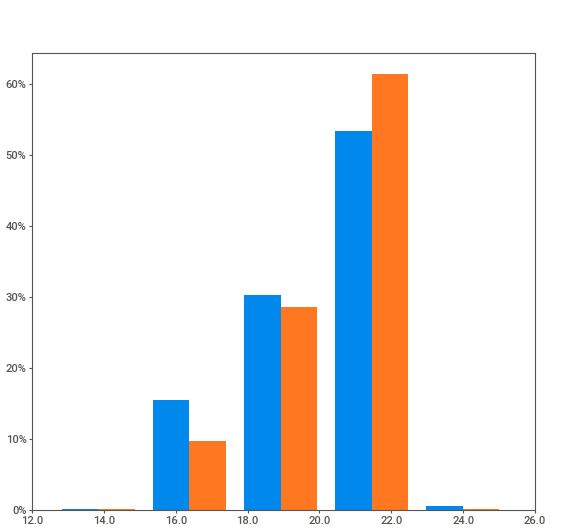
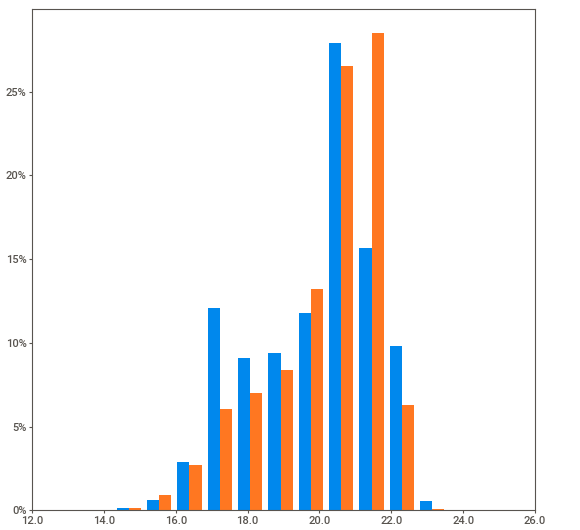
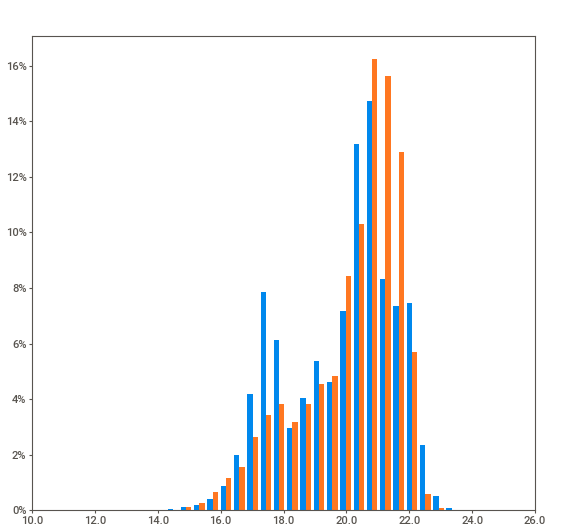
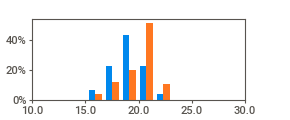
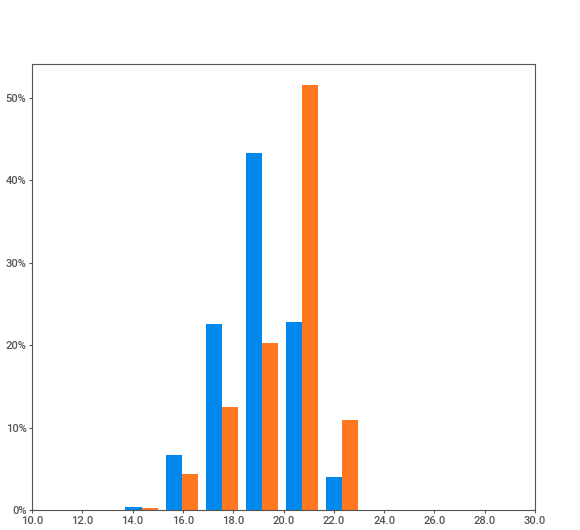
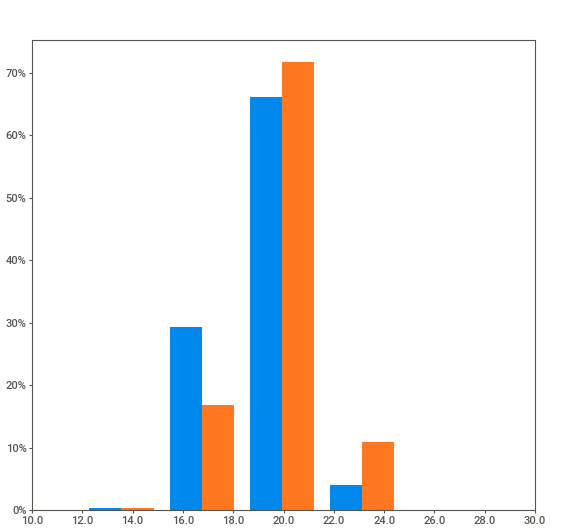
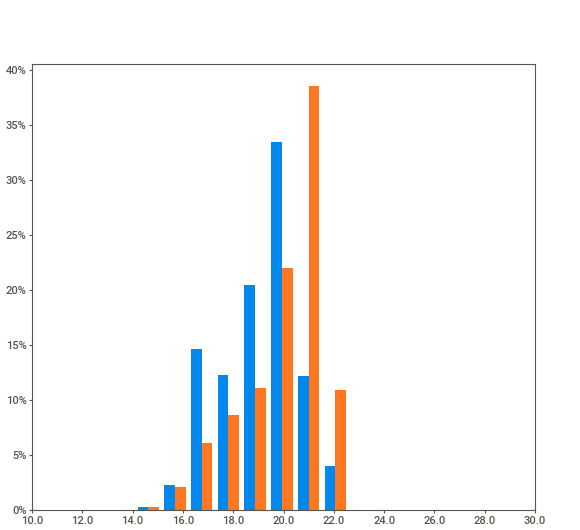
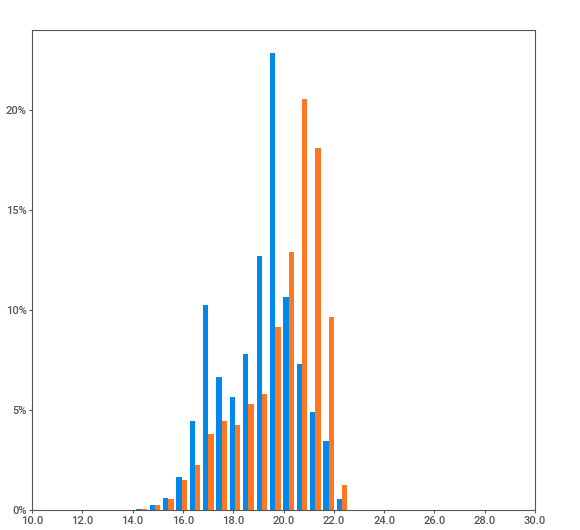
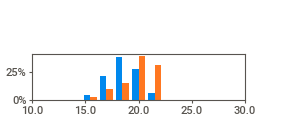
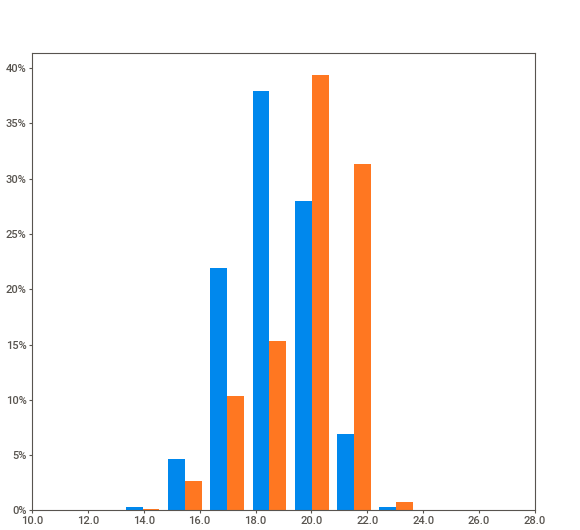
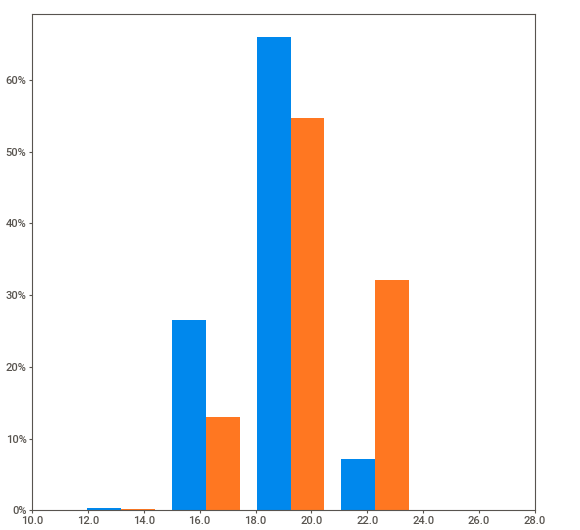
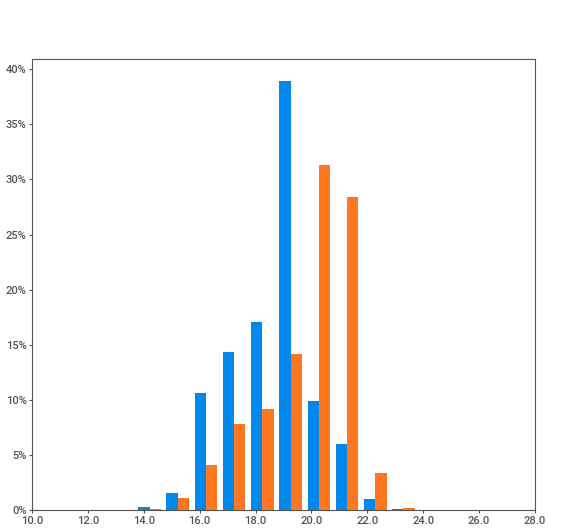
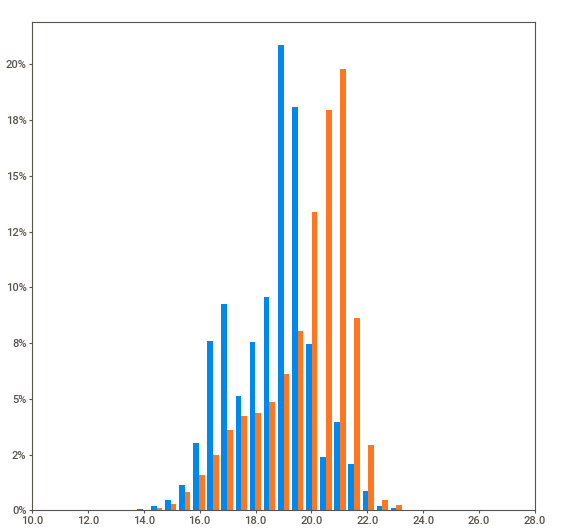
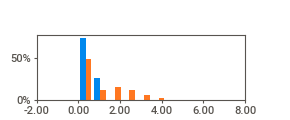
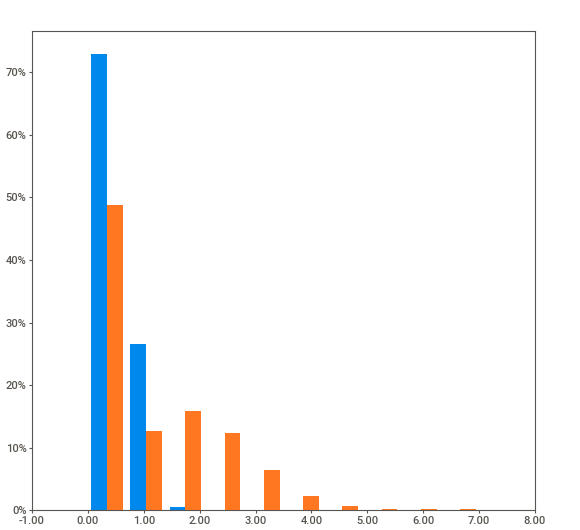
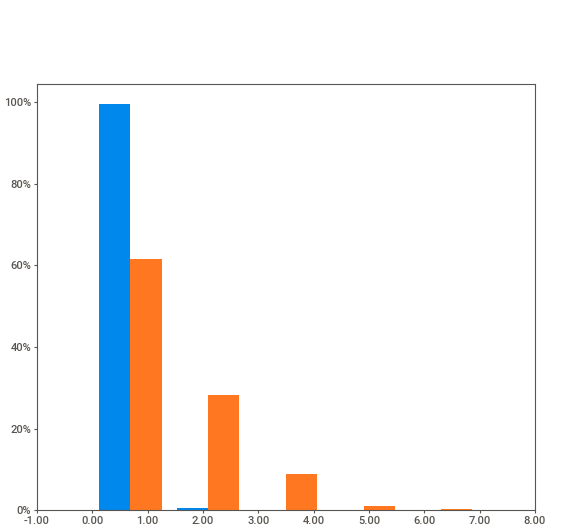
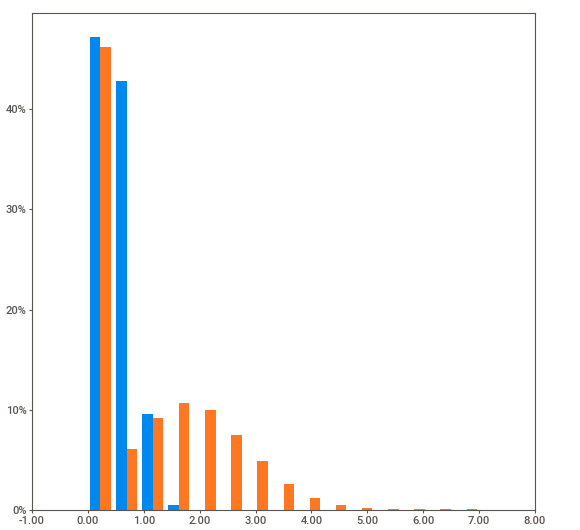
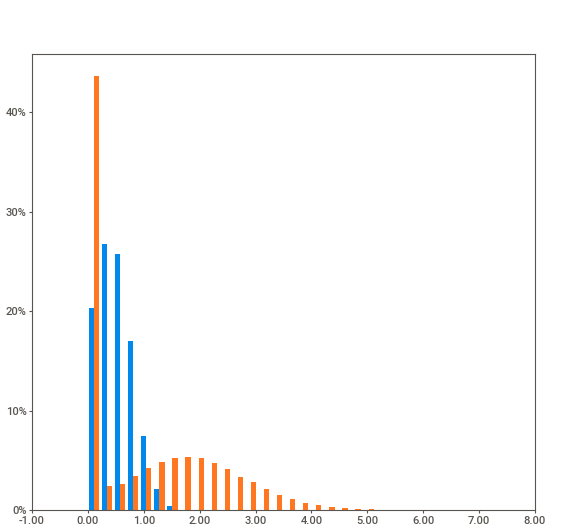
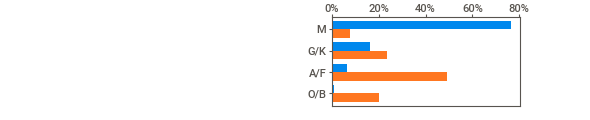
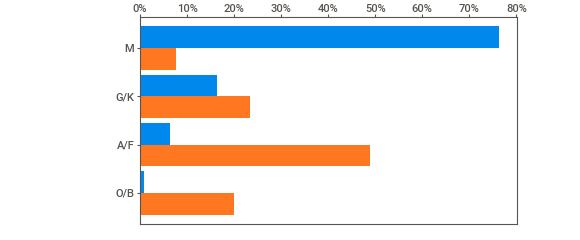
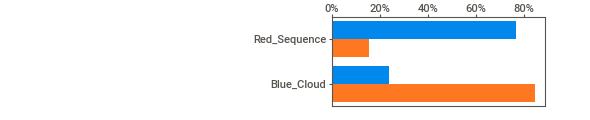
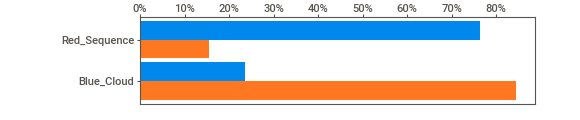
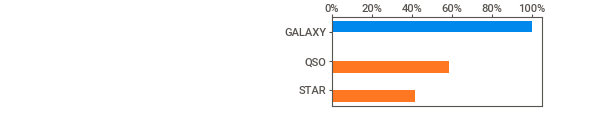
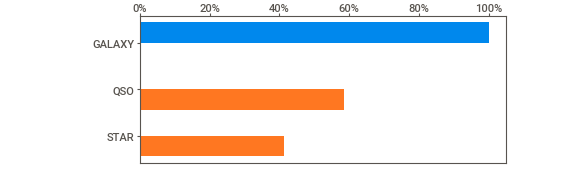
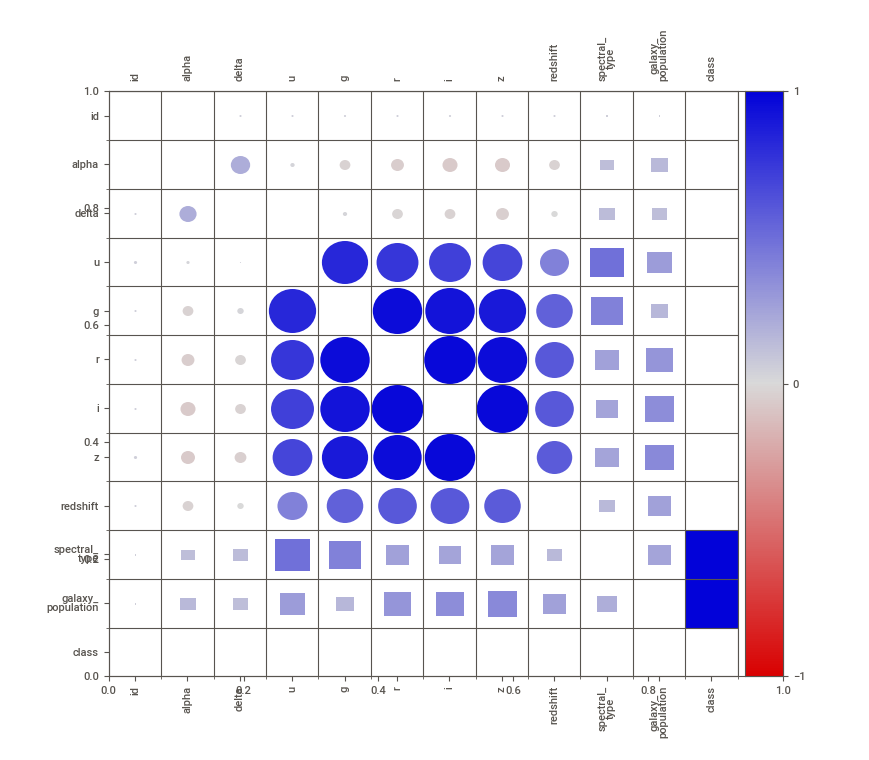
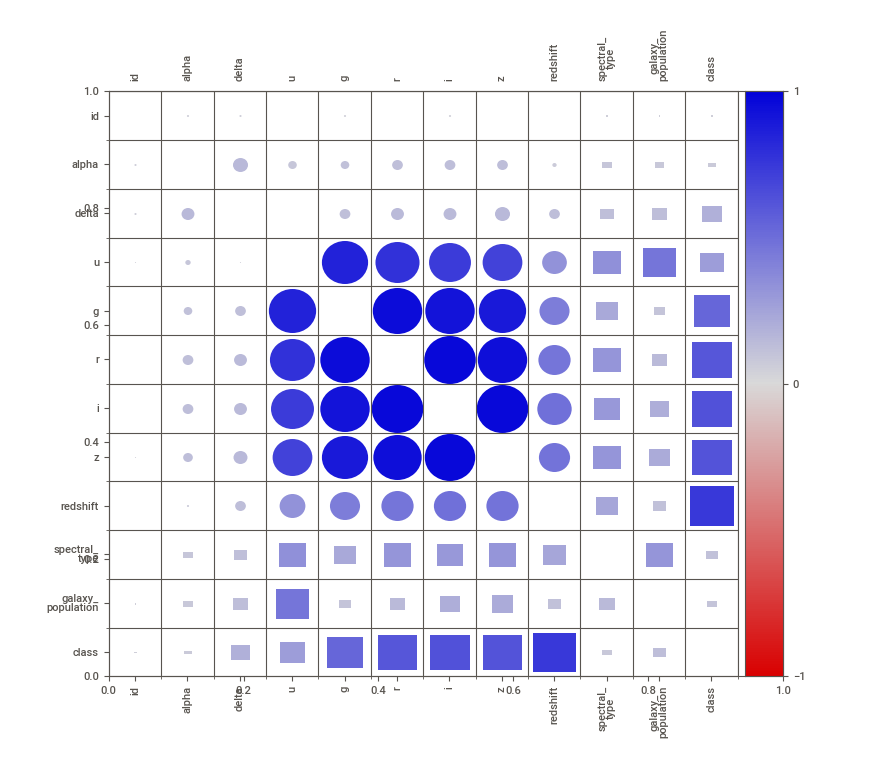

In [10]:
# Compare GALAXY vs QSO subsets within training data
galaxy_vs_qso_report = sv.compare_intra(
    training_df,                          # use original string labels here
    training_df[TARGET] == 'GALAXY',      # boolean mask for "left" split
    ["GALAXY", "QSO / STAR"],
    target_feat=None                       # no target needed for intra-compare
)
galaxy_vs_qso_report.show_notebook(
    w="100%",
    h=700,
    layout='vertical'
)


## Data Visualization
While the automated `sweetviz` reports provide a broad overview, we use a custom `DataVisualizer` class to dig deeper into specific relationships.

1. **Target Encoding:** We convert the `class` target from `QSO`, `STAR`, and `GALAXY` to `0`, `1`, and `2`. This allows us to calculate mean target rates and Spearman correlations numerically.
2. **Signal Ranking:** We rank features by their Spearman correlation (for numerical features) and range of target rate (for categorical features) to identify the strongest predictors.
3. **Interaction Plots:** We generate specific plots to visualize how top features interact with the target across all three classes.

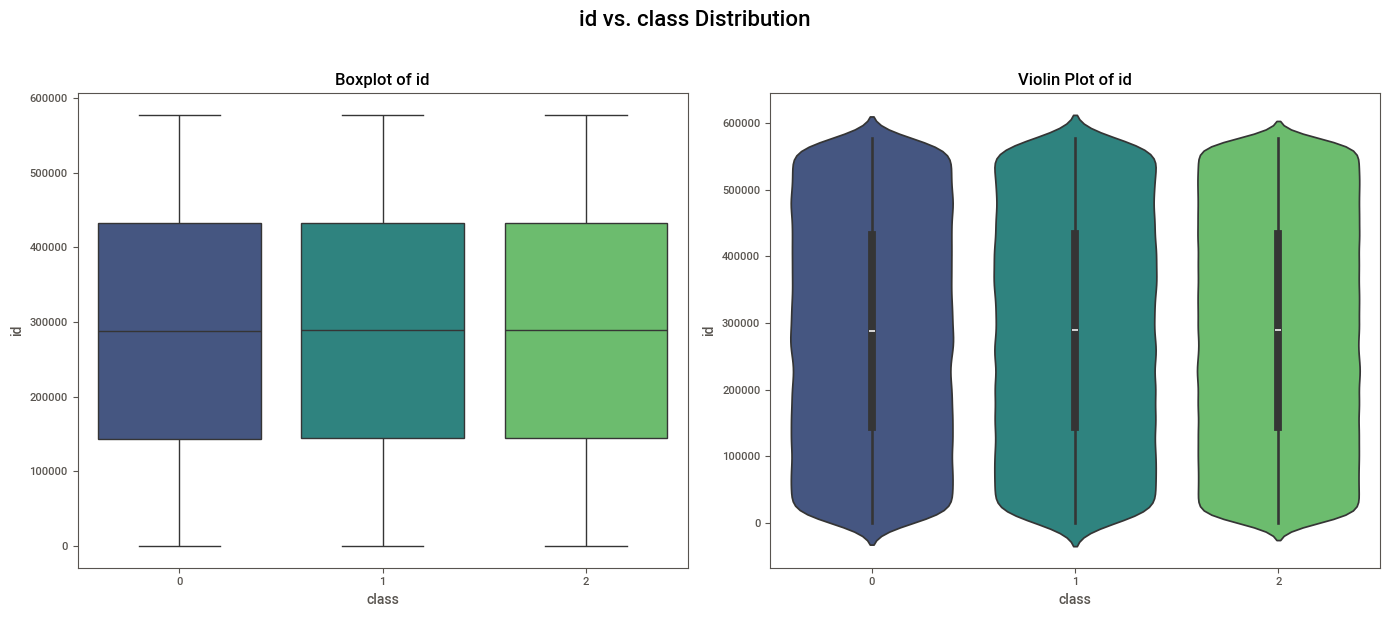

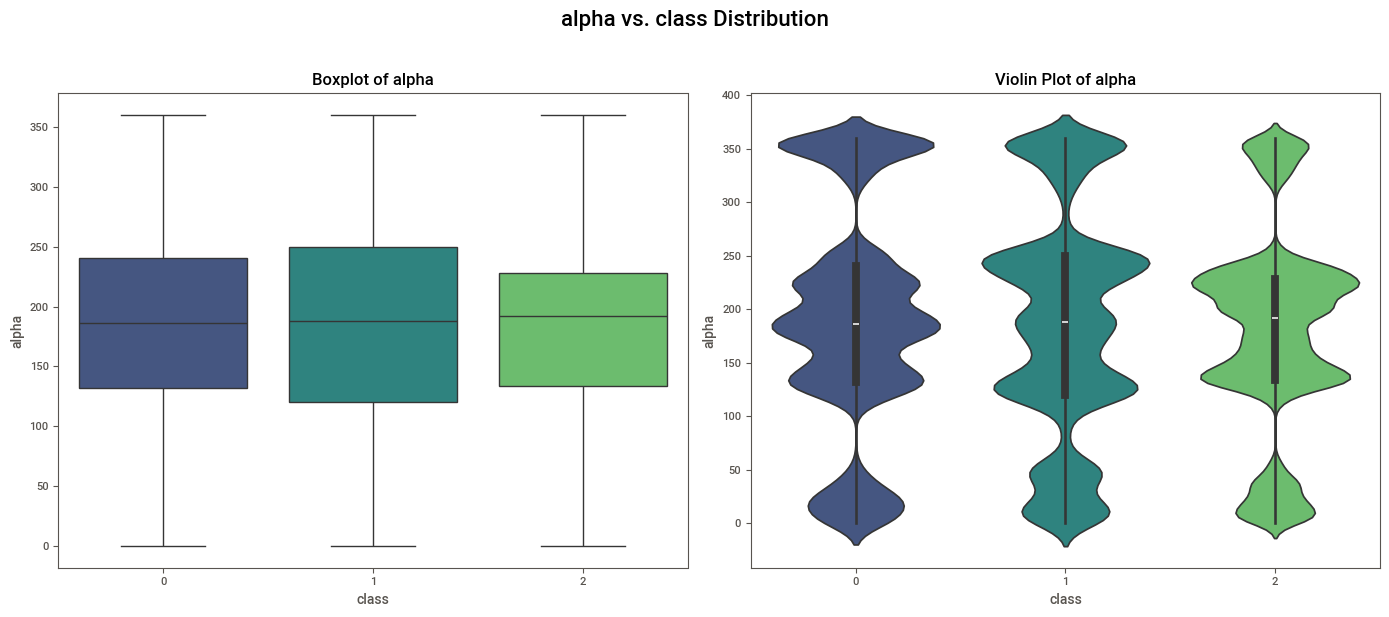

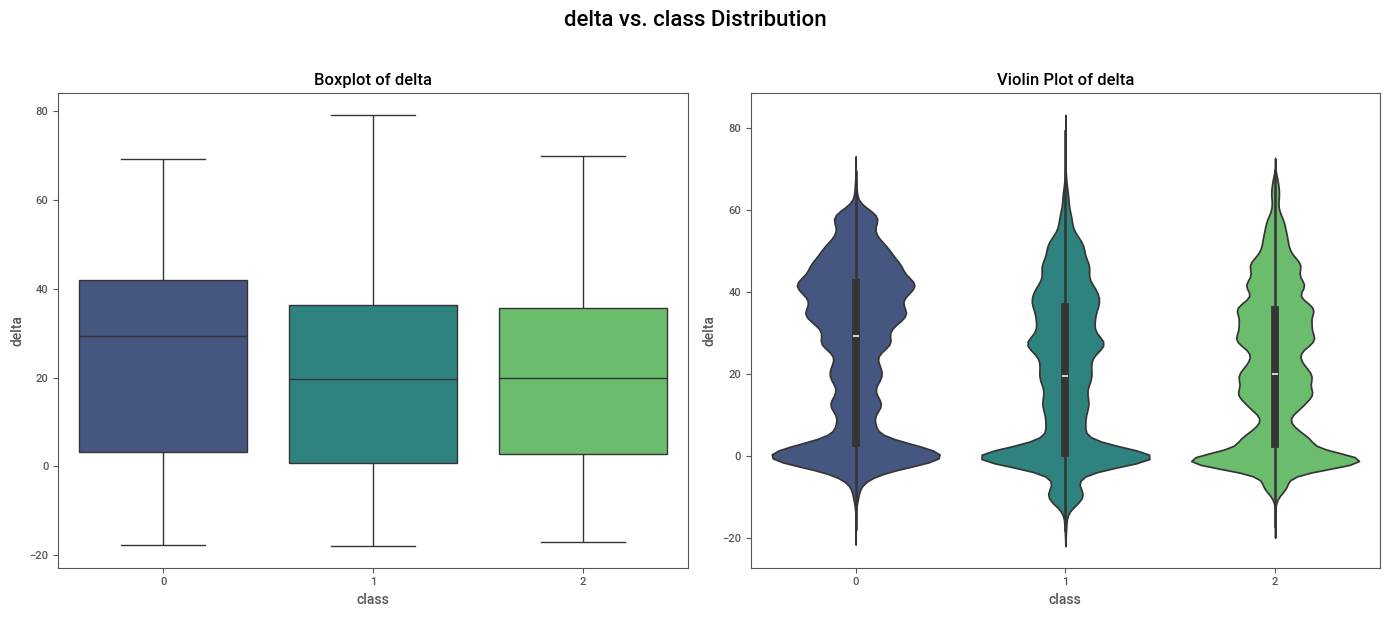

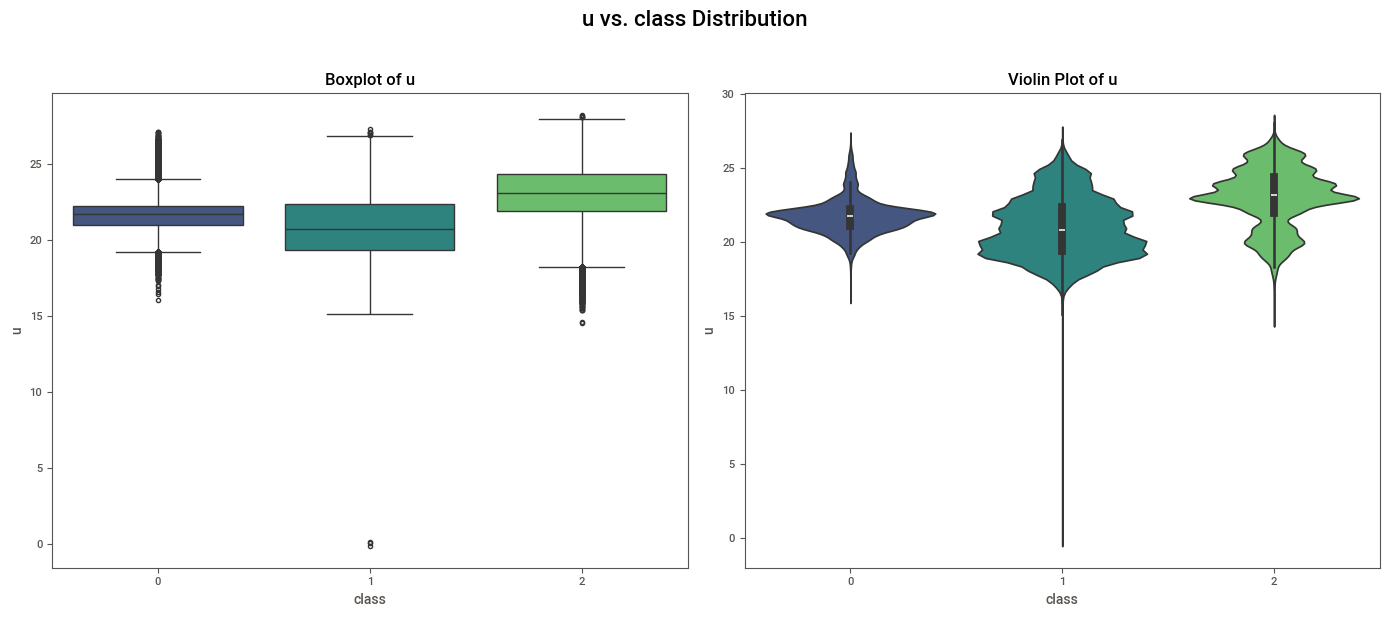

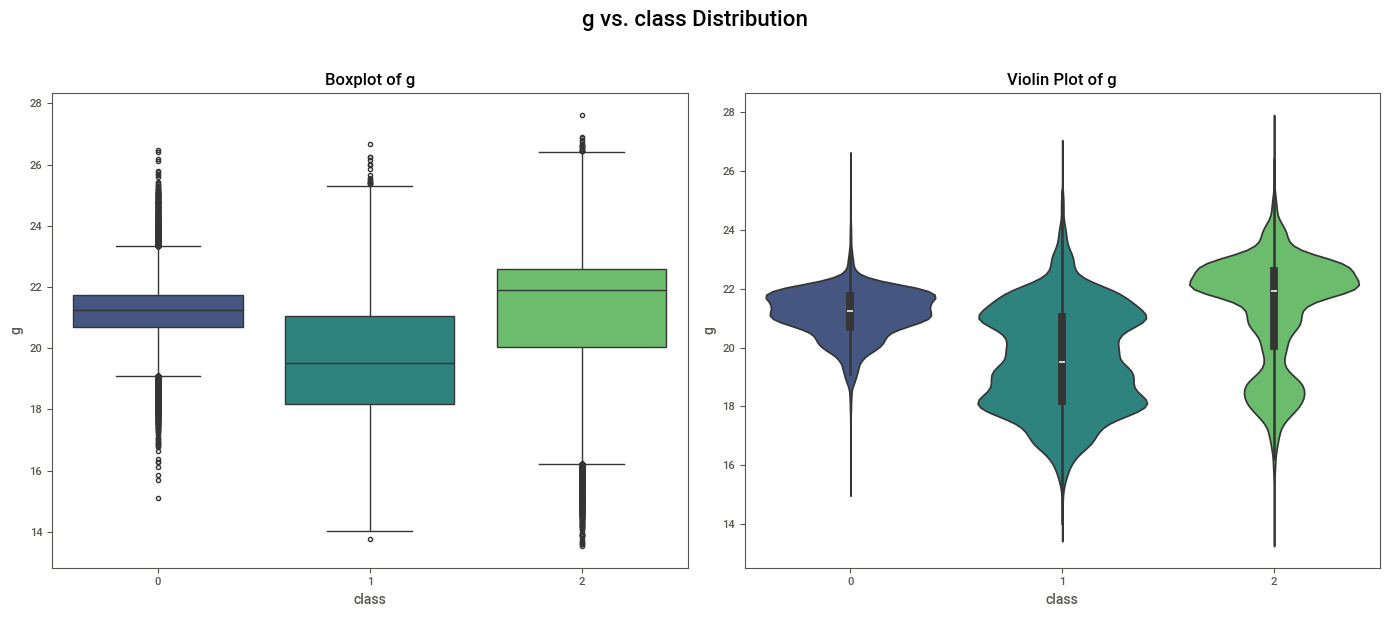

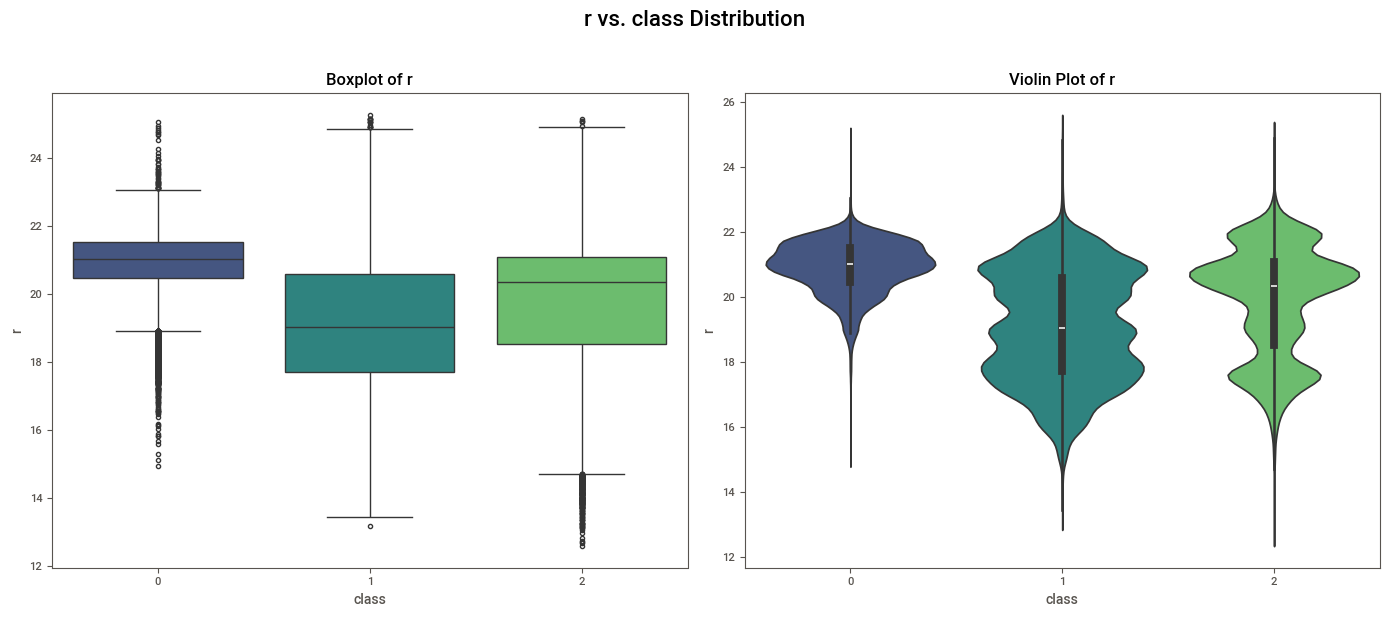

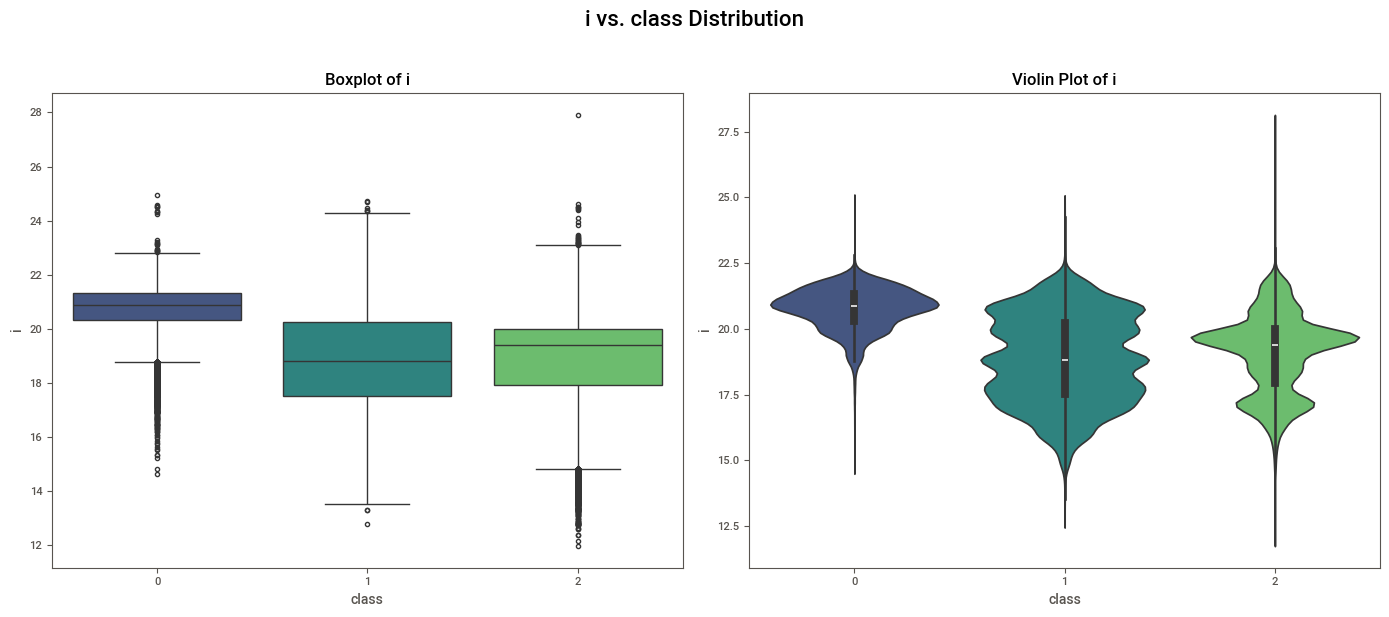

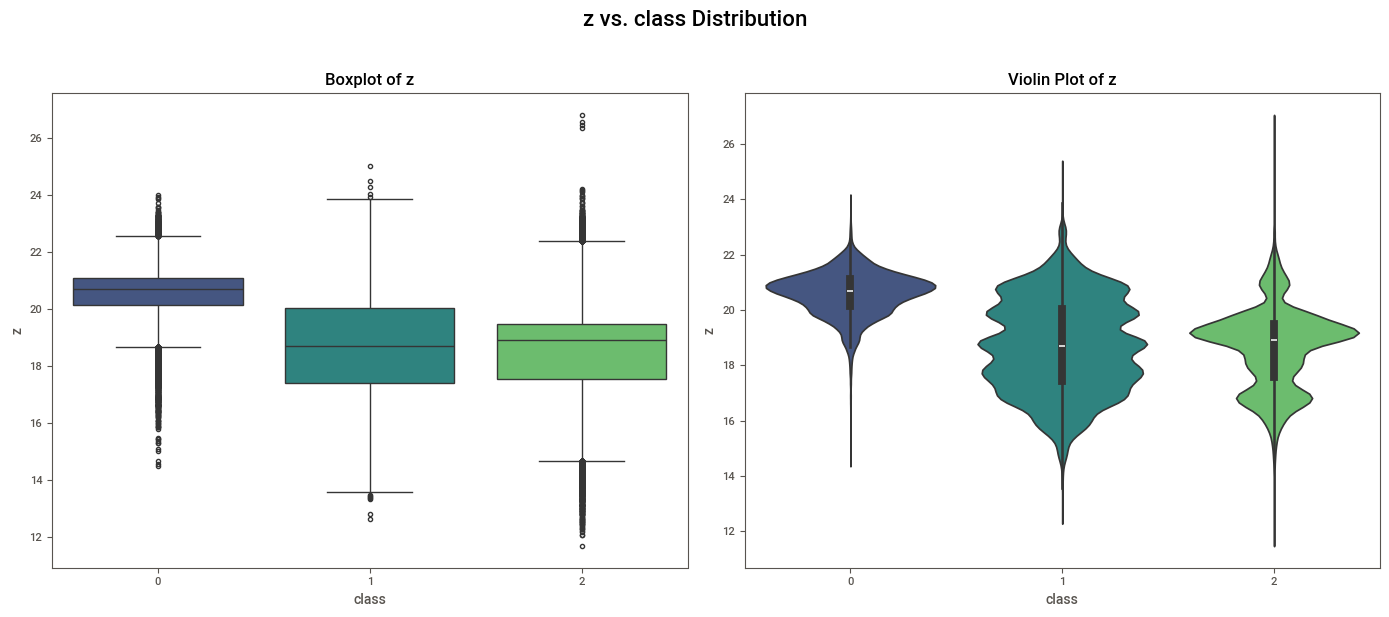

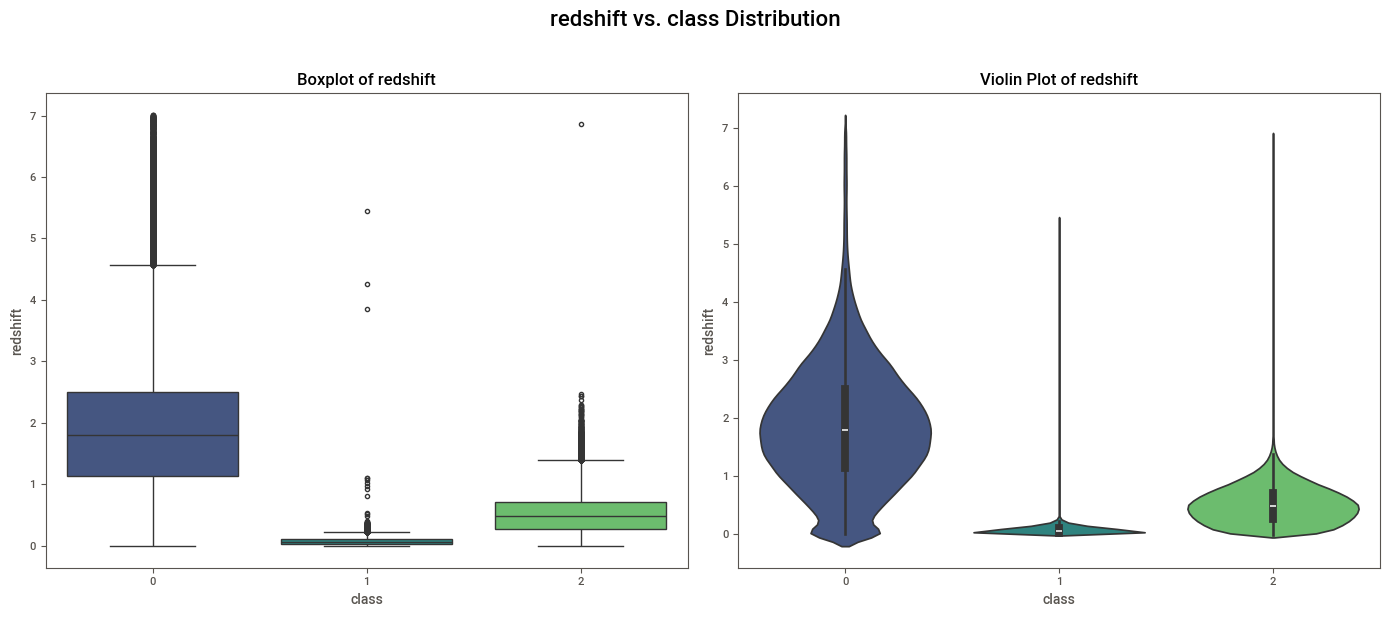

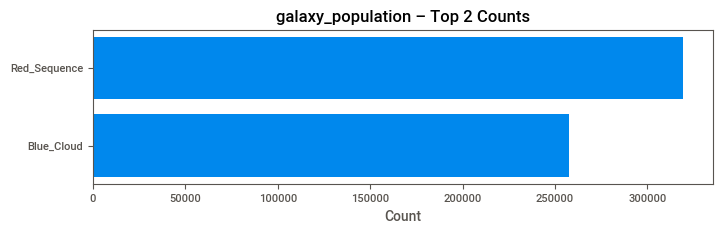

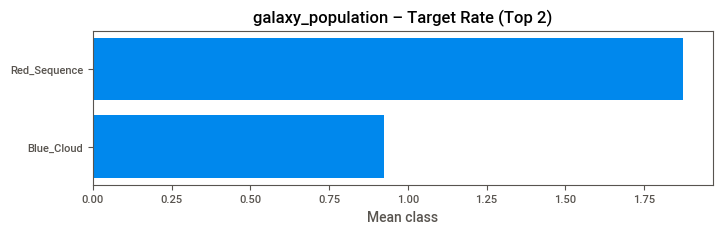

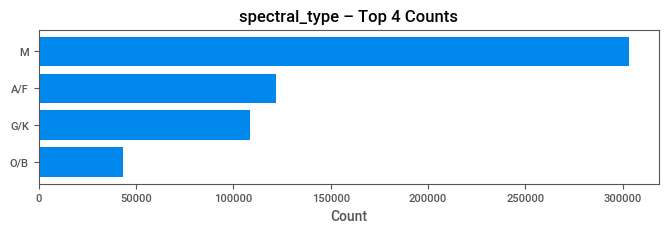

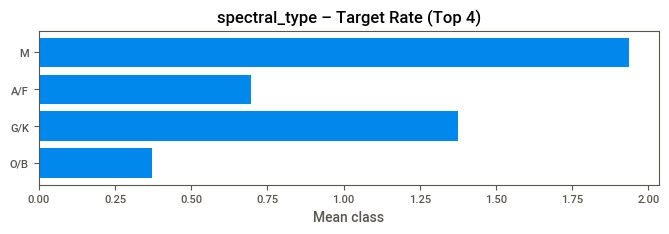

### Numeric x Category Trend

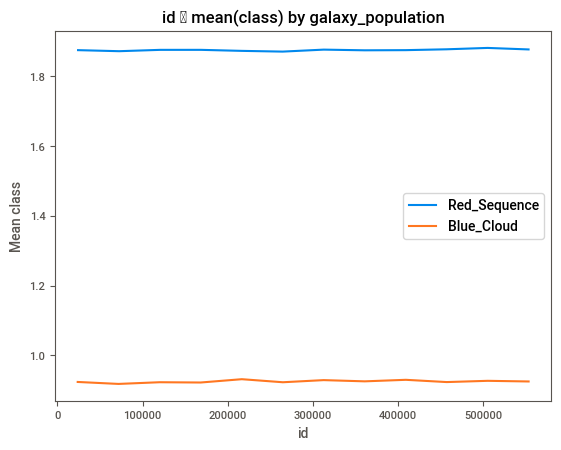

### Category x Category Trend

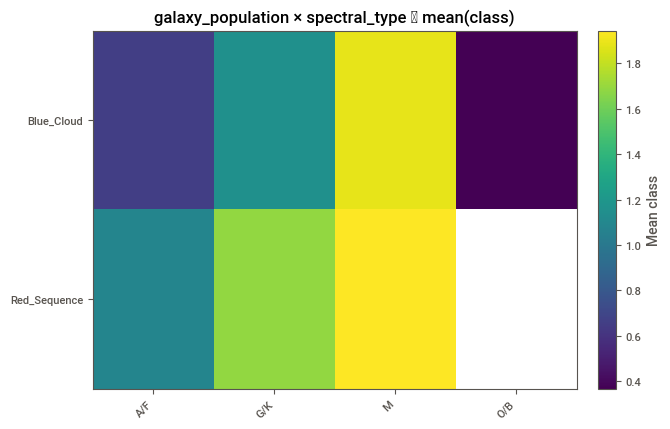

### Feature Signal Ranking

Top numeric (|Spearman|): [('z', -0.45479145728773807), ('i', -0.37711967912932887), ('u', 0.37618066661122507), ('g', 0.2386873647456685), ('redshift', -0.23051255267217535), ('r', -0.15348301426814312), ('delta', -0.08154796834816257), ('alpha', -0.032679320805864685), ('id', 0.0018239367128531797)]
Top categorical (range of mean risk): [('spectral_type', 1.5647704342173847, 4), ('galaxy_population', 0.9500087184513589, 2)]


In [11]:
# Define mapping for the target
# QSO -> 0, STAR -> 1, GALAXY -> 2 (not certain if this is appropriate for the task)
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}

# Apply mapping to the target column
training_df[TARGET] = training_df[TARGET].map(target_mapping)

visualizer = DataVisualizer(target=TARGET, seed=helper.get_seed())
visualizer.run_data_visualization(training_df)

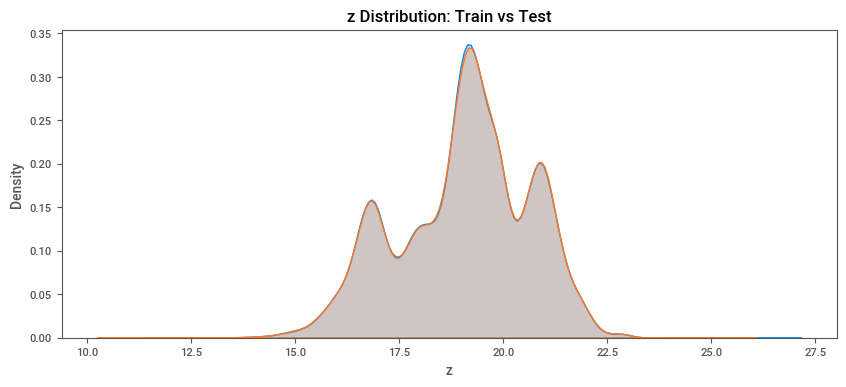

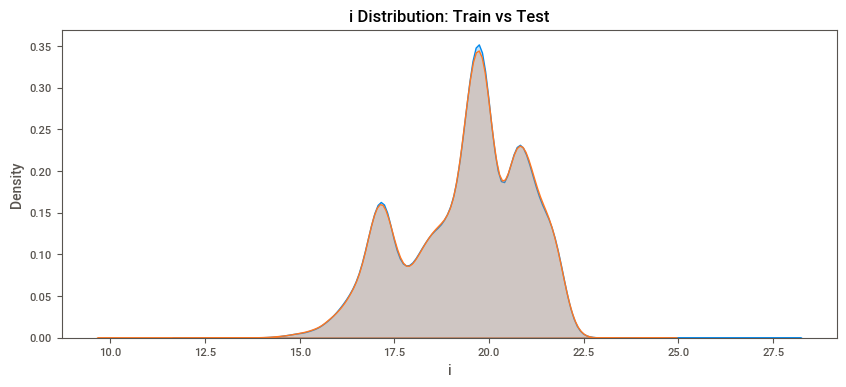

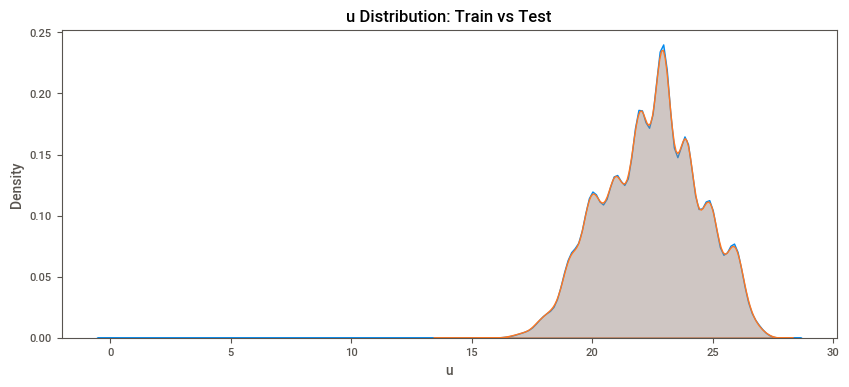

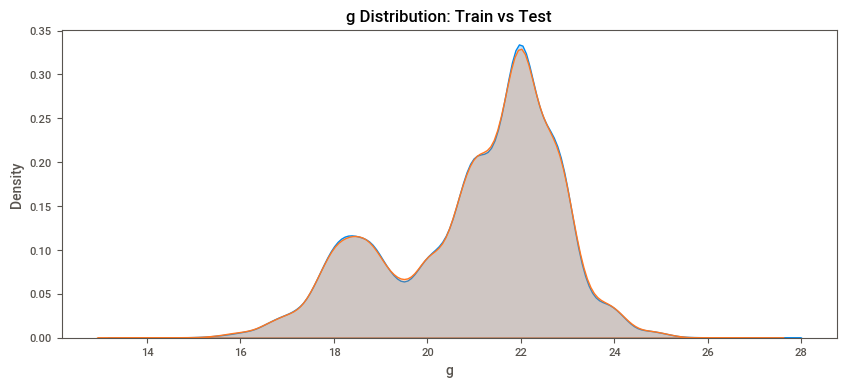

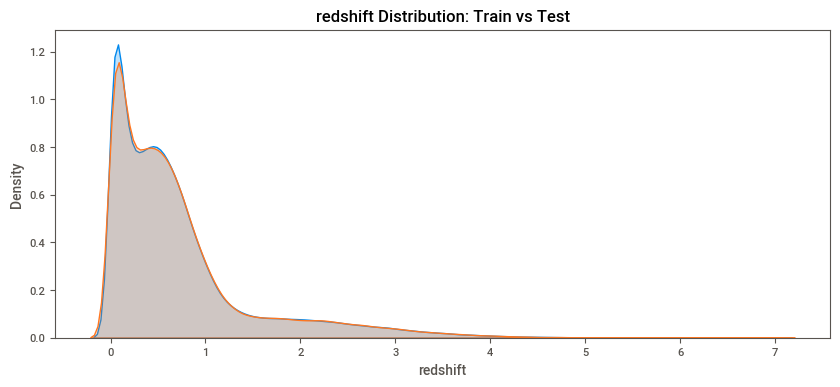

In [12]:
# Check for drift visually in top correlated features
tops=[
    'z',
    'i',
    'u',
    'g',
    'redshift'
]
for top in tops:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(training_df[top], label='Train', fill=True)
    sns.kdeplot(test_df[top], label='Test', fill=True)
    plt.title(f'{top} Distribution: Train vs Test')
    plt.show()

